# Task 2: Deep Learning AE Pipeline - Data Preprocessing

This notebook implements the data preprocessing pipeline for the predictive maintenance task.

**Pipeline Steps:**
1.  **Extract Data:** Load parquet files.
2.  **Time Alignment:** Round timestamps to the nearest second and create a unified 1Hz grid.
3.  **Gap Handling & Forward Fill:** Forward fill data with a limit of 5 minutes (300 seconds). Gaps larger than 5 minutes remain as NaN.
4.  **EMA:** Apply Exponential Moving Average (alpha=0.1) to analog signals.
5.  **Transition Flagging:** Identify and store transitions (value changes) for `ball_valve_open` and `ball_valve_closed`.
6.  **Output:** Store processed time-series and transition logs as pickle files in `data_transitions`.

**Note:** This notebook assumes the raw parquet files are located in `../axpo_challenge/data/`.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import pickle

# Configuration
DATA_DIR = '/Users/benji/Desktop/GEORG/data'
OUTPUT_DIR = '/Users/benji/Desktop/GEORG/data_transitions'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Preprocessing Parameters
EMA_ALPHA = 0.5
GAP_THRESHOLD_SECONDS = 300  # 5 minutes limit for forward fill

print(f"Data Directory: {DATA_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")

Data Directory: /Users/benji/Desktop/GEORG/data
Output Directory: /Users/benji/Desktop/GEORG/data_transitions


In [2]:
# ----------------------------------------------------------------------
# SIGNAL MAPPING
# ----------------------------------------------------------------------
mapping = {
    'signal_id': [8890,9620,9619,11247,11333,11331,16769,15454,15453,16679,14156,14154,
                  26499,30654,30653,29296,29388,29386,16796,24141,24140,25120,25207,25205,
                  18263,19318,19317,21058,21145,21143],
    'measurement_unit': ['MW','', '', '%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar'],
    'type_id': ['measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)'],
    'plant': ['KSL']*30,
    'stage': ['Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg'],
    'machine_group': ['MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG3','MG3','MG3','MG3','MG3','MG3'],
    'signal_name': ['active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream'],
    'description': [
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
    ]
}

df_mapping = pd.DataFrame(mapping)
df_mapping.head()

,signal_id,measurement_unit,type_id,plant,stage,machine_group,signal_name,description
0,8890,MW,measurement (analog),KSL,Mapragg,MG1,active_power,Active power measurement
1,9620,,Bool,KSL,Mapragg,MG1,ball_valve_closed,Ball valve position rotating body closed (true...
2,9619,,Bool,KSL,Mapragg,MG1,ball_valve_open,Ball valve position rotating body open (true i...
3,11247,%,measurement (analog),KSL,Mapragg,MG1,guide_vane_position,Guide vane position measurement
4,11333,bar,measurement (analog),KSL,Mapragg,MG1,water_pressure_downstream,water pressure downstream of the turbine


In [3]:
import os
import pandas as pd
import numpy as np

def process_parquet(file_path, df_map, output_dir, GAP_THRESHOLD_SECONDS=300, EMA_ALPHA=0.1):
    """
    Process a single parquet file with Robust NaN Handling:
    1. Load and map signals.
    2. Resample to 1s grid (time alignment).
    3. Forward fill small gaps (max 5 mins), leaving larger gaps as NaN.
    4. EMA smoothing for analog signals.
    5. Extract transitions for valves.
    6. Save processed data and transitions.
    """
    filename = os.path.basename(file_path)
    base_name = filename.replace('.parquet', '')
    print(f"Processing {filename}...")
    
    # 1. Load Parquet
    try:
        df = pd.read_parquet(file_path)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return

    # Ensure ts is datetime and timezone naive
    if not pd.api.types.is_datetime64_any_dtype(df['ts']):
        df['ts'] = pd.to_datetime(df['ts'])
    if df['ts'].dt.tz is not None:
        df['ts'] = df['ts'].dt.tz_convert(None)
        
    # Merge with mapping to get signal names and types
    df = df.merge(df_map[['signal_id', 'signal_name', 'type_id']], on='signal_id', how='inner')
    
    # 2. Time Alignment
    # FIX: Use .dt.round('1s') to explicitly round to nearest second and remove microseconds
    df['ts_rounded'] = df['ts'].dt.round('1s')

    # Ensure values are numeric
    df['value'] = pd.to_numeric(df['value'], errors='coerce')

    # Pivot to create unified grid for this asset (handles duplicates by averaging)
    pivot_df = df.pivot_table(index='ts_rounded', columns='signal_name', values='value', aggfunc='mean')
    
    # Create full 1s grid from min to max time to ensure continuous time axis
    full_idx = pd.date_range(start=pivot_df.index.min(), end=pivot_df.index.max(), freq='1s')
    
    # Reindex: This creates NaNs where timestamps are missing in the original data
    pivot_df = pivot_df.reindex(full_idx)
    pivot_df.index.name = 'ts'
    
    # 3. Robust NaN Handling: Forward Fill with Limit
    # We do NOT interpolate. We ffill up to 5 minutes.
    # Gaps larger than 5 minutes will remain NaN (to be dropped or handled by downstream windowing logic).
    pivot_df_filled = pivot_df.ffill(limit=GAP_THRESHOLD_SECONDS)
    
    # 4. Apply EMA to Analog Signals
    # Note: EMA handles NaNs gracefully (ignores them), but works best on the filled data
    analog_signals = df_map[df_map['type_id'] == 'measurement (analog)']['signal_name'].unique()
    
    for col in pivot_df_filled.columns:
        if col in analog_signals:
            pivot_df_filled[col] = pivot_df_filled[col].ewm(alpha=EMA_ALPHA, adjust=False).mean()

    # 5. Transition Flagging (for Boolean Signals)
    # We use the original pivot (or filled, depending on preference) to detect changes.
    # Usually, transitions should be detected on filled data to avoid false transitions around gaps,
    # but here we use the specific logic provided.
    bool_signals = df_map[df_map['type_id'] == 'Bool']['signal_name'].unique()
    transitions_list = []
    
    for col in bool_signals:
        # Check if column exists in data
        if col in pivot_df_filled.columns:
            s_raw = pivot_df_filled[col].dropna()
            
            if s_raw.empty:
                continue
            
            # Detect changes: value != prev_value
            prev = s_raw.shift(1)
            mask = (s_raw != prev) & prev.notna()
            
            num_trans = mask.sum()
            if num_trans > 0:
                trans_times = s_raw.index[mask]
                trans_values = s_raw[mask]
                prev_values = prev[mask]
                
                tdf = pd.DataFrame({
                    'timestamp': trans_times,
                    'signal': col,
                    'from_value': prev_values,
                    'to_value': trans_values
                })
                transitions_list.append(tdf)

    # 6. Save Outputs
    processed_path = os.path.join(output_dir, f"{base_name}_processed.pkl")
    pivot_df_filled.to_pickle(processed_path)
    print(f"  Saved processed data to {processed_path}")
    
    if transitions_list:
        all_transitions = pd.concat(transitions_list).sort_values('timestamp')
        trans_path = os.path.join(output_dir, f"{base_name}_transitions.pkl")
        all_transitions.to_pickle(trans_path)
        print(f"  Saved {len(all_transitions)} transitions to {trans_path}")
    else:
        print("  No transitions found.")

In [4]:
# ----------------------------------------------------------------------
# EXECUTE PIPELINE
# ----------------------------------------------------------------------
parquet_files = glob.glob(os.path.join(DATA_DIR, '*.parquet'))
print(f"Found {len(parquet_files)} parquet files.")

for path in parquet_files:
    process_parquet(path, df_mapping, OUTPUT_DIR)

print("\nPipeline execution complete.")

Found 10 parquet files.
Processing Mapragg_MG2_training_real_measurements.parquet...
  Saved processed data to /Users/benji/Desktop/GEORG/data_transitions/Mapragg_MG2_training_real_measurements_processed.pkl
  Saved 3060 transitions to /Users/benji/Desktop/GEORG/data_transitions/Mapragg_MG2_training_real_measurements_transitions.pkl
Processing Sarelli_MG1_testing_real_measurements.parquet...
  Saved processed data to /Users/benji/Desktop/GEORG/data_transitions/Sarelli_MG1_testing_real_measurements_processed.pkl
  Saved 282 transitions to /Users/benji/Desktop/GEORG/data_transitions/Sarelli_MG1_testing_real_measurements_transitions.pkl
Processing Mapragg_MG2_testing_real_measurements.parquet...
  Saved processed data to /Users/benji/Desktop/GEORG/data_transitions/Mapragg_MG2_testing_real_measurements_processed.pkl
  Saved 410 transitions to /Users/benji/Desktop/GEORG/data_transitions/Mapragg_MG2_testing_real_measurements_transitions.pkl
Processing Mapragg_MG1_testing_real_measurements.pa

In [5]:
# ----------------------------------------------------------------------
# INTERACTIVE TRANSITION INSPECTION
# ----------------------------------------------------------------------
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# Ensure output directory for transitions is known
TRANSITIONS_DIR = 'data_transitions'

def get_transition_count(dataset_name):
    """Helper to get number of transitions for a dataset."""
    try:
        t_path = os.path.join(TRANSITIONS_DIR, f"{dataset_name}_transitions.pkl")
        if os.path.exists(t_path):
            df = pd.read_pickle(t_path)
            return len(df)
        return 0
    except:
        return 0

def plot_transition_inspector(dataset_name, transition_idx):
    """
    Plots 6 signals centered around a specific transition event.
    Overlays raw data points on top of the processed 1Hz line.
    """
    if not dataset_name:
        return
        
    # Paths
    proc_path = os.path.join(TRANSITIONS_DIR, f"{dataset_name}_processed.pkl")
    trans_path = os.path.join(TRANSITIONS_DIR, f"{dataset_name}_transitions.pkl")
    # Note: DATA_DIR is defined in the configuration cell above
    raw_path = os.path.join(DATA_DIR, f"{dataset_name}.parquet")
    
    # Load Transitions
    if not os.path.exists(trans_path):
        print("Transitions file not found.")
        return
    transitions = pd.read_pickle(trans_path)
    
    if transitions.empty:
        print("No transitions in this dataset.")
        return
        
    if transition_idx >= len(transitions):
        print(f"Transition index {transition_idx} out of range.")
        return

    # Get Event Info
    event = transitions.iloc[transition_idx]
    event_ts = event['timestamp']
    event_sig = event['signal']
    print(f"Dataset: {dataset_name}")
    print(f"Transition {transition_idx + 1}/{len(transitions)}")
    print(f"Signal: {event_sig} | Time: {event_ts}")
    print(f"Change: {event['from_value']} -> {event['to_value']}")
    
    # Define Time Window (+/- 150s)
    start_time = event_ts - pd.Timedelta(seconds=150)
    end_time = event_ts + pd.Timedelta(seconds=150)
    
    # Load Processed Data (Full load is fast for pkl)
    if not os.path.exists(proc_path):
        print("Processed file not found.")
        return
    df_proc = pd.read_pickle(proc_path)
    
    # Slice Processed
    mask_proc = (df_proc.index >= start_time) & (df_proc.index <= end_time)
    df_slice = df_proc[mask_proc]
    
    # Load Raw Data
    df_raw_slice = pd.DataFrame()
    if os.path.exists(raw_path):
        try:
            df_raw = pd.read_parquet(raw_path)
            
            # Ensure TS format
            if not pd.api.types.is_datetime64_any_dtype(df_raw['ts']):
                df_raw['ts'] = pd.to_datetime(df_raw['ts'])
            if df_raw['ts'].dt.tz is not None:
                df_raw['ts'] = df_raw['ts'].dt.tz_convert(None)
                
            # Filter Time Window
            mask_raw = (df_raw['ts'] >= start_time) & (df_raw['ts'] <= end_time)
            df_raw_slice = df_raw[mask_raw].copy()
            
            # Merge with mapping to get names
            if not df_raw_slice.empty:
                df_raw_slice = df_raw_slice.merge(df_mapping[['signal_id', 'signal_name']], on='signal_id', how='left')
        except Exception as e:
            print(f"Error loading raw data: {e}")
    else:
        print(f"Raw file not found: {raw_path}")
            
    # Plotting
    signals = [
        'active_power', 'ball_valve_closed', 'ball_valve_open',
        'guide_vane_position', 'water_pressure_downstream', 'water_pressure_upstream'
    ]
    
    fig, axes = plt.subplots(len(signals), 1, figsize=(14, 2.5 * len(signals)), sharex=True)
    
    for ax, sig in zip(axes, signals):
        # 1. Plot Processed (Line)
        if sig in df_slice.columns:
            ax.plot(df_slice.index, df_slice[sig], label='Processed (1Hz)', color='tab:blue', linewidth=2, alpha=0.6)
            
        # 2. Plot Raw (Scatter)
        if not df_raw_slice.empty:
            raw_sig = df_raw_slice[df_raw_slice['signal_name'] == sig]
            if not raw_sig.empty:
                ax.scatter(raw_sig['ts'], raw_sig['value'], label='Raw', color='tab:red', s=20, alpha=0.8, marker='x', zorder=5)
        
        # 3. Transition Marker
        ax.axvline(event_ts, color='k', linestyle='--', alpha=0.7, label='Transition Event')
        
        ax.set_ylabel(sig, fontsize=10)
        ax.grid(True, alpha=0.3)
        if sig == signals[0]:
            ax.legend(loc='upper right', fontsize='small')
            
    plt.xlabel('Timestamp')
    plt.tight_layout()
    plt.show()

# --- Widget Setup ---
# Get list of processed datasets
processed_files = sorted([f.replace('_processed.pkl', '') for f in os.listdir(TRANSITIONS_DIR) if f.endswith('_processed.pkl')])

# Create Widgets
ds_dropdown = widgets.Dropdown(options=processed_files, description='Dataset:')
idx_slider = widgets.IntSlider(min=0, max=0, step=1, description='Transition #:', continuous_update=False)

def update_slider_range(*args):
    dataset = ds_dropdown.value
    count = get_transition_count(dataset)
    idx_slider.max = max(0, count - 1)
    idx_slider.value = 0

ds_dropdown.observe(update_slider_range, 'value')

# Initialize slider
update_slider_range()

# Interact
widgets.interact(plot_transition_inspector, dataset_name=ds_dropdown, transition_idx=idx_slider);

interactive(children=(Dropdown(description='Dataset:', options=('Mapragg_MG1_testing_real_measurements', 'Mapr…

In [24]:
# ----------------------------------------------------------------------
# DÉTECTION DES ANOMALIES DE TRANSITIONS
# 1. Transitions doubles (open/close en même temps)
# 2. Transitions open/close rapides (< 180 secondes)
# ----------------------------------------------------------------------
import pandas as pd
import numpy as np
import os

TRANSITIONS_DIR = 'data_transitions'

def detect_transition_anomalies(dataset_name):
    """
    Détecte deux types d'anomalies dans les transitions :
    1. Transitions doubles : ball_valve_open et ball_valve_closed changent au même timestamp
    2. Transitions rapides : open/close à moins de 180 secondes d'intervalle
    """
    trans_path = os.path.join(TRANSITIONS_DIR, f"{dataset_name}_transitions.pkl")
    
    if not os.path.exists(trans_path):
        print(f"Fichier de transitions non trouvé : {trans_path}")
        return None
    
    df_trans = pd.read_pickle(trans_path)
    
    if df_trans.empty:
        print(f"Aucune transition trouvée pour {dataset_name}")
        return None
    
    df_trans = df_trans.sort_values('timestamp').reset_index(drop=True)
    
    # Initialiser les colonnes d'anomalies
    df_trans['is_double_transition'] = False
    df_trans['is_rapid_transition'] = False
    df_trans['anomaly_reason'] = ''
    
    # 1. DÉTECTION DES TRANSITIONS DOUBLES
    # Vérifier si open et closed changent au même timestamp (ou très proche, < 1 seconde)
    for i in range(len(df_trans)):
        current = df_trans.iloc[i]
        current_ts = current['timestamp']
        current_sig = current['signal']
        
        # Chercher les transitions sur l'autre signal au même timestamp
        time_tolerance = pd.Timedelta(seconds=1)
        mask_same_time = (
            (df_trans['timestamp'] >= current_ts - time_tolerance) &
            (df_trans['timestamp'] <= current_ts + time_tolerance) &
            (df_trans['signal'] != current_sig)
        )
        
        if mask_same_time.any():
            # Vérifier si c'est une transition contradictoire
            other_transitions = df_trans[mask_same_time]
            for _, other in other_transitions.iterrows():
                # Si open passe à 1 ET closed passe à 1 en même temps -> anomalie
                # Si open passe à 0 ET closed passe à 0 en même temps -> anomalie
                if (current_sig == 'ball_valve_open' and other['signal'] == 'ball_valve_closed'):
                    if (current['to_value'] == 1 and other['to_value'] == 1) or \
                       (current['to_value'] == 0 and other['to_value'] == 0):
                        df_trans.at[i, 'is_double_transition'] = True
                        df_trans.at[i, 'anomaly_reason'] = 'double_transition'
                        # Marquer aussi l'autre transition
                        other_idx = other.name
                        df_trans.at[other_idx, 'is_double_transition'] = True
                        df_trans.at[other_idx, 'anomaly_reason'] = 'double_transition'
    
    # 2. DÉTECTION DES TRANSITIONS RAPIDES (< 180 secondes)
    # Pour chaque transition, vérifier s'il y a une transition opposée dans les 180 secondes
    for i in range(len(df_trans)):
        current = df_trans.iloc[i]
        current_ts = current['timestamp']
        current_sig = current['signal']
        
        # Chercher les transitions opposées dans les 180 secondes suivantes
        time_window = pd.Timedelta(seconds=180)
        mask_future = (
            (df_trans['timestamp'] > current_ts) &
            (df_trans['timestamp'] <= current_ts + time_window) &
            (df_trans['signal'] != current_sig)
        )
        
        if mask_future.any():
            future_transitions = df_trans[mask_future]
            for _, future in future_transitions.iterrows():
                # Vérifier si c'est une transition opposée logique
                is_opposite = False
                
                if current_sig == 'ball_valve_open' and future['signal'] == 'ball_valve_closed':
                    # open -> 1, puis closed -> 1 (ouverture puis fermeture rapide)
                    if current['to_value'] == 1 and future['to_value'] == 1:
                        is_opposite = True
                    # open -> 0, puis closed -> 0 (fermeture puis ouverture rapide)
                    elif current['to_value'] == 0 and future['to_value'] == 0:
                        is_opposite = True
                        
                elif current_sig == 'ball_valve_closed' and future['signal'] == 'ball_valve_open':
                    # closed -> 1, puis open -> 1 (fermeture puis ouverture rapide)
                    if current['to_value'] == 1 and future['to_value'] == 1:
                        is_opposite = True
                    # closed -> 0, puis open -> 0 (ouverture puis fermeture rapide)
                    elif current['to_value'] == 0 and future['to_value'] == 0:
                        is_opposite = True
                
                if is_opposite:
                    time_diff = (future['timestamp'] - current_ts).total_seconds()
                    df_trans.at[i, 'is_rapid_transition'] = True
                    if df_trans.at[i, 'anomaly_reason']:
                        df_trans.at[i, 'anomaly_reason'] += f', rapid_transition_{time_diff:.0f}s'
                    else:
                        df_trans.at[i, 'anomaly_reason'] = f'rapid_transition_{time_diff:.0f}s'
                    
                    # Marquer aussi la transition future
                    future_idx = future.name
                    df_trans.at[future_idx, 'is_rapid_transition'] = True
                    if df_trans.at[future_idx, 'anomaly_reason']:
                        df_trans.at[future_idx, 'anomaly_reason'] += f', rapid_transition_{time_diff:.0f}s'
                    else:
                        df_trans.at[future_idx, 'anomaly_reason'] = f'rapid_transition_{time_diff:.0f}s'
    
    # Résumé
    n_double = df_trans['is_double_transition'].sum()
    n_rapid = df_trans['is_rapid_transition'].sum()
    n_total_anomalies = (df_trans['is_double_transition'] | df_trans['is_rapid_transition']).sum()
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"Total transitions: {len(df_trans)}")
    print(f"Transitions doubles (open/close simultanés): {n_double}")
    print(f"Transitions rapides (< 180s): {n_rapid}")
    print(f"Total anomalies détectées: {n_total_anomalies}")
    print(f"{'='*60}\n")
    
    return df_trans

def analyze_all_datasets(split='all'):
    """
    Analyse tous les datasets et génère un rapport global.
    
    Parameters:
    -----------
    split : str, default='all'
        Choix du type de données à analyser:
        - 'training' : uniquement les données d'entraînement
        - 'testing' : uniquement les données de test
        - 'all' : toutes les données
    """
    files = [f.replace('_transitions.pkl', '') for f in os.listdir(TRANSITIONS_DIR) 
             if f.endswith('_transitions.pkl')]
    
    # Filtrer selon le split choisi
    if split == 'training':
        files = [f for f in files if 'training' in f]
        print(f"Analyse des données d'ENTRAÎNEMENT uniquement...")
    elif split == 'testing':
        files = [f for f in files if 'testing' in f]
        print(f"Analyse des données de TEST uniquement...")
    else:
        print(f"Analyse de TOUTES les données...")
    
    if not files:
        print(f"Aucun fichier trouvé pour le split '{split}'")
        return None
    
    all_anomalies = []
    
    for dataset_name in files:
        df_anomalies = detect_transition_anomalies(dataset_name)
        if df_anomalies is not None:
            # Sauvegarder les transitions avec flags d'anomalies
            output_path = os.path.join(TRANSITIONS_DIR, f"{dataset_name}_transitions_anomalies.pkl")
            df_anomalies.to_pickle(output_path)
            print(f"  Sauvegardé: {output_path}")
            
            # Compter les anomalies
            n_double = df_anomalies['is_double_transition'].sum()
            n_rapid = df_anomalies['is_rapid_transition'].sum()
            n_total = (df_anomalies['is_double_transition'] | df_anomalies['is_rapid_transition']).sum()
            
            all_anomalies.append({
                'dataset': dataset_name,
                'total_transitions': len(df_anomalies),
                'double_transitions': n_double,
                'rapid_transitions': n_rapid,
                'total_anomalies': n_total
            })
    
    # Résumé global
    if all_anomalies:
        df_summary = pd.DataFrame(all_anomalies)
        
        # Ajouter les colonnes de pourcentages pour chaque ligne
        df_summary['%_double'] = (df_summary['double_transitions'] / df_summary['total_transitions'] * 100).round(2)
        df_summary['%_rapid'] = (df_summary['rapid_transitions'] / df_summary['total_transitions'] * 100).round(2)
        df_summary['%_total'] = (df_summary['total_anomalies'] / df_summary['total_transitions'] * 100).round(2)
        
        # Réorganiser les colonnes pour un affichage plus lisible
        df_summary = df_summary[['dataset', 'total_transitions', 'double_transitions', '%_double', 
                                  'rapid_transitions', '%_rapid', 'total_anomalies', '%_total']]
        
        print("\n" + "="*60)
        print(f"RÉSUMÉ GLOBAL DES ANOMALIES ({split.upper()})")
        print("="*60)
        print(df_summary.to_string(index=False))
        print("\n" + "="*60)
        total_transitions = df_summary['total_transitions'].sum()
        total_double = df_summary['double_transitions'].sum()
        total_rapid = df_summary['rapid_transitions'].sum()
        total_anomalies = df_summary['total_anomalies'].sum()
        
        # Calculer les proportions
        prop_rapid = (total_rapid / total_transitions * 100) if total_transitions > 0 else 0
        prop_double = (total_double / total_transitions * 100) if total_transitions > 0 else 0
        prop_total = (total_anomalies / total_transitions * 100) if total_transitions > 0 else 0
        
        print(f"Total transitions analysées: {total_transitions}")
        print(f"Total anomalies (doubles): {total_double} ({prop_double:.2f}%)")
        print(f"Total anomalies (rapides): {total_rapid} ({prop_rapid:.2f}%)")
        print(f"Total anomalies (toutes): {total_anomalies} ({prop_total:.2f}%)")
        print("="*60)
        
        return df_summary
    
    return None

In [25]:
# ==============================================================================
# CHOIX DU TYPE DE DONNÉES À ANALYSER
# Modifier la variable SPLIT_CHOICE pour choisir:
# - 'training' : données d'entraînement uniquement
# - 'testing' : données de test uniquement  
# - 'all' : toutes les données
# ==============================================================================
SPLIT_CHOICE = 'training'  # Modifier cette variable pour changer le choix

# Exécuter l'analyse
print("Analyse des anomalies de transitions...")
summary = analyze_all_datasets(split=SPLIT_CHOICE)

Analyse des anomalies de transitions...
Analyse des données d'ENTRAÎNEMENT uniquement...

Dataset: Mapragg_MG2_training_real_measurements
Total transitions: 3060
Transitions doubles (open/close simultanés): 0
Transitions rapides (< 180s): 1402
Total anomalies détectées: 1402

  Sauvegardé: data_transitions/Mapragg_MG2_training_real_measurements_transitions_anomalies.pkl

Dataset: Sarelli_MG1_training_real_measurements
Total transitions: 1090
Transitions doubles (open/close simultanés): 0
Transitions rapides (< 180s): 10
Total anomalies détectées: 10

  Sauvegardé: data_transitions/Sarelli_MG1_training_real_measurements_transitions_anomalies.pkl

Dataset: Mapragg_MG3_training_real_measurements
Total transitions: 2108
Transitions doubles (open/close simultanés): 0
Transitions rapides (< 180s): 1064
Total anomalies détectées: 1064

  Sauvegardé: data_transitions/Mapragg_MG3_training_real_measurements_transitions_anomalies.pkl

Dataset: Mapragg_MG1_training_real_measurements
Total transiti

In [ ]:
# ----------------------------------------------------------------------
# DEEP LEARNING CLASSIFIER (ROBUST VERSION)
# ----------------------------------------------------------------------
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Configuration
WINDOW_SECONDS = 360
HALF_WINDOW = 180
BATCH_SIZE = 32
EPOCHS = 10
TEST_SPLIT = 0.2
LEARNING_RATE = 1e-4

# Directories (Ensure these match your variables from previous cells)
# DATA_DIR = ... 
# TRANSITIONS_DIR = ... 

# 1. Dataset Preparation Class (With Debugging & Fixes)
class WindowExtractor:
    def __init__(self, data_dir, half_window=180):
        self.data_dir = data_dir
        self.half_window = half_window
        self.feature_cols = [
            'active_power', 'ball_valve_closed', 'ball_valve_open',
            'guide_vane_position', 'water_pressure_downstream', 'water_pressure_upstream'
        ]
        
    def extract_windows(self, processed_file, transitions_file):
        if not os.path.exists(processed_file) or not os.path.exists(transitions_file):
            return [], []
            
        df = pd.read_pickle(processed_file)
        df_trans = pd.read_pickle(transitions_file)
        
        # --- FIX 1: FILL NANS IMMEDIATELY ---
        # This prevents dropping valid windows just because of one missing tick
        df = df.fillna(method='ffill').fillna(method='bfill')
        
        if df_trans.empty:
            return [], []
            
        # Group transitions within 180s
        df_trans = df_trans.sort_values('timestamp')
        grouped_events = []
        
        if not df_trans.empty:
            current_group = [df_trans.iloc[0]]
            for i in range(1, len(df_trans)):
                curr = df_trans.iloc[i]
                prev = current_group[-1]
                diff = (curr['timestamp'] - prev['timestamp']).total_seconds()
                if diff < 180:
                    current_group.append(curr)
                else:
                    grouped_events.append(current_group)
                    current_group = [curr]
            grouped_events.append(current_group)
            
        X_events = []
        y_events = []
        event_indices = []
        
        # Debug counters for this file
        stats = {'found': 0, 'bounds_err': 0, 'nan_err': 0, 'ok': 0}
        
        for group in grouped_events:
            stats['found'] += 1
            
            # 1. Determine Time Center
            min_ts = group[0]['timestamp']
            max_ts = group[-1]['timestamp']
            center_ts = min_ts + (max_ts - min_ts) / 2
            center_ts = center_ts.round('1s')
            
            # 2. Determine Label
            votes_opening = 0
            votes_closing = 0
            for row in group:
                sig = row['signal']
                v_from = row['from_value']
                v_to = row['to_value']
                if sig == 'ball_valve_open':
                    if v_from == 0 and v_to == 1: votes_opening += 1
                    elif v_from == 1 and v_to == 0: votes_closing += 1
                elif sig == 'ball_valve_closed':
                    if v_from == 0 and v_to == 1: votes_closing += 1
                    elif v_from == 1 and v_to == 0: votes_opening += 1
            
            if votes_opening > votes_closing: label = 1
            elif votes_closing > votes_opening: label = 2
            else: continue

            # 3. Extract Window
            try:
                idx = df.index.searchsorted(center_ts)
                if idx == 0: center_idx = 0
                elif idx == len(df): center_idx = len(df) - 1
                else:
                    ts_prev = df.index[idx-1]
                    ts_curr = df.index[idx]
                    if abs((ts_curr - center_ts).total_seconds()) < abs((ts_prev - center_ts).total_seconds()):
                        center_idx = idx
                    else:
                        center_idx = idx - 1
                
                start_idx = center_idx - self.half_window
                end_idx = center_idx + self.half_window
                
                # Check Bounds
                if start_idx < 0 or end_idx > len(df):
                    stats['bounds_err'] += 1
                    continue
                    
                vals = df.iloc[start_idx:end_idx][self.feature_cols].values
                
                # Check NaNs (Should be clean due to fillna above, but double check)
                if np.isnan(vals).any():
                    stats['nan_err'] += 1
                    continue

                if vals.shape[0] == 2 * self.half_window:
                    X_events.append(vals)
                    y_events.append(label)
                    event_indices.append((df.index[start_idx], df.index[end_idx-1]))
                    stats['ok'] += 1
            except Exception:
                continue
        
        # Uncomment to see debug stats per file
        # if stats['found'] > 0 and stats['ok'] == 0:
        #    print(f"Debug {os.path.basename(processed_file)}: {stats}")

        # Extract Steady State (Non-Transition) Windows
        # We aim for roughly balanced dataset, but ensure at least some steady states
        n_steady_target = len(X_events) // 2 if X_events else 0
        
        X_steady = []
        y_steady = []
        
        attempts = 0
        max_attempts = max(50, n_steady_target * 10)
        
        min_idx = self.half_window
        max_idx = len(df) - self.half_window
        
        if max_idx > min_idx and n_steady_target > 0:
            while len(X_steady) < n_steady_target and attempts < max_attempts:
                attempts += 1
                rand_idx = random.randint(min_idx, max_idx)
                
                r_start_time = df.index[rand_idx - self.half_window]
                r_end_time = df.index[rand_idx + self.half_window]
                
                overlap = False
                for (e_start, e_end) in event_indices:
                    if (r_start_time <= e_end) and (r_end_time >= e_start):
                        overlap = True
                        break
                
                if not overlap:
                    vals = df.iloc[rand_idx - self.half_window : rand_idx + self.half_window][self.feature_cols].values
                    if not np.isnan(vals).any() and vals.shape[0] == 2 * self.half_window:
                        X_steady.append(vals)
                        y_steady.append(0) 
                        
        return X_events + X_steady, y_events + y_steady

# 2. Data Loading
def load_all_data():
    extractor = WindowExtractor(DATA_DIR, half_window=HALF_WINDOW)
    
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []
    
    files = [f for f in os.listdir(TRANSITIONS_DIR) if f.endswith('_processed.pkl')]
    
    print(f"Found {len(files)} processed files.")
    
    for f in tqdm(files, desc="Loading Files"):
        base = f.replace('_processed.pkl', '')
        processed_path = os.path.join(TRANSITIONS_DIR, f)
        transitions_path = os.path.join(TRANSITIONS_DIR, f"{base}_transitions.pkl")
        
        X, y = extractor.extract_windows(processed_path, transitions_path)
        
        if 'training' in base:
            X_train_list.extend(X)
            y_train_list.extend(y)
        elif 'testing' in base:
            X_test_list.extend(X)
            y_test_list.extend(y)
            
    return np.array(X_train_list), np.array(y_train_list), np.array(X_test_list), np.array(y_test_list)

print("Extracting windows...")
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_all_data()

print(f"Training Samples Extracted: {len(X_train_raw)}")
print(f"Testing Samples Extracted: {len(X_test_raw)}")

# 3. Preprocessing (With Safety Check)
if len(X_train_raw) > 5:  # --- CHECK: Ensure we have enough data ---
    
    print("Standardizing Data...")
    scaler = StandardScaler()
    N_train, T, F = X_train_raw.shape
    X_train_flat = X_train_raw.reshape(-1, F)
    scaler.fit(X_train_flat)
    
    X_train_scaled = scaler.transform(X_train_flat).reshape(N_train, F, T)
    X_train_scaled = X_train_scaled.transpose(0, 1, 2) # (N, Channels, Time)
    
    if len(X_test_raw) > 0:
        N_test, _, _ = X_test_raw.shape
        X_test_flat = X_test_raw.reshape(-1, F)
        X_test_trans = scaler.transform(X_test_flat).reshape(N_test, T, F)
        X_test_scaled = X_test_trans.transpose(0, 2, 1)
    else:
        X_test_scaled = np.array([])

    # --- SAFE STRATIFICATION LOGIC ---
    unique_classes, class_counts = np.unique(y_train_raw, return_counts=True)
    print(f"Class distribution: {dict(zip(unique_classes, class_counts))}")
    
    stratify_param = y_train_raw
    if np.min(class_counts) < 2:
        print("Warning: One or more classes have < 2 samples. Disabling stratification.")
        stratify_param = None
        
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_scaled, y_train_raw, test_size=TEST_SPLIT, random_state=42, stratify=stratify_param
    )

    class ValveDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.LongTensor(y)
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i], self.y[i]

    train_loader = DataLoader(ValveDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(ValveDataset(X_val, y_val), batch_size=BATCH_SIZE)
    if len(X_test_scaled) > 0:
        test_loader = DataLoader(ValveDataset(X_test_scaled, y_test_raw), batch_size=BATCH_SIZE)
    else:
        test_loader = None
        
    # 4. Model Definition
    class ValveClassifier(nn.Module):
        def __init__(self, num_features, num_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv1d(num_features, 64, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.MaxPool1d(2),
                nn.Dropout(0.1),
                
                nn.Conv1d(64, 128, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.MaxPool1d(2),
                nn.Dropout(0.1),
                
                nn.Conv1d(128, 256, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.AdaptiveAvgPool1d(1)
            )
            self.classifier = nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(128, num_classes)
            )
            
        def forward(self, x):
            x = self.features(x)
            x = x.flatten(1)
            x = self.classifier(x)
            return x

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Determine number of classes dynamically
    num_classes = len(np.unique(y_train_raw))
    # Ensure at least 3 output neurons (Steady, Open, Close) even if data is missing some
    num_classes = max(3, num_classes) 
    
    model = ValveClassifier(num_features=6, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 5. Training Loop
    print("\nStarting Training...")
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in tqdm(range(EPOCHS), desc="Epochs"):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_b.size(0)
            correct += (predicted == y_b).sum().item()
            
        avg_train_loss = train_loss/len(train_loader) if len(train_loader) > 0 else 0
        avg_train_acc = 100*correct/total if total > 0 else 0
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                outputs = model(X_b)
                loss = criterion(outputs, y_b)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += y_b.size(0)
                val_correct += (predicted == y_b).sum().item()
                
        avg_val_loss = val_loss/len(val_loader) if len(val_loader) > 0 else 0
        avg_val_acc = 100*val_correct/val_total if val_total > 0 else 0
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_acc'].append(avg_val_acc)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2f}%")

    # 6. Evaluation & Plotting
    if test_loader:
        print("\nEvaluating on Test Set...")
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                outputs = model(X_b)
                _, predicted = torch.max(outputs.data, 1)
                test_total += y_b.size(0)
                test_correct += (predicted == y_b).sum().item()
        if test_total > 0:
            print(f"Test Accuracy: {100*test_correct/test_total:.2f}%")
        
    # Plotting
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss Evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy Evolution')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.show()

else:
    print("\n!!! NOT ENOUGH DATA TO TRAIN !!!")
    print(f"Only found {len(X_train_raw)} valid samples.")
    print("Likely causes:")
    print("1. Transitions are too close to start/end of file (Bounds Error).")
    print("2. Data contains NaNs (NaN Error).")
    print("3. Check 'Debug' prints above if enabled.")

Extracting windows...
Found 10 processed files.


Loading Files:   0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/1301717459.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/1301717459.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/1301717459.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/1301717459.py:48: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. 

In [ ]:
# ----------------------------------------------------------------------
# AUTOENCODER + HDBSCAN ANOMALY DETECTION PIPELINE
# VERSION 1: Trains SEPARATE autoencoders for EACH SIGNAL
# ----------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
import hdbscan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import pickle

# Configuration
WINDOW_SECONDS = 360
HALF_WINDOW = 180
BATCH_SIZE = 64
EPOCHS_AE = 50
LEARNING_RATE_AE = 0.001
BOTTLENECK_DIM = 32
CONV_KERNEL_SIZE = 7  # Kernel size for Conv1D layers (larger = smoother, less noise)
TRANSITIONS_DIR = 'data_transitions'

SIGNALS = ['active_power', 'ball_valve_closed', 'ball_valve_open',
           'guide_vane_position', 'water_pressure_downstream', 'water_pressure_upstream']

# ==============================================================================
# 1. 1D CONVOLUTIONAL AUTOENCODER DEFINITION (Per Signal)
# ==============================================================================
class Conv1DAutoencoder(nn.Module):
    """
    1D Convolutional Autoencoder for single signal time series.
    Input: Single signal window (360 timesteps)
    
    Uses kernel_size=7 for smoothness and noise reduction.
    
    Architecture:
    - Encoder: Conv1D layers progressively reduce temporal dimension
      (1, 360) → (16, 180) → (32, 90) → (64, 45) → Flatten → bottleneck_dim
    - Decoder: Linear → Reshape → ConvTranspose1D layers to reconstruct
    """
    def __init__(self, input_dim=360, bottleneck_dim=32, kernel_size=7):
        super(Conv1DAutoencoder, self).__init__()
        
        self.input_dim = input_dim
        self.bottleneck_dim = bottleneck_dim
        self.kernel_size = kernel_size
        padding = kernel_size // 2  # Same padding to preserve dimensions before pooling
        
        # Encoder: Conv1D with stride=2 for downsampling
        # Input: (batch, 1, 360)
        self.encoder_conv = nn.Sequential(
            # Layer 1: (1, 360) -> (16, 180)
            nn.Conv1d(1, 16, kernel_size=kernel_size, stride=2, padding=padding),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            # Layer 2: (16, 180) -> (32, 90)
            nn.Conv1d(16, 32, kernel_size=kernel_size, stride=2, padding=padding),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Layer 3: (32, 90) -> (64, 45)
            nn.Conv1d(32, 64, kernel_size=kernel_size, stride=2, padding=padding),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        
        # Calculate flattened size after conv layers
        # After 3 layers with stride=2: 360 -> 180 -> 90 -> 45
        self.flat_size = 64 * 45  # 2880
        
        # Bottleneck
        self.encoder_fc = nn.Linear(self.flat_size, bottleneck_dim)
        
        # Decoder FC
        self.decoder_fc = nn.Linear(bottleneck_dim, self.flat_size)
        
        # Decoder: ConvTranspose1D for upsampling
        self.decoder_conv = nn.Sequential(
            # Layer 1: (64, 45) -> (32, 90)
            nn.ConvTranspose1d(64, 32, kernel_size=kernel_size, stride=2, padding=padding, output_padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Layer 2: (32, 90) -> (16, 180)
            nn.ConvTranspose1d(32, 16, kernel_size=kernel_size, stride=2, padding=padding, output_padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            # Layer 3: (16, 180) -> (1, 360)
            nn.ConvTranspose1d(16, 1, kernel_size=kernel_size, stride=2, padding=padding, output_padding=1),
        )
    
    def forward(self, x):
        # x shape: (batch, 360) - flatten input from dataloader
        batch_size = x.shape[0]
        
        # Reshape for Conv1D: (batch, 360) -> (batch, 1, 360)
        x_conv = x.unsqueeze(1)
        
        # Encode
        h = self.encoder_conv(x_conv)  # (batch, 64, 45)
        h_flat = h.view(batch_size, -1)  # (batch, 2880)
        features = self.encoder_fc(h_flat)  # (batch, bottleneck_dim)
        
        # Decode
        h_dec = self.decoder_fc(features)  # (batch, 2880)
        h_dec = h_dec.view(batch_size, 64, 45)  # (batch, 64, 45)
        reconstruction = self.decoder_conv(h_dec)  # (batch, 1, 360)
        
        # Flatten output: (batch, 1, 360) -> (batch, 360)
        reconstruction = reconstruction.squeeze(1)
        
        return reconstruction, features



# ==============================================================================
# 2. WINDOW EXTRACTION (Per Signal)
# ==============================================================================
class WindowExtractorAE:
    """Extract windows for autoencoder training - one dataset per signal."""
    def __init__(self, data_dir, half_window=180, closing_only=True):
        self.data_dir = data_dir
        self.half_window = half_window
        self.feature_cols = SIGNALS
        self.closing_only = closing_only  # If True, only extract windows for valve CLOSING transitions
        
    def _is_closing_transition(self, group):
        """
        Determine if a transition group represents a valve CLOSING.
        
        Closing logic:
        - ball_valve_open goes 1→0 (valve leaving open state)
        - ball_valve_closed goes 0→1 (valve reaching closed state)
        
        Returns: True if closing, False if opening, None if undetermined
        """
        votes_opening = 0
        votes_closing = 0
        
        for row in group:
            sig = row['signal']
            v_from = row['from_value']
            v_to = row['to_value']
            
            if sig == 'ball_valve_open':
                if v_from == 0 and v_to == 1:  # Valve opening
                    votes_opening += 1
                elif v_from == 1 and v_to == 0:  # Valve closing
                    votes_closing += 1
            elif sig == 'ball_valve_closed':
                if v_from == 0 and v_to == 1:  # Valve closing (reached closed)
                    votes_closing += 1
                elif v_from == 1 and v_to == 0:  # Valve opening (leaving closed)
                    votes_opening += 1
        
        if votes_closing > votes_opening:
            return True  # Closing
        elif votes_opening > votes_closing:
            return False  # Opening
        else:
            return None  # Undetermined
        
    def extract_windows_per_signal(self, processed_file, transitions_file):
        """Extract windows centered on transitions, returning per-signal data.
        
        If closing_only=True, only extract windows for valve CLOSING transitions.
        """
        if not os.path.exists(processed_file) or not os.path.exists(transitions_file):
            return {}
            
        df = pd.read_pickle(processed_file)
        df = df.reindex(columns=self.feature_cols)
        df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
        
        df_trans = pd.read_pickle(transitions_file)
        
        if df_trans.empty:
            return {}
            
        # Group transitions within 180s
        df_trans = df_trans.sort_values('timestamp')
        grouped_events = []
        
        current_group = [df_trans.iloc[0]]
        for i in range(1, len(df_trans)):
            curr = df_trans.iloc[i]
            prev = current_group[-1]
            diff = (curr['timestamp'] - prev['timestamp']).total_seconds()
            
            if diff < 180:
                current_group.append(curr)
            else:
                grouped_events.append(current_group)
                current_group = [curr]
        grouped_events.append(current_group)
        
        # Extract windows for each signal separately
        signal_windows = {sig: [] for sig in self.feature_cols}
        
        skipped_opening = 0
        skipped_undetermined = 0
        
        for group in grouped_events:
            # Filter for closing transitions only if enabled
            if self.closing_only:
                is_closing = self._is_closing_transition(group)
                if is_closing is False:  # Opening transition - skip
                    skipped_opening += 1
                    continue
                elif is_closing is None:  # Undetermined - skip
                    skipped_undetermined += 1
                    continue
            min_ts = group[0]['timestamp']
            max_ts = group[-1]['timestamp']
            center_ts = min_ts + (max_ts - min_ts) / 2
            center_ts = center_ts.round('1s')
            
            try:
                idx = df.index.searchsorted(center_ts)
                if idx == 0:
                    center_idx = 0
                elif idx == len(df):
                    center_idx = len(df) - 1
                else:
                    ts_prev = df.index[idx-1]
                    ts_curr = df.index[idx]
                    if abs((ts_curr - center_ts).total_seconds()) < abs((ts_prev - center_ts).total_seconds()):
                        center_idx = idx
                    else:
                        center_idx = idx - 1
                
                start_idx = center_idx - self.half_window
                end_idx = center_idx + self.half_window
                
                if start_idx < 0 or end_idx > len(df):
                    continue
                
                window_df = df.iloc[start_idx:end_idx]
                
                if window_df.shape[0] == 2 * self.half_window:
                    # Store each signal separately
                    for sig in self.feature_cols:
                        signal_windows[sig].append(window_df[sig].values)
            except Exception:
                continue
                
        return signal_windows

def load_signal_windows(split='training', closing_only=True):
    """Load windows for all assets, organized by signal.
    
    Args:
        split: 'training' or 'testing'
        closing_only: If True, only load windows for valve CLOSING transitions (default: True)
    """
    extractor = WindowExtractorAE(TRANSITIONS_DIR, half_window=HALF_WINDOW, closing_only=closing_only)
    
    all_windows = {sig: [] for sig in SIGNALS}
    files = [f for f in os.listdir(TRANSITIONS_DIR) if f.endswith('_processed.pkl') and split in f]
    
    if closing_only:
        print(f"   [FILTER] Only loading CLOSING transitions (opening transitions will be skipped)")
    
    for f in tqdm(files, desc=f"Loading {split} windows"):
        base = f.replace('_processed.pkl', '')
        processed_path = os.path.join(TRANSITIONS_DIR, f)
        transitions_path = os.path.join(TRANSITIONS_DIR, f"{base}_transitions.pkl")
        
        windows = extractor.extract_windows_per_signal(processed_path, transitions_path)
        
        for sig in SIGNALS:
            if sig in windows and windows[sig]:
                all_windows[sig].extend(windows[sig])
    
    # Convert to numpy arrays
    for sig in SIGNALS:
        if all_windows[sig]:
            all_windows[sig] = np.array(all_windows[sig])
        else:
            all_windows[sig] = None
    
    return all_windows

# ==============================================================================
# 3. TRAIN AUTOENCODERS (One per signal)
# ==============================================================================
def train_autoencoders(train_windows, epochs=50, batch_size=64, lr=0.001, bottleneck_dim=32):
    """Train one autoencoder per signal."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    models, scalers, histories = {}, {}, {}
    
    for sig in SIGNALS:
        X = train_windows[sig]
        if X is None or len(X) < 10:
            print(f"{sig}: Skipped (insufficient data)")
            continue
        
        print(f"\nTraining autoencoder for {sig} ({len(X)} samples)...")
        
        # Normalize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Train/Val Split
        dataset = TensorDataset(torch.FloatTensor(X_scaled))
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_ds, val_ds = random_split(dataset, [train_size, val_size])
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)
        
        # Model (input_dim = 360 timesteps for single signal)
        input_dim = X.shape[1]
        model = Conv1DAutoencoder(input_dim=input_dim, bottleneck_dim=bottleneck_dim, kernel_size=CONV_KERNEL_SIZE).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        
        # Training Loop
        hist = {'train': [], 'val': []}
        for ep in tqdm(range(epochs), desc=f"Training {sig}", leave=False):
            # Train
            model.train()
            train_loss = 0
            for (x,) in train_loader:
                x = x.to(device)
                optimizer.zero_grad()
                recon, _ = model(x)
                loss = loss_fn(recon, x)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)
            
            # Validate
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for (x,) in val_loader:
                    x = x.to(device)
                    recon, _ = model(x)
                    val_loss += loss_fn(recon, x).item()
            val_loss /= len(val_loader)
            
            hist['train'].append(train_loss)
            hist['val'].append(val_loss)
        
        models[sig] = model
        scalers[sig] = scaler
        histories[sig] = hist
        print(f"  {sig}: Final train_loss={hist['train'][-1]:.4f}, val_loss={hist['val'][-1]:.4f}")
    
    return models, scalers, histories

# ==============================================================================
# 4. EXTRACT LATENT REPRESENTATIONS
# ==============================================================================
def extract_latent(models, scalers, windows):
    """Extract latent (bottleneck) features from autoencoders."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    latent = {}
    
    for sig, model in models.items():
        X = windows[sig]
        if X is None or len(X) == 0:
            continue
        
        X_scaled = scalers[sig].transform(X)
        model.eval()
        with torch.no_grad():
            _, features = model(torch.FloatTensor(X_scaled).to(device))
            latent[sig] = features.cpu().numpy()
    
    return latent

# ==============================================================================
# 5. HDBSCAN ANOMALY DETECTION
# ==============================================================================
def fit_hdbscan(latent_train, min_cluster_ratio=0.1):
    """Fit HDBSCAN on training latent space (per signal + combined)."""
    clusterers = {}
    
    # Per signal
    for sig, Z in latent_train.items():
        min_size = max(5, int(len(Z) * min_cluster_ratio))
        clusterers[sig] = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean', prediction_data=True)
        clusterers[sig].fit(Z)
        n_clusters = len(set(clusterers[sig].labels_)) - (1 if -1 in clusterers[sig].labels_ else 0)
        print(f"{sig}: {n_clusters} clusters, {sum(clusterers[sig].labels_==-1)} noise points")
    
    # Combined latent space
    sample_sizes = [len(latent_train[sig]) for sig in sorted(latent_train.keys())]
    if len(set(sample_sizes)) == 1:
        Z_combined = np.hstack([latent_train[sig] for sig in sorted(latent_train.keys())])
        min_size = max(5, int(len(Z_combined) * min_cluster_ratio))
        clusterers['combined'] = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean', prediction_data=True)
        clusterers['combined'].fit(Z_combined)
        n_clusters = len(set(clusterers['combined'].labels_)) - (1 if -1 in clusterers['combined'].labels_ else 0)
        print(f"combined: {n_clusters} clusters, {sum(clusterers['combined'].labels_==-1)} noise points")
    
    return clusterers

def flag_anomalies(clusterers, latent_train, latent_test, prob_threshold=0.1, small_cluster_threshold=0.05):
    """Flag test samples as anomalies based on HDBSCAN clustering."""
    flags = {}
    
    def get_small_clusters(labels, threshold_ratio):
        unique, counts = np.unique(labels[labels >= 0], return_counts=True)
        total = len(labels)
        return set(unique[counts < total * threshold_ratio])
    
    for key in list(latent_test.keys()):
        if key not in clusterers:
            continue
        Z_test = latent_test[key]
        clusterer = clusterers[key]
        small_clusters = get_small_clusters(clusterer.labels_, small_cluster_threshold)
        
        # Predict on test data
        test_labels, probs = hdbscan.approximate_predict(clusterer, Z_test)
        
        # Flag reasons
        n = len(test_labels)
        reasons = []
        for i in range(n):
            r = []
            if test_labels[i] == -1:
                r.append('noise')
            if test_labels[i] in small_clusters:
                r.append('small_cluster')
            if probs[i] < prob_threshold:
                r.append('low_prob')
            reasons.append(r if r else ['normal'])
        
        is_anomaly = [len(r) > 0 and r != ['normal'] for r in reasons]
        
        flags[key] = {
            'labels': test_labels,
            'probabilities': probs,
            'reasons': reasons,
            'is_anomaly': np.array(is_anomaly),
            'n_anomalies': sum(is_anomaly)
        }
        print(f"{key}: {sum(is_anomaly)}/{n} anomalies flagged")
    
    # Handle combined
    if 'combined' in clusterers:
        test_sample_sizes = [len(latent_test[sig]) for sig in sorted(latent_test.keys())]
        if len(set(test_sample_sizes)) == 1:
            Z_test = np.hstack([latent_test[sig] for sig in sorted(latent_test.keys())])
            clusterer = clusterers['combined']
            small_clusters = get_small_clusters(clusterer.labels_, small_cluster_threshold)
            test_labels, probs = hdbscan.approximate_predict(clusterer, Z_test)
            n = len(test_labels)
            is_noise = (test_labels == -1)
            is_small = np.array([l in small_clusters for l in test_labels])
            is_low_prob = (probs < prob_threshold)
            is_anomaly = is_noise | is_small | is_low_prob
            flags['combined'] = {
                'labels': test_labels,
                'probabilities': probs,
                'is_anomaly': is_anomaly,
                'n_anomalies': sum(is_anomaly)
            }
            print(f"combined: {sum(is_anomaly)}/{n} anomalies flagged")
    
    return flags

def summarize_anomalies(flags):
    """Print summary of anomaly detection results."""
    print("\n" + "="*60)
    print("ANOMALY DETECTION SUMMARY")
    print("="*60)
    for key, f in flags.items():
        n_total = len(f['is_anomaly'])
        n_anom = f['n_anomalies']
        pct = 100 * n_anom / n_total if n_total > 0 else 0
        print(f"{key}: {n_anom}/{n_total} anomalies ({pct:.1f}%)")

# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
def plot_ae_histories(histories):
    """Plot autoencoder training histories."""
    n_signals = len(histories)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, (sig, hist) in enumerate(histories.items()):
        if i >= 6:
            break
        ax = axes[i]
        ax.plot(hist['train'], label='Train')
        ax.plot(hist['val'], label='Val')
        ax.set_title(sig)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Autoencoder Training Loss per Signal', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_latent_pca(latent_train, latent_test, flags):
    """Plot PCA of latent space with anomalies highlighted."""
    from sklearn.decomposition import PCA
    
    n_signals = len(latent_train)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, sig in enumerate(list(latent_train.keys())[:6]):
        ax = axes[i]
        
        # Combine train and test for PCA
        Z_train = latent_train[sig]
        Z_test = latent_test[sig]
        Z_all = np.vstack([Z_train, Z_test])
        
        pca = PCA(n_components=2)
        Z_pca = pca.fit_transform(Z_all)
        
        n_train = len(Z_train)
        Z_train_pca = Z_pca[:n_train]
        Z_test_pca = Z_pca[n_train:]
        
        # Plot
        ax.scatter(Z_train_pca[:, 0], Z_train_pca[:, 1], c='blue', alpha=0.3, s=20, label='Train')
        
        if sig in flags:
            is_anom = flags[sig]['is_anomaly']
            ax.scatter(Z_test_pca[~is_anom, 0], Z_test_pca[~is_anom, 1], c='green', alpha=0.5, s=20, label='Test Normal')
            ax.scatter(Z_test_pca[is_anom, 0], Z_test_pca[is_anom, 1], c='red', alpha=0.8, s=40, marker='x', label='Test Anomaly')
        else:
            ax.scatter(Z_test_pca[:, 0], Z_test_pca[:, 1], c='green', alpha=0.5, s=20, label='Test')
        
        ax.set_title(sig)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Latent Space PCA - Anomaly Detection (Per Signal)', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 7. RUN PIPELINE
# ==============================================================================
print("="*60)
print("AUTOENCODER + HDBSCAN ANOMALY DETECTION (PER SIGNAL)")
print("Training SEPARATE autoencoders for EACH signal")
print("="*60)

# Load Data
print("\n1. Loading training windows...")
train_windows = load_signal_windows(split='training')
for sig, w in train_windows.items():
    print(f"   {sig}: {len(w) if w is not None else 0} windows")

print("\n2. Loading testing windows...")
test_windows = load_signal_windows(split='testing')
for sig, w in test_windows.items():
    print(f"   {sig}: {len(w) if w is not None else 0} windows")

# Train Autoencoders
print("\n3. Training Conv1D Autoencoders (one per signal)...")
print(f"   Architecture: Conv1D with kernel_size={CONV_KERNEL_SIZE} for noise reduction")
models, scalers, histories = train_autoencoders(train_windows, epochs=EPOCHS_AE, batch_size=BATCH_SIZE, 
                                                  lr=LEARNING_RATE_AE, bottleneck_dim=BOTTLENECK_DIM)

# Plot Training Histories
print("\n4. Plotting training histories...")
plot_ae_histories(histories)

# Extract Latent Representations
print("\n5. Extracting latent representations...")
latent_train = extract_latent(models, scalers, train_windows)
latent_test = extract_latent(models, scalers, test_windows)

# Fit HDBSCAN
print("\n6. Fitting HDBSCAN...")
clusterers = fit_hdbscan(latent_train)

# Flag Anomalies
print("\n7. Flagging anomalies in test data...")
flags = flag_anomalies(clusterers, latent_train, latent_test)

# Summary
summarize_anomalies(flags)

# Visualize
print("\n8. Visualizing latent space...")
plot_latent_pca(latent_train, latent_test, flags)

print("\nPipeline complete!")

AUTOENCODER + HDBSCAN ANOMALY DETECTION (PER SIGNAL)
Training SEPARATE autoencoders for EACH signal

1. Loading training windows...
   [FILTER] Only loading CLOSING transitions (opening transitions will be skipped)


Loading training windows:   0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/216531401.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/216531401.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)


In [ ]:
# ----------------------------------------------------------------------
# ENHANCED PCA VISUALIZATION: Plot first 6 PCA dimensions (3 graphs)
# ----------------------------------------------------------------------

def plot_latent_pca_6dims(latent_train, latent_test, flags, signal_name=None):
    """
    Plot first 6 PCA dimensions of latent space across 3 graphs:
    - PC1 vs PC2
    - PC3 vs PC4
    - PC5 vs PC6
    
    Args:
        latent_train: dict of training latent representations per signal
        latent_test: dict of test latent representations per signal
        flags: dict of anomaly flags per signal
        signal_name: specific signal to plot (if None, plots first signal)
    """
    from sklearn.decomposition import PCA
    
    # Select signal to plot
    if signal_name is None:
        signal_name = list(latent_train.keys())[0]
    
    if signal_name not in latent_train:
        print(f"Signal '{signal_name}' not found in latent_train")
        return
    
    # Combine train and test for PCA
    Z_train = latent_train[signal_name]
    Z_test = latent_test[signal_name]
    Z_all = np.vstack([Z_train, Z_test])
    
    # Compute 6 PCA components
    n_components = min(6, Z_all.shape[1])  # Ensure we don't exceed latent dim
    pca = PCA(n_components=n_components)
    Z_pca = pca.fit_transform(Z_all)
    
    n_train = len(Z_train)
    Z_train_pca = Z_pca[:n_train]
    Z_test_pca = Z_pca[n_train:]
    
    # Get anomaly flags
    is_anom = flags[signal_name]['is_anomaly'] if signal_name in flags else np.zeros(len(Z_test), dtype=bool)
    
    # Create figure with 3 subplots (one for each PC pair)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pc_pairs = [(0, 1), (2, 3), (4, 5)]
    pc_labels = [('PC1', 'PC2'), ('PC3', 'PC4'), ('PC5', 'PC6')]
    
    for idx, (ax, (pc_x, pc_y), (lbl_x, lbl_y)) in enumerate(zip(axes, pc_pairs, pc_labels)):
        if pc_y >= n_components:
            ax.text(0.5, 0.5, f'Not enough components\n(only {n_components} available)', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{lbl_x} vs {lbl_y}')
            continue
        
        # Plot training data
        ax.scatter(Z_train_pca[:, pc_x], Z_train_pca[:, pc_y], 
                   c='blue', alpha=0.3, s=20, label='Train')
        
        # Plot test data with anomaly highlighting
        ax.scatter(Z_test_pca[~is_anom, pc_x], Z_test_pca[~is_anom, pc_y], 
                   c='green', alpha=0.5, s=20, label='Test Normal')
        ax.scatter(Z_test_pca[is_anom, pc_x], Z_test_pca[is_anom, pc_y], 
                   c='red', alpha=0.8, s=40, marker='x', label='Test Anomaly')
        
        ax.set_xlabel(lbl_x)
        ax.set_ylabel(lbl_y)
        ax.set_title(f'{lbl_x} vs {lbl_y}')
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
        
        # Add explained variance ratio
        var_x = pca.explained_variance_ratio_[pc_x] * 100
        var_y = pca.explained_variance_ratio_[pc_y] * 100
        ax.annotate(f'Var: {lbl_x}={var_x:.1f}%, {lbl_y}={var_y:.1f}%', 
                    xy=(0.02, 0.98), xycoords='axes fraction', 
                    fontsize=8, va='top', ha='left',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Latent Space PCA (6 Dimensions) - Signal: {signal_name}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print explained variance summary
    print(f"\nPCA Explained Variance Ratio for '{signal_name}':")
    for i in range(n_components):
        print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}%")
    print(f"  Total (PC1-PC{n_components}): {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Example usage - plot 6 PCA dimensions for the first signal:
# plot_latent_pca_6dims(latent_train, latent_test, flags)

# Or for a specific signal:
# plot_latent_pca_6dims(latent_train, latent_test, flags, signal_name='toutes')

Plotting 6 PCA dimensions for each signal...

Signal: active_power


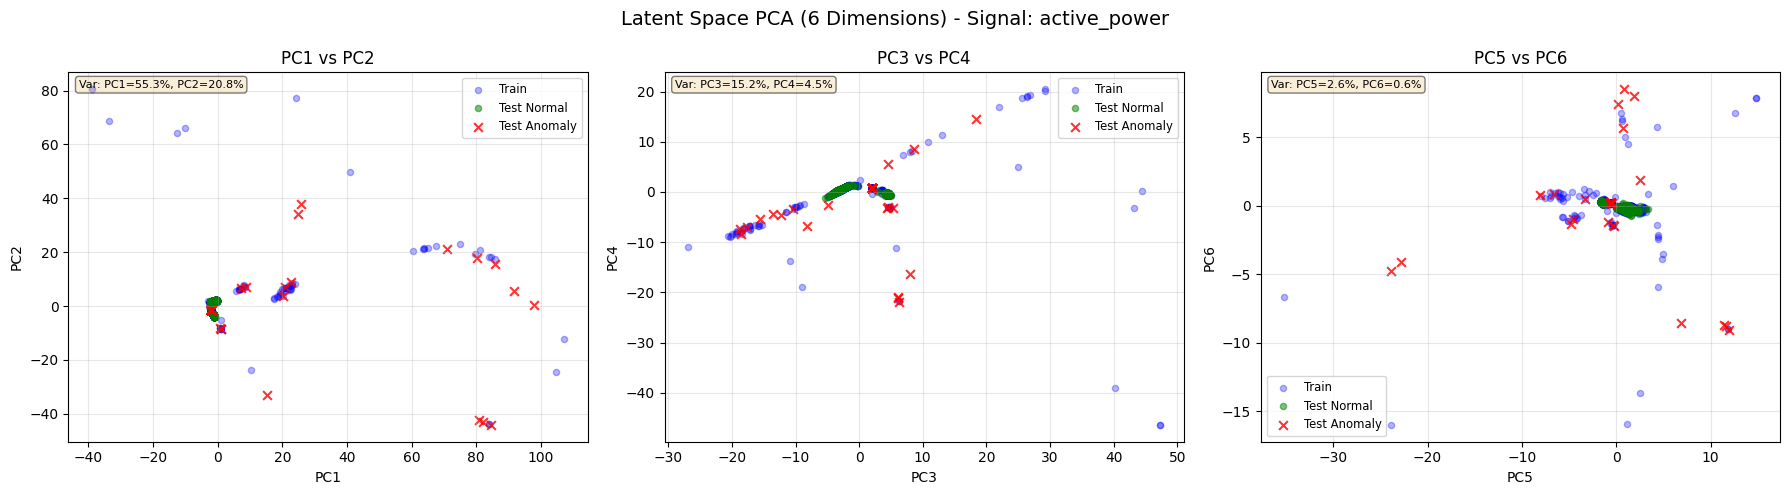


PCA Explained Variance Ratio for 'active_power':
  PC1: 55.28%
  PC2: 20.80%
  PC3: 15.16%
  PC4: 4.53%
  PC5: 2.64%
  PC6: 0.62%
  Total (PC1-PC6): 99.05%

Signal: ball_valve_closed


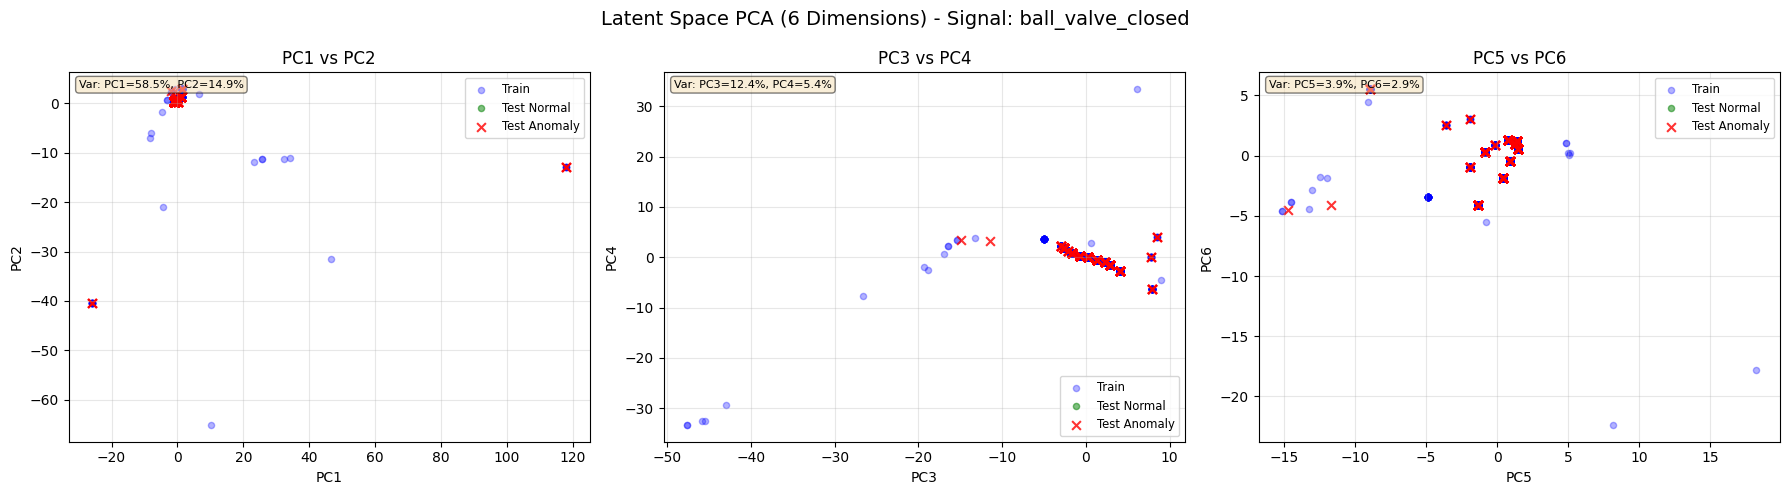


PCA Explained Variance Ratio for 'ball_valve_closed':
  PC1: 58.47%
  PC2: 14.93%
  PC3: 12.39%
  PC4: 5.39%
  PC5: 3.85%
  PC6: 2.86%
  Total (PC1-PC6): 97.89%

Signal: ball_valve_open


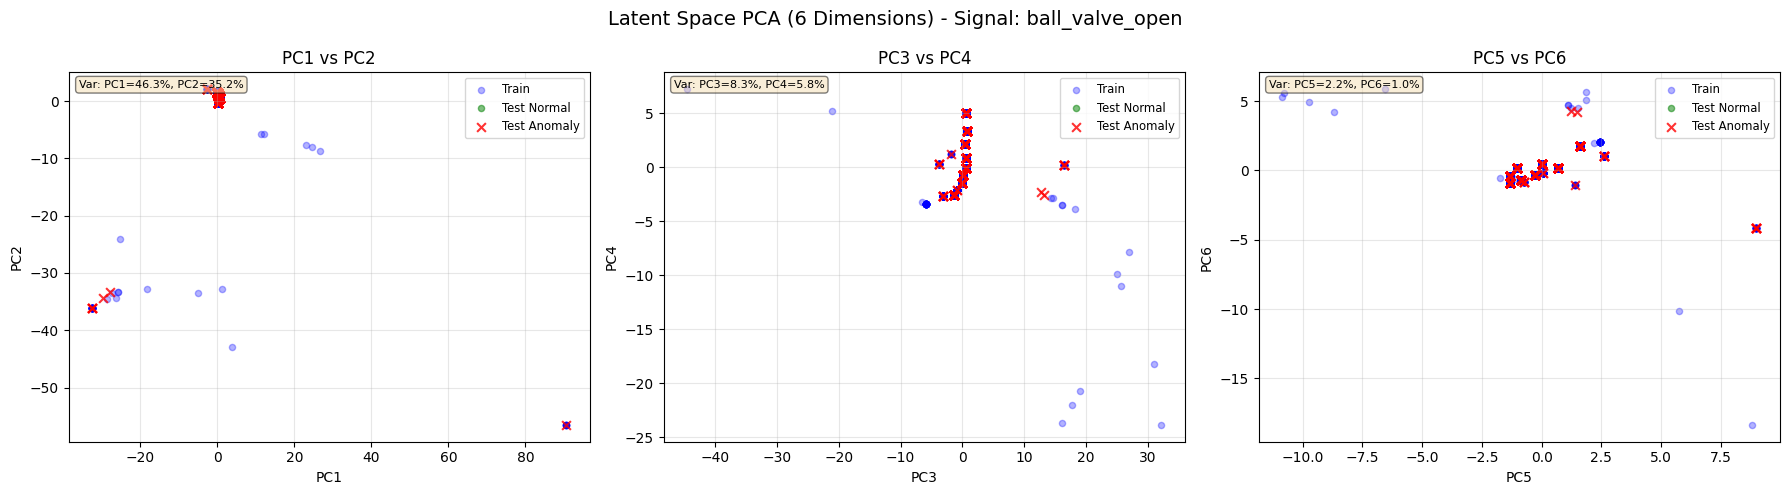


PCA Explained Variance Ratio for 'ball_valve_open':
  PC1: 46.26%
  PC2: 35.15%
  PC3: 8.33%
  PC4: 5.83%
  PC5: 2.17%
  PC6: 0.96%
  Total (PC1-PC6): 98.69%

Signal: guide_vane_position


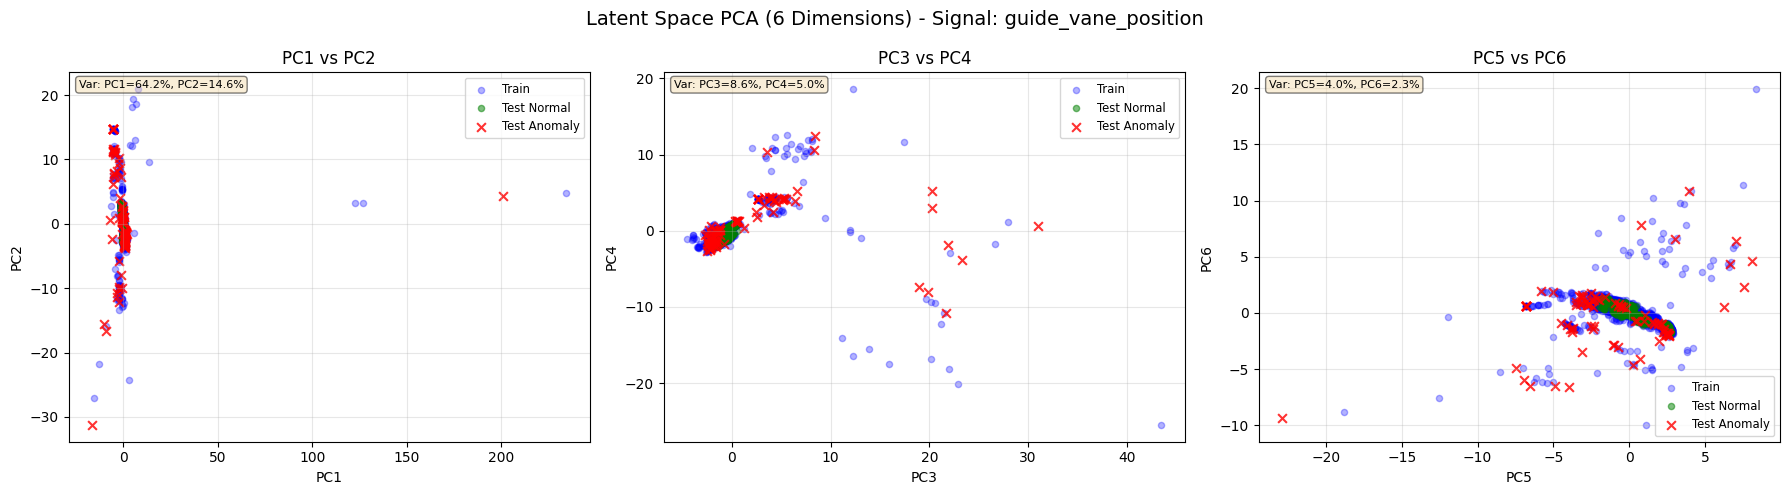


PCA Explained Variance Ratio for 'guide_vane_position':
  PC1: 64.18%
  PC2: 14.65%
  PC3: 8.59%
  PC4: 4.99%
  PC5: 3.98%
  PC6: 2.32%
  Total (PC1-PC6): 98.72%

Signal: water_pressure_downstream


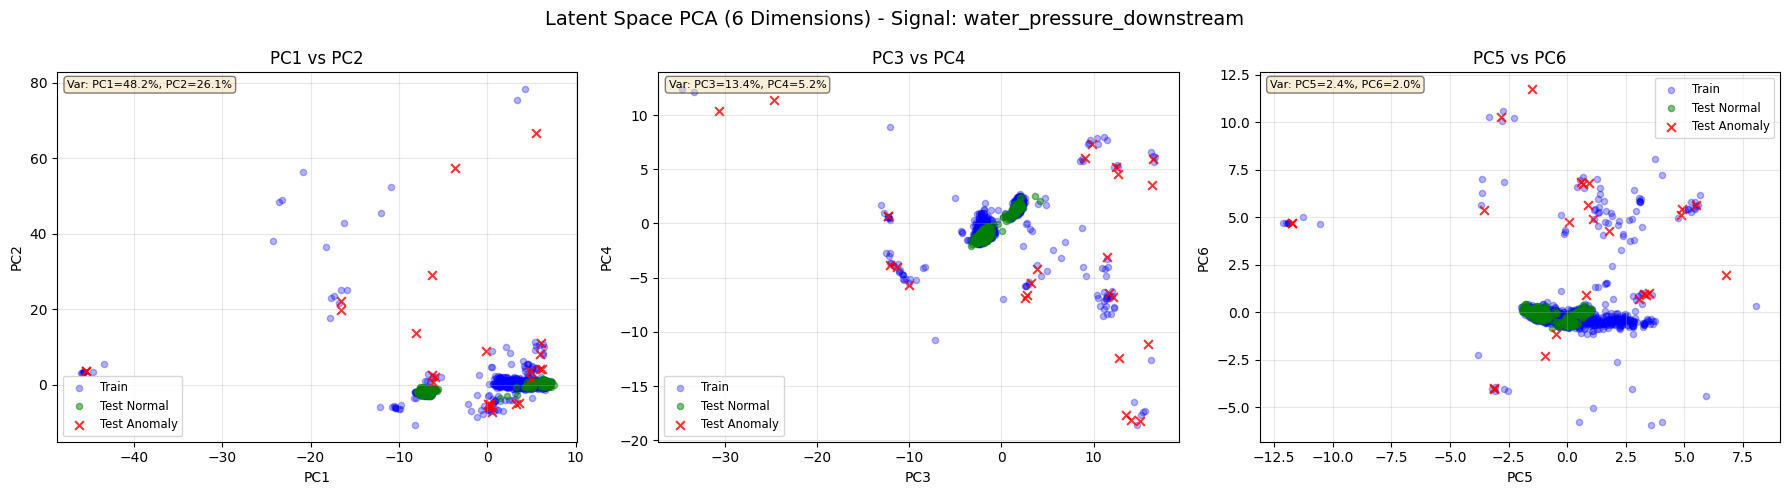


PCA Explained Variance Ratio for 'water_pressure_downstream':
  PC1: 48.20%
  PC2: 26.08%
  PC3: 13.44%
  PC4: 5.18%
  PC5: 2.39%
  PC6: 2.01%
  Total (PC1-PC6): 97.30%

Signal: water_pressure_upstream


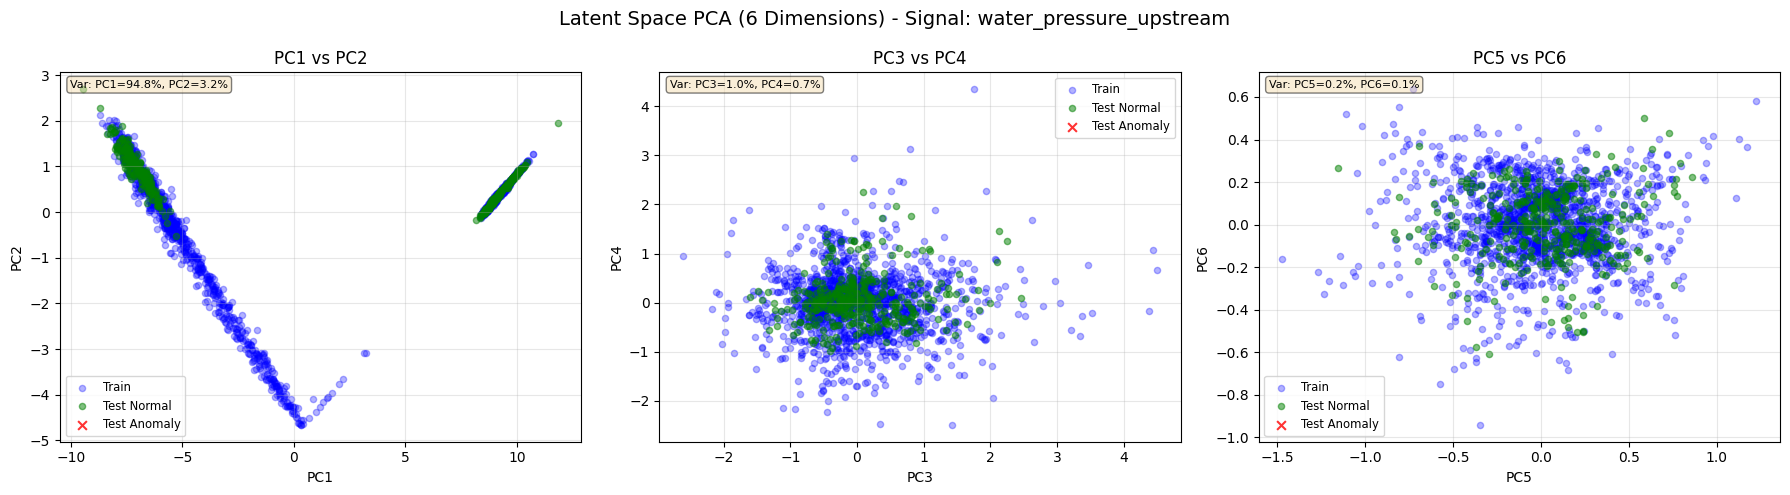


PCA Explained Variance Ratio for 'water_pressure_upstream':
  PC1: 94.81%
  PC2: 3.15%
  PC3: 1.05%
  PC4: 0.68%
  PC5: 0.20%
  PC6: 0.06%
  Total (PC1-PC6): 99.96%


In [ ]:
# ----------------------------------------------------------------------
# CALL: Plot 6 PCA dimensions for all signals
# ----------------------------------------------------------------------

# Plot 6 PCA dimensions for each signal
print("Plotting 6 PCA dimensions for each signal...")
for sig in list(latent_train.keys()):
    print(f"\n{'='*60}")
    print(f"Signal: {sig}")
    print('='*60)
    plot_latent_pca_6dims(latent_train, latent_test, flags, signal_name=sig)

PLOTTING ANOMALOUS WINDOWS - PER SIGNAL AUTOENCODERS (WITH RECONSTRUCTION)

1. Anomaly Summary per Signal:


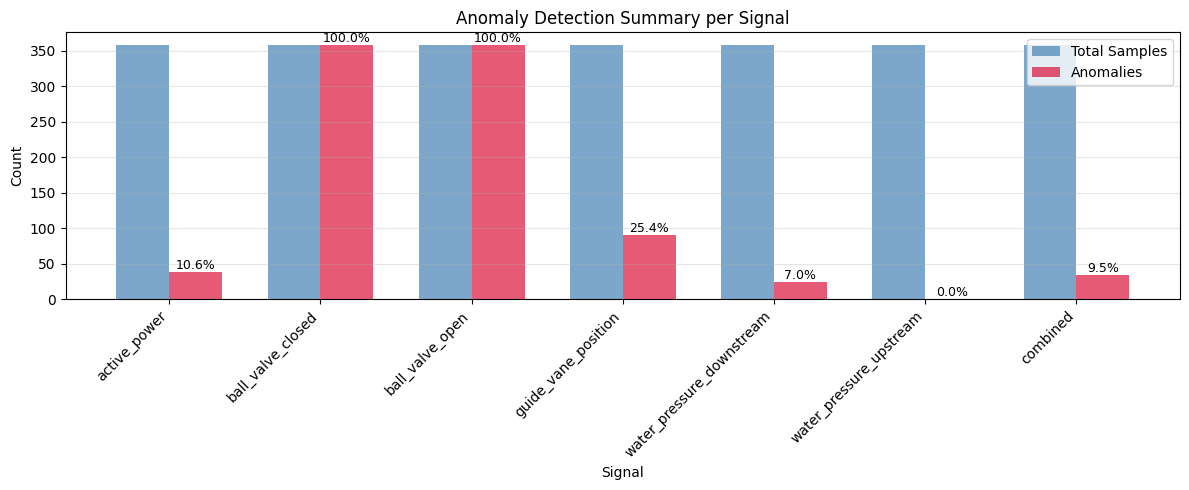


2. Anomalous Windows with Reconstruction (per Signal):

Signal: active_power
Total anomalies: 38


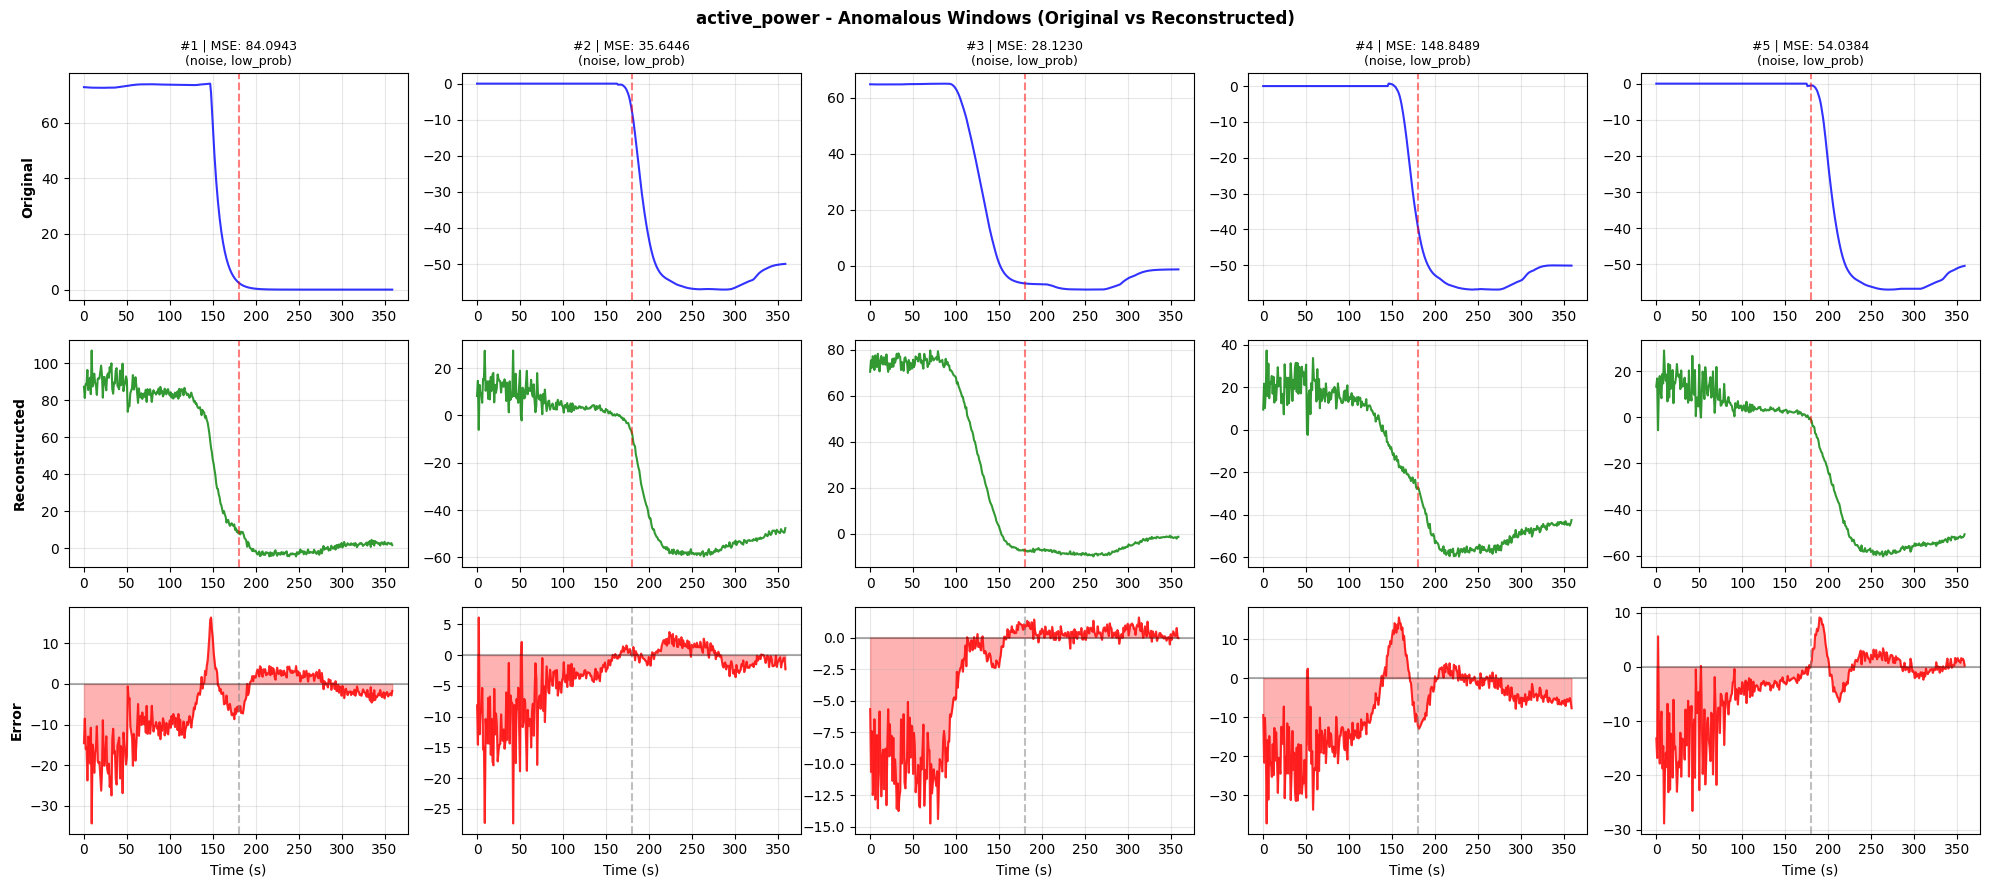


Signal: ball_valve_closed
Total anomalies: 358


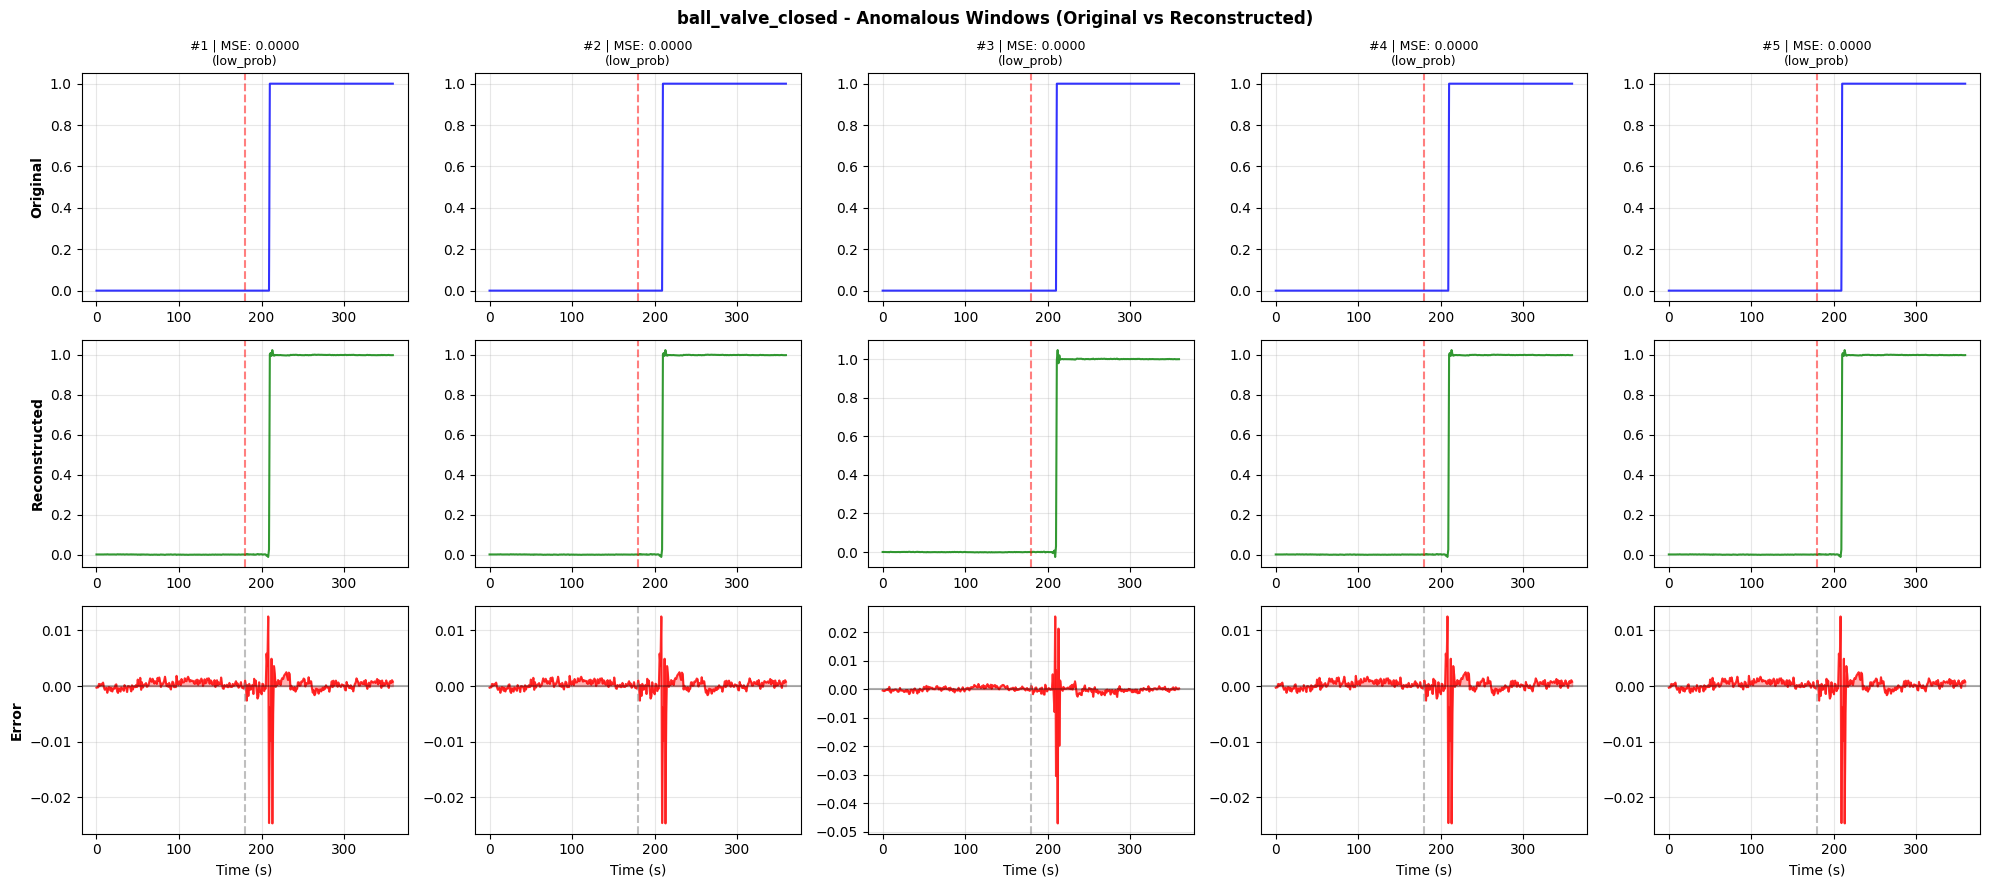


Signal: ball_valve_open
Total anomalies: 358


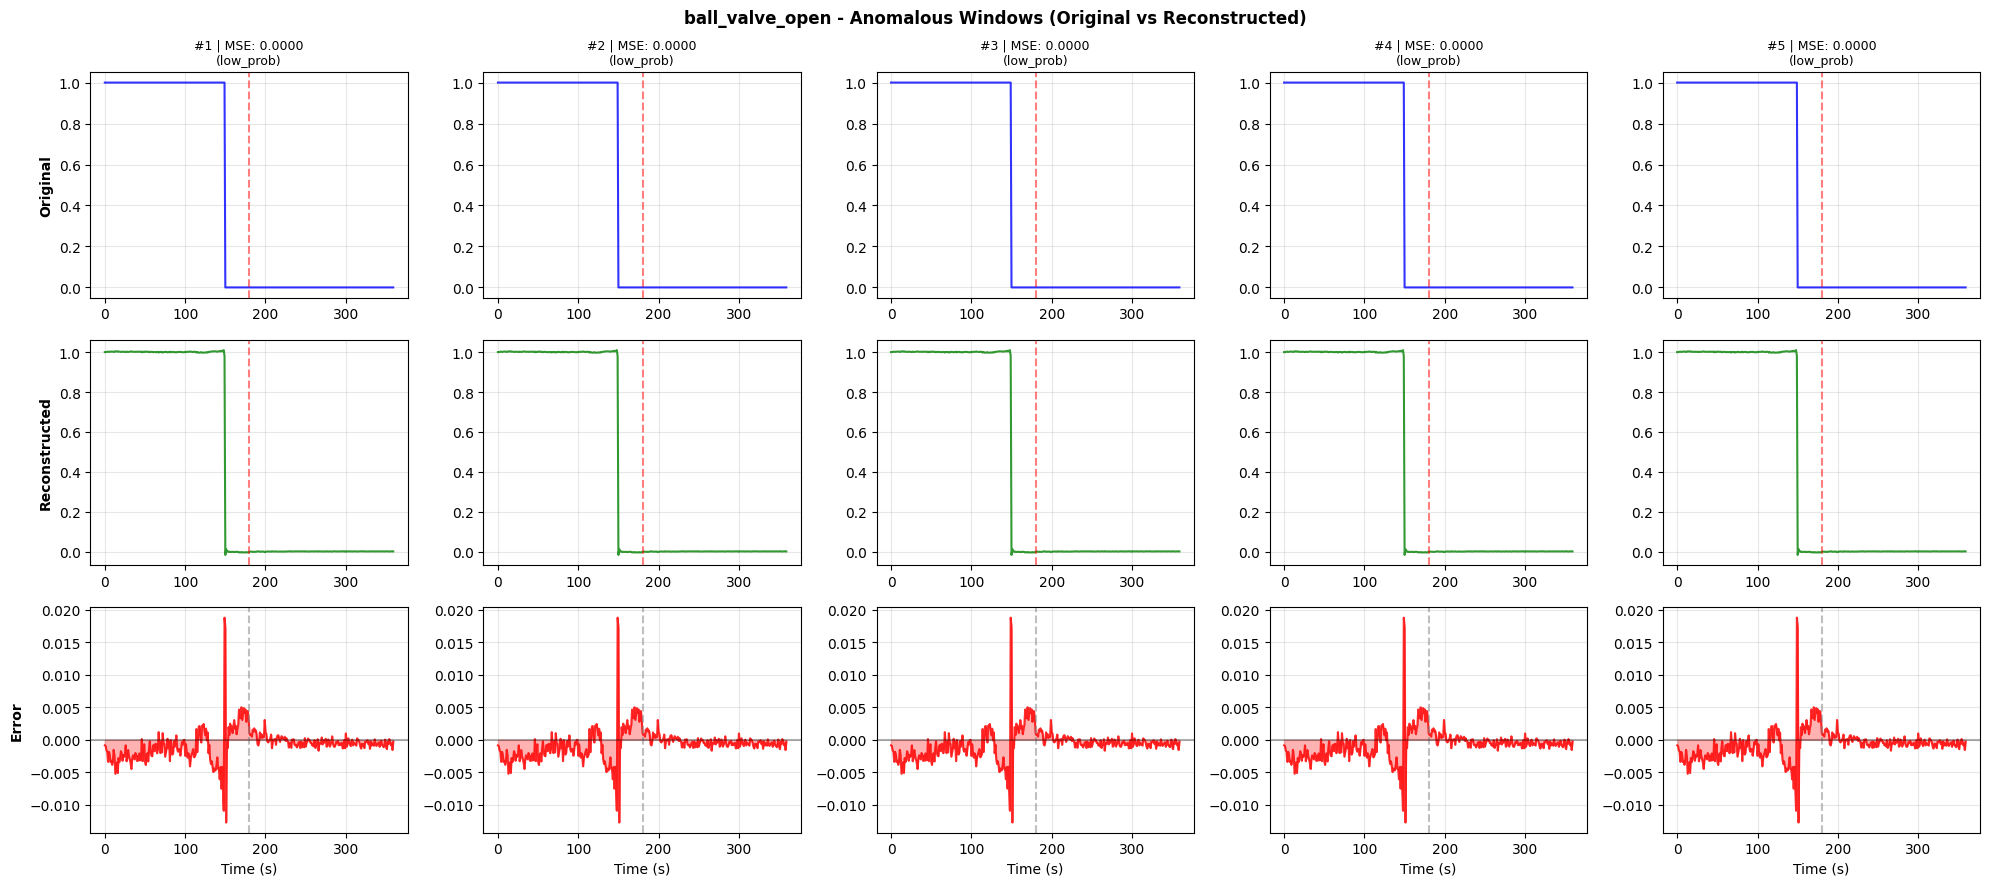


Signal: guide_vane_position
Total anomalies: 91


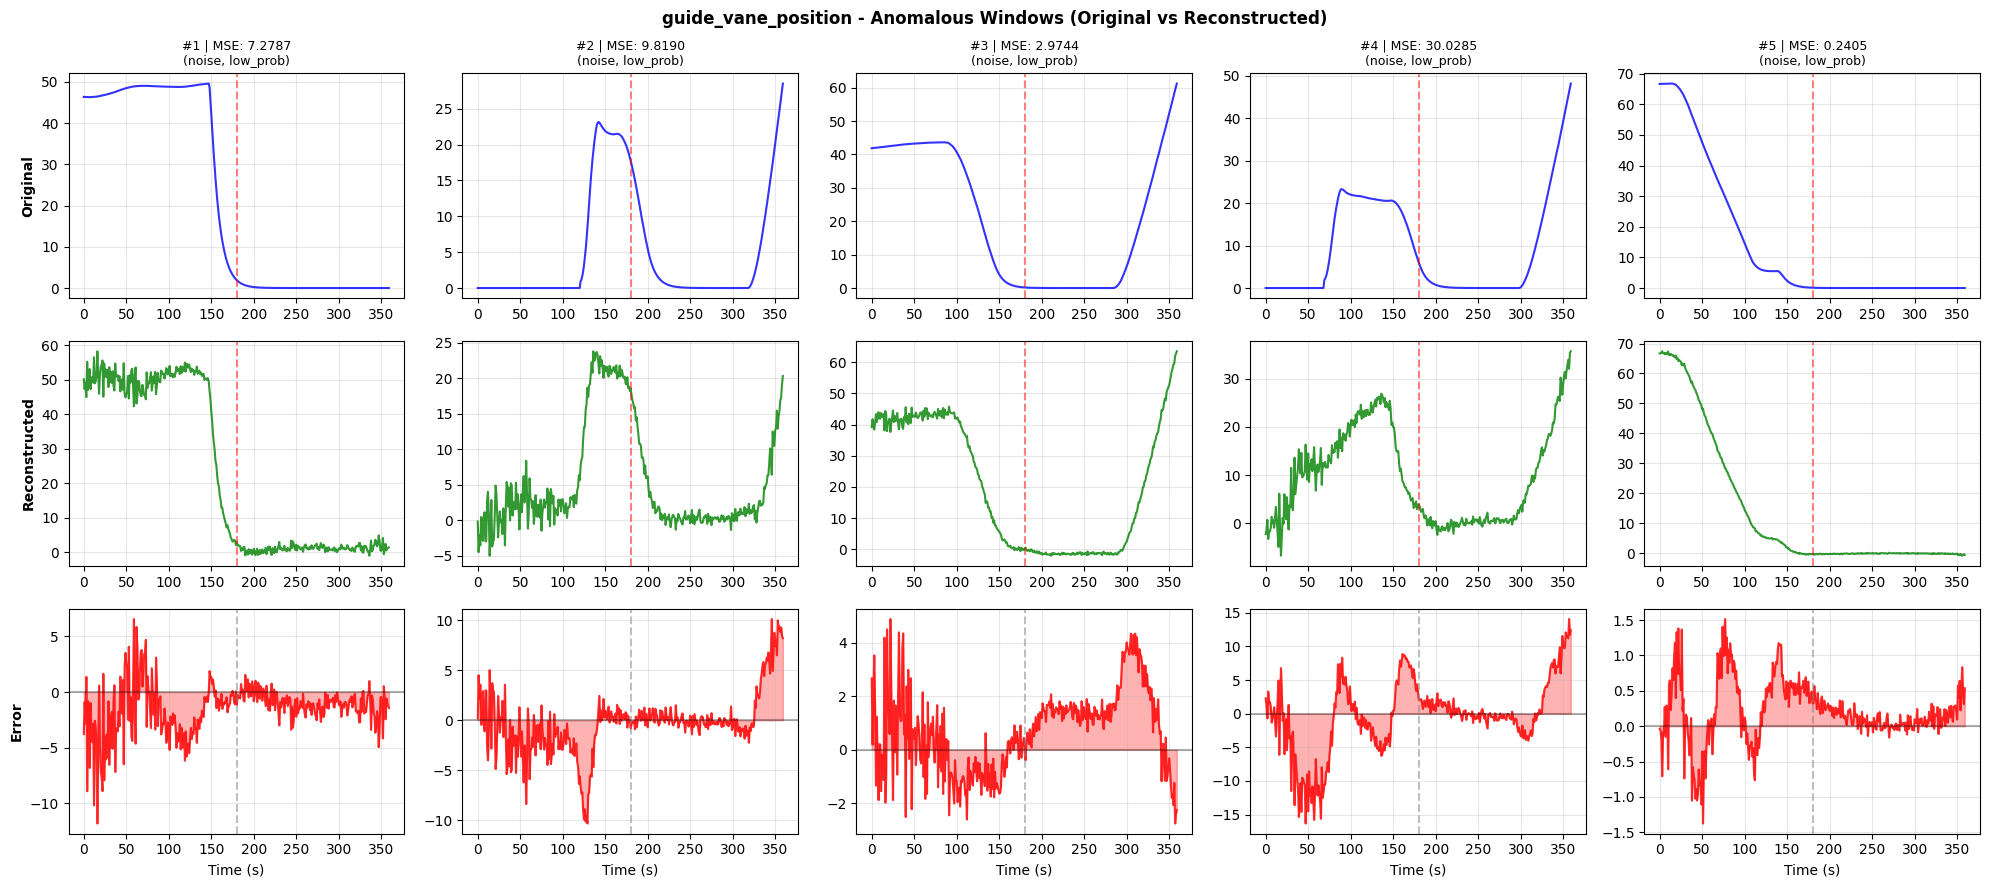


Signal: water_pressure_downstream
Total anomalies: 25


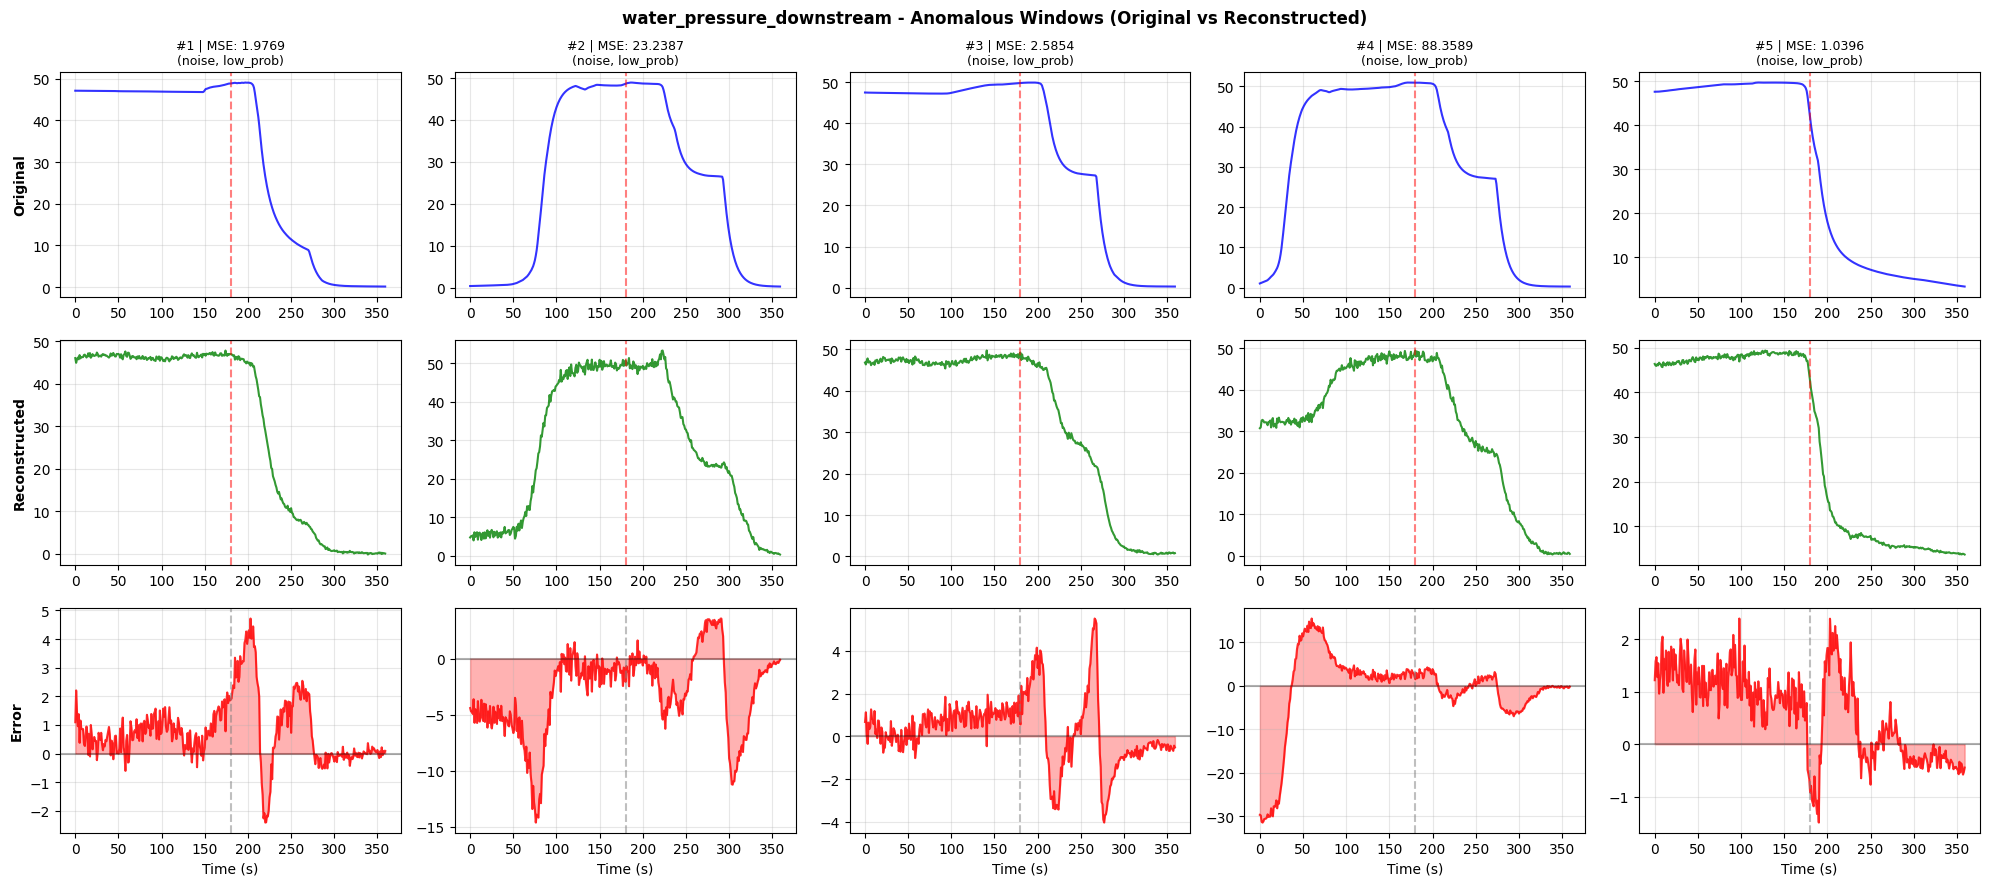

water_pressure_upstream: No anomalies detected

3. Normal vs Anomaly Comparison with Reconstruction:


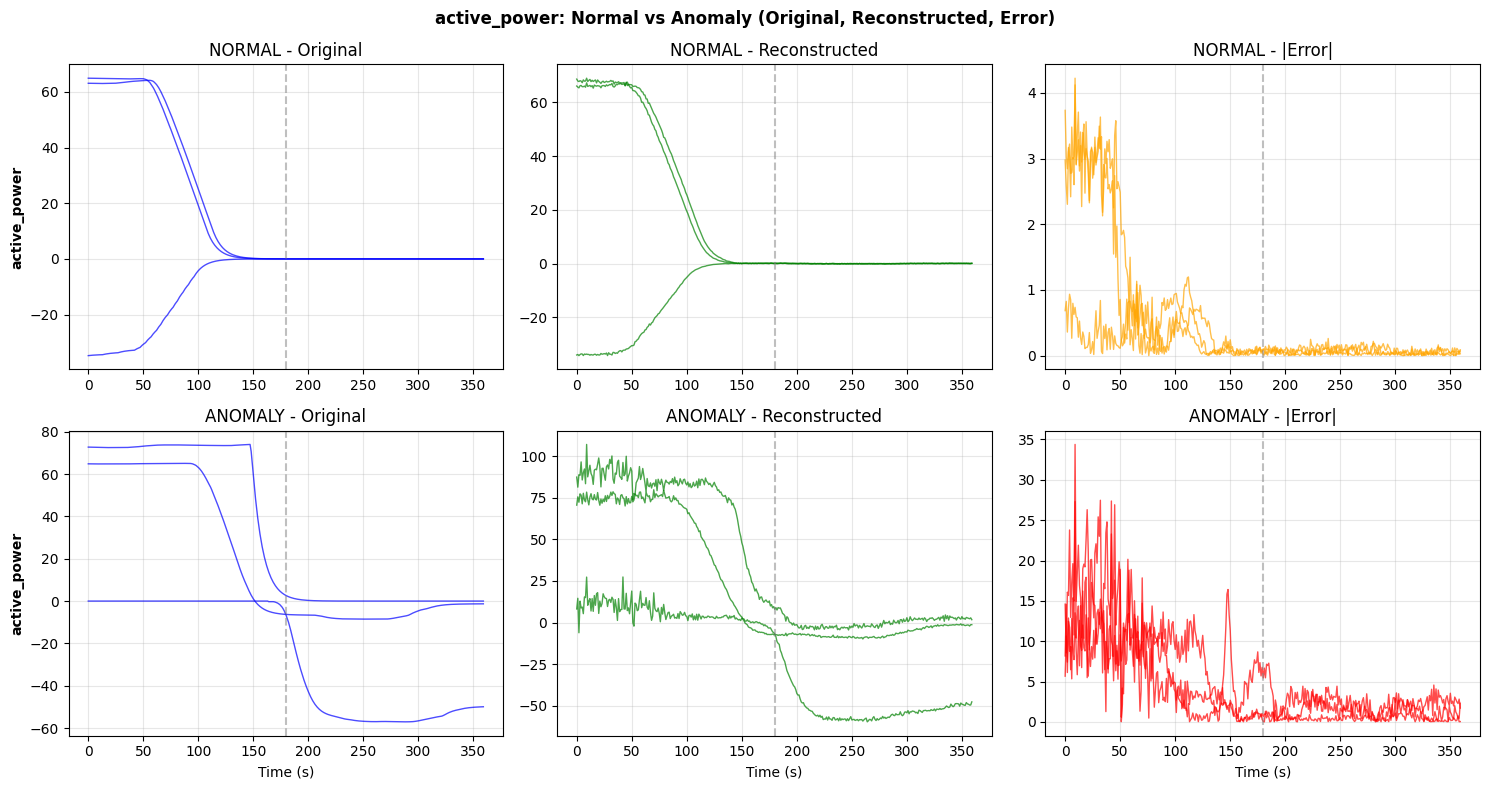

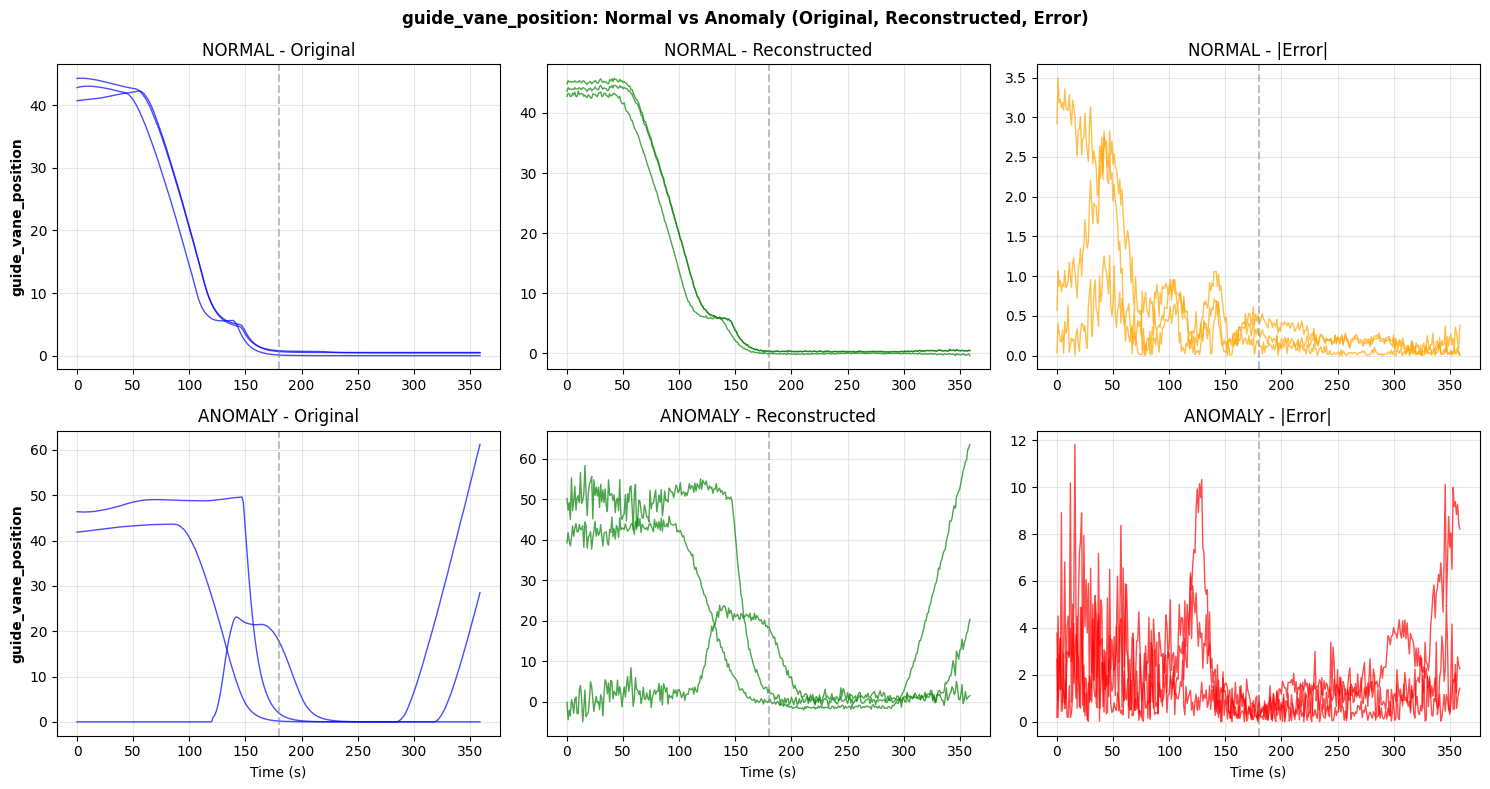

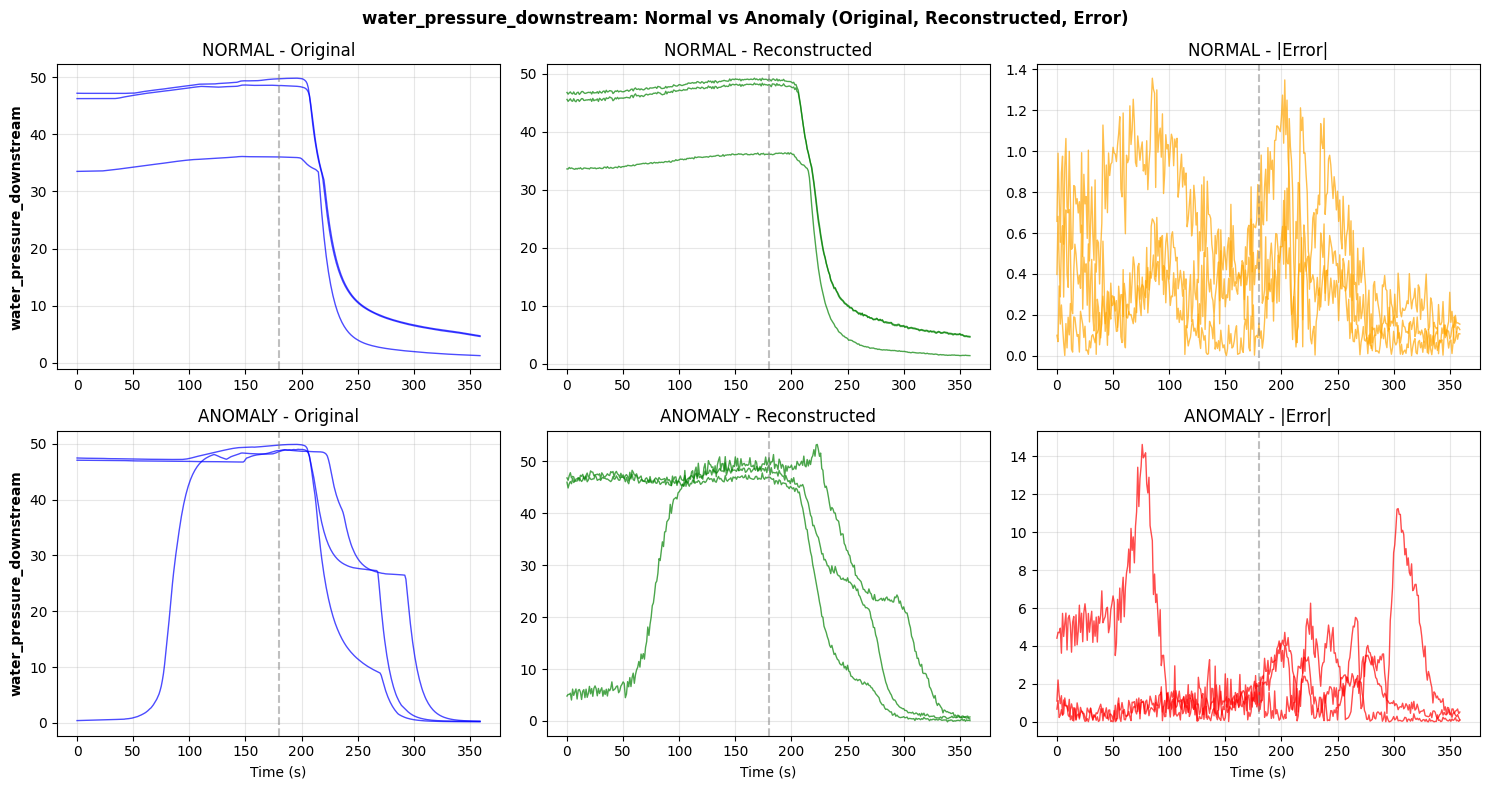

In [ ]:
# ----------------------------------------------------------------------
# PLOT ANOMALOUS WINDOWS - PER SIGNAL AUTOENCODERS (WITH RECONSTRUCTION)
# Visualize original, reconstructed, and error for per-signal anomalies
# ----------------------------------------------------------------------

def plot_persignal_anomalous_windows_with_reconstruction(test_windows, flags, signals, models, scalers, max_plots_per_signal=5):
    """
    Plot windows flagged as anomalies showing: Original, Reconstructed, and Error.
    
    Parameters:
    - test_windows: Dictionary of test windows per signal {signal_name: array of shape (N, 360)}
    - flags: Dictionary of flags per signal {signal_name: {'is_anomaly': bool array, 'reasons': list}}
    - signals: List of signal names
    - models: Dictionary of trained models per signal {signal_name: model}
    - scalers: Dictionary of scalers per signal {signal_name: scaler}
    - max_plots_per_signal: Maximum anomalous windows to plot per signal
    """
    import torch
    
    n_timesteps = 360
    time_axis = np.arange(n_timesteps)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    for sig in signals:
        if sig not in flags or sig not in test_windows:
            continue
        if sig not in models or sig not in scalers:
            print(f"{sig}: No model/scaler available, skipping reconstruction")
            continue
        
        X_sig = test_windows[sig]
        if X_sig is None or len(X_sig) == 0:
            continue
            
        is_anomaly = flags[sig]['is_anomaly']
        reasons = flags[sig].get('reasons', [['unknown']] * len(is_anomaly))
        anomaly_indices = np.where(is_anomaly)[0]
        
        n_anomalies = len(anomaly_indices)
        
        if n_anomalies == 0:
            print(f"{sig}: No anomalies detected")
            continue
            
        print(f"\n{'='*60}")
        print(f"Signal: {sig}")
        print(f"Total anomalies: {n_anomalies}")
        print(f"{'='*60}")
        
        n_to_plot = min(max_plots_per_signal, n_anomalies)
        
        # Get model and scaler for this signal
        model = models[sig]
        scaler = scalers[sig]
        
        # Get reconstructions for anomalous windows
        anomaly_windows = X_sig[anomaly_indices[:n_to_plot]]
        anomaly_scaled = scaler.transform(anomaly_windows)
        
        model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(anomaly_scaled).to(device)
            reconstructed_scaled, _ = model(X_tensor)
            reconstructed_scaled = reconstructed_scaled.cpu().numpy()
        
        reconstructed = scaler.inverse_transform(reconstructed_scaled)
        
        # Plot: 3 rows (Original, Reconstructed, Error) × n_to_plot columns
        fig, axes = plt.subplots(3, n_to_plot, figsize=(4*n_to_plot, 9))
        if n_to_plot == 1:
            axes = axes.reshape(3, 1)
        
        for plot_idx, (anom_idx, orig_window, recon_window) in enumerate(
                zip(anomaly_indices[:n_to_plot], anomaly_windows, reconstructed)):
            
            error = orig_window - recon_window
            mse = np.mean((orig_window - recon_window)**2)
            
            reason = reasons[anom_idx] if anom_idx < len(reasons) else ['unknown']
            reason_str = ', '.join(reason) if reason else 'unknown'
            
            # Original
            ax = axes[0, plot_idx]
            ax.plot(time_axis, orig_window, 'b-', linewidth=1.5, alpha=0.8)
            ax.axvline(x=n_timesteps//2, color='red', linestyle='--', alpha=0.5)
            ax.set_title(f'#{plot_idx+1} | MSE: {mse:.4f}\n({reason_str})', fontsize=9)
            if plot_idx == 0:
                ax.set_ylabel('Original', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Reconstructed
            ax = axes[1, plot_idx]
            ax.plot(time_axis, recon_window, 'g-', linewidth=1.5, alpha=0.8)
            ax.axvline(x=n_timesteps//2, color='red', linestyle='--', alpha=0.5)
            if plot_idx == 0:
                ax.set_ylabel('Reconstructed', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Error
            ax = axes[2, plot_idx]
            ax.plot(time_axis, error, 'r-', linewidth=1.5, alpha=0.8)
            ax.fill_between(time_axis, 0, error, alpha=0.3, color='red')
            ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
            ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax.set_xlabel('Time (s)')
            if plot_idx == 0:
                ax.set_ylabel('Error', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'{sig} - Anomalous Windows (Original vs Reconstructed)', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

def plot_persignal_comparison_with_reconstruction(train_windows, test_windows, flags, signals, models, scalers, n_normal=3, n_anomaly=3):
    """
    Compare normal vs anomalous windows for each signal, showing Original and Reconstructed.
    """
    import torch
    
    n_timesteps = 360
    time_axis = np.arange(n_timesteps)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    for sig in signals:
        if sig not in flags or sig not in test_windows:
            continue
        if sig not in models or sig not in scalers:
            continue
        
        X_test = test_windows[sig]
        X_train = train_windows.get(sig)
        
        if X_test is None or len(X_test) == 0:
            continue
            
        is_anomaly = flags[sig]['is_anomaly']
        normal_indices = np.where(~is_anomaly)[0]
        anomaly_indices = np.where(is_anomaly)[0]
        
        if len(anomaly_indices) == 0:
            continue
        
        model = models[sig]
        scaler = scalers[sig]
        model.eval()
        
        # Select samples
        n_normal_plot = min(n_normal, len(normal_indices))
        n_anomaly_plot = min(n_anomaly, len(anomaly_indices))
        
        if n_normal_plot == 0:
            continue
        
        normal_samples = np.random.choice(normal_indices, n_normal_plot, replace=False)
        anomaly_samples = anomaly_indices[:n_anomaly_plot]
        
        # Get reconstructions
        selected_indices = np.concatenate([normal_samples, anomaly_samples])
        selected_windows = X_test[selected_indices]
        selected_scaled = scaler.transform(selected_windows)
        
        with torch.no_grad():
            X_tensor = torch.FloatTensor(selected_scaled).to(device)
            reconstructed_scaled, _ = model(X_tensor)
            reconstructed_scaled = reconstructed_scaled.cpu().numpy()
        
        reconstructed = scaler.inverse_transform(reconstructed_scaled)
        
        # Split back
        normal_orig = selected_windows[:n_normal_plot]
        normal_recon = reconstructed[:n_normal_plot]
        anomaly_orig = selected_windows[n_normal_plot:]
        anomaly_recon = reconstructed[n_normal_plot:]
        
        # Plot: 2 rows (Normal, Anomaly) × 3 cols (Original, Reconstructed, Error)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        # --- NORMAL SAMPLES ---
        ax = axes[0, 0]
        for window in normal_orig:
            ax.plot(time_axis, window, alpha=0.7, linewidth=1, color='blue')
        ax.set_title('NORMAL - Original')
        ax.set_ylabel(sig, fontsize=10, fontweight='bold')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        ax = axes[0, 1]
        for window in normal_recon:
            ax.plot(time_axis, window, alpha=0.7, linewidth=1, color='green')
        ax.set_title('NORMAL - Reconstructed')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        ax = axes[0, 2]
        for orig, recon in zip(normal_orig, normal_recon):
            error = np.abs(orig - recon)
            ax.plot(time_axis, error, alpha=0.7, linewidth=1, color='orange')
        ax.set_title('NORMAL - |Error|')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # --- ANOMALY SAMPLES ---
        ax = axes[1, 0]
        for window in anomaly_orig:
            ax.plot(time_axis, window, alpha=0.7, linewidth=1, color='blue')
        ax.set_title('ANOMALY - Original')
        ax.set_ylabel(sig, fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        ax = axes[1, 1]
        for window in anomaly_recon:
            ax.plot(time_axis, window, alpha=0.7, linewidth=1, color='green')
        ax.set_title('ANOMALY - Reconstructed')
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        ax = axes[1, 2]
        for orig, recon in zip(anomaly_orig, anomaly_recon):
            error = np.abs(orig - recon)
            ax.plot(time_axis, error, alpha=0.7, linewidth=1, color='red')
        ax.set_title('ANOMALY - |Error|')
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'{sig}: Normal vs Anomaly (Original, Reconstructed, Error)', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

def plot_persignal_summary(flags, signals):
    """Plot summary bar chart of anomalies per signal."""
    signal_names = []
    n_total = []
    n_anomalies = []
    
    for sig in signals:
        if sig not in flags:
            continue
        signal_names.append(sig)
        n_total.append(len(flags[sig]['is_anomaly']))
        n_anomalies.append(flags[sig]['n_anomalies'])
    
    if 'combined' in flags:
        signal_names.append('combined')
        n_total.append(len(flags['combined']['is_anomaly']))
        n_anomalies.append(flags['combined']['n_anomalies'])
    
    x = np.arange(len(signal_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, n_total, width, label='Total Samples', color='steelblue', alpha=0.7)
    bars2 = ax.bar(x + width/2, n_anomalies, width, label='Anomalies', color='crimson', alpha=0.7)
    
    ax.set_xlabel('Signal')
    ax.set_ylabel('Count')
    ax.set_title('Anomaly Detection Summary per Signal')
    ax.set_xticks(x)
    ax.set_xticklabels(signal_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, (tot, anom) in enumerate(zip(n_total, n_anomalies)):
        pct = 100 * anom / tot if tot > 0 else 0
        ax.annotate(f'{pct:.1f}%', xy=(x[i] + width/2, anom), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# RUN VISUALIZATION FOR PER-SIGNAL AUTOENCODERS (WITH RECONSTRUCTION)
# ==============================================================================
print("="*60)
print("PLOTTING ANOMALOUS WINDOWS - PER SIGNAL AUTOENCODERS (WITH RECONSTRUCTION)")
print("="*60)

# Summary chart
print("\n1. Anomaly Summary per Signal:")
plot_persignal_summary(flags, SIGNALS)

# Plot anomalous windows with reconstruction per signal
print("\n2. Anomalous Windows with Reconstruction (per Signal):")
plot_persignal_anomalous_windows_with_reconstruction(
    test_windows, flags, SIGNALS, models, scalers, max_plots_per_signal=5
)

# Comparison: Normal vs Anomaly with Reconstruction
print("\n3. Normal vs Anomaly Comparison with Reconstruction:")
plot_persignal_comparison_with_reconstruction(
    train_windows, test_windows, flags, SIGNALS, models, scalers, n_normal=3, n_anomaly=3
)

AUTOENCODER + HDBSCAN ANOMALY DETECTION (COMBINED SIGNALS)
Training on ALL SIGNALS combined (6 signals × 360 timesteps = 2160 features)

1. Loading training windows...
   [FILTER] Only loading CLOSING transitions (opening transitions will be skipped)


Loading training windows:   0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated an

   Training windows: 1564

2. Loading testing windows...
   [FILTER] Only loading CLOSING transitions (opening transitions will be skipped)


Loading testing windows:   0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_9357/2348219128.py:123: FutureWarning: DataFrame.fillna with 'method' is deprecated an

   Testing windows: 358

3. Training Autoencoder (single model for all signals)...
Training autoencoder on 1564 samples...
Input dimension: 2160 (6 signals × 360 timesteps)


Training Combined AE:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 10/50: train_loss=0.1403, val_loss=0.0643
  Epoch 20/50: train_loss=0.0559, val_loss=0.0295
  Epoch 30/50: train_loss=0.0979, val_loss=0.0324
  Epoch 40/50: train_loss=0.1069, val_loss=0.0303
  Epoch 50/50: train_loss=0.0393, val_loss=0.0209

4. Plotting training history...


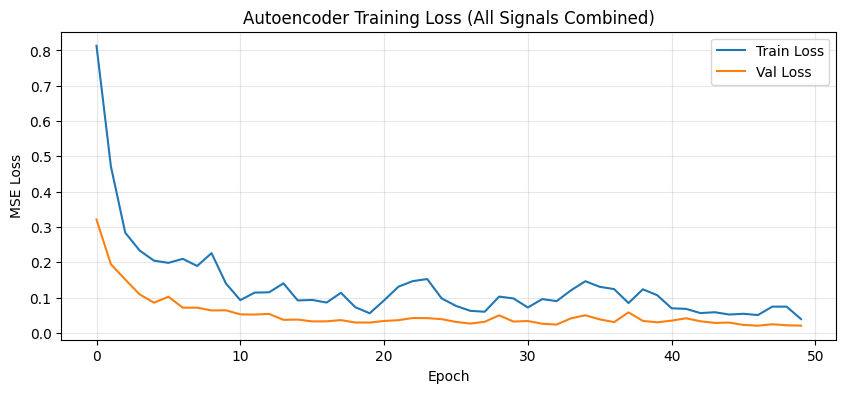


5. Extracting latent representations...
   Latent train shape: (1564, 32)
   Latent test shape: (358, 32)

6. Fitting HDBSCAN...


/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN: 2 clusters, 137 noise points out of 1564

7. Flagging anomalies in test data...

Anomaly Detection Results:
  Total test samples: 358
  Anomalies flagged: 41 (11.5%)
  - Noise: 41
  - Small cluster: 0
  - Low probability: 41

8. Visualizing results...


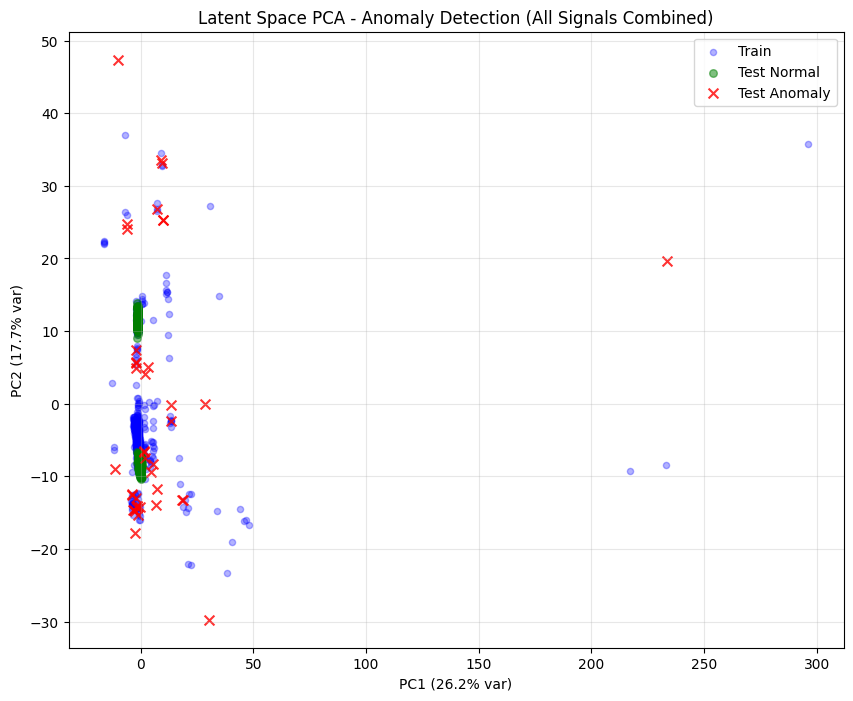

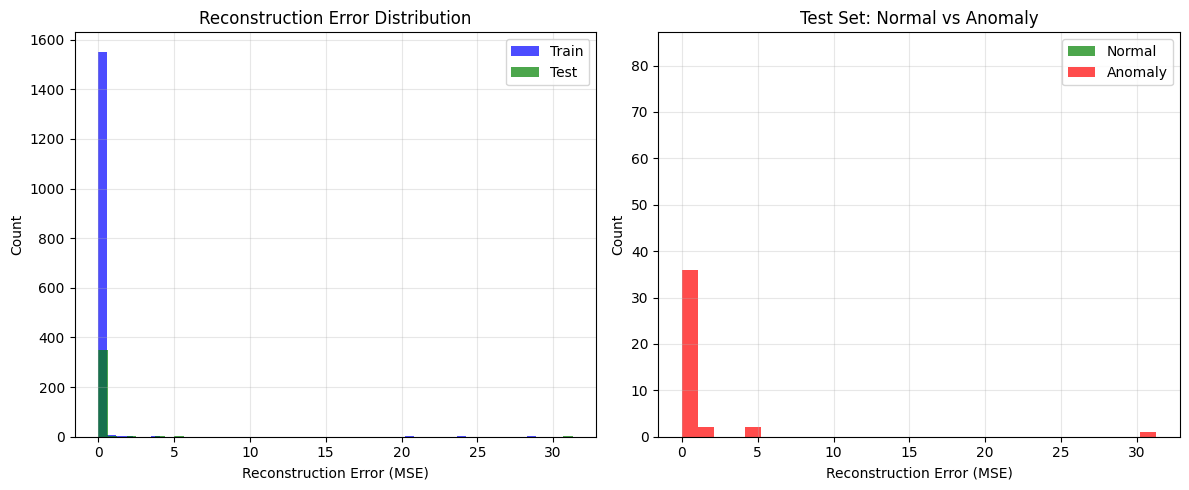

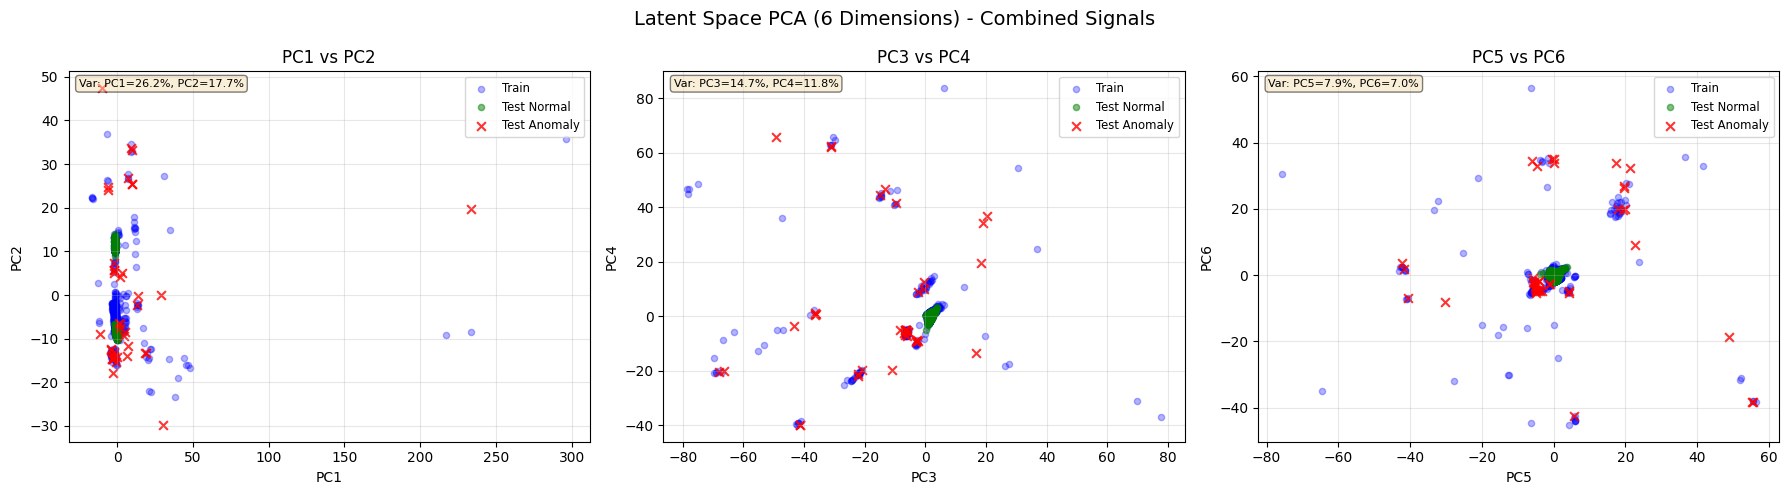


PCA Explained Variance Ratio:
  PC1: 26.19%
  PC2: 17.71%
  PC3: 14.69%
  PC4: 11.83%
  PC5: 7.89%
  PC6: 7.00%
  Total (PC1-PC6): 85.30%

Pipeline complete!


In [ ]:
# ----------------------------------------------------------------------
# AUTOENCODER + HDBSCAN ANOMALY DETECTION PIPELINE
# VERSION 2: Trains a SINGLE autoencoder on ALL SIGNALS combined
# ----------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
import hdbscan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import pickle

# Configuration
WINDOW_SECONDS = 360
HALF_WINDOW = 180
BATCH_SIZE_AE2 = 64
EPOCHS_AE2 = 50
LEARNING_RATE_AE2 = 0.001
BOTTLENECK_DIM_AE2 = 32
TRANSITIONS_DIR = 'data_transitions'

SIGNALS = ['active_power', 'ball_valve_closed', 'ball_valve_open',
           'guide_vane_position', 'water_pressure_downstream', 'water_pressure_upstream']

# ==============================================================================
# 1. DENSE AUTOENCODER DEFINITION (All Signals Combined)
# ==============================================================================
class DenseAutoencoderCombined(nn.Module):
    """
    Dense Autoencoder for combined multi-signal input.
    Input: Flattened window (6 signals × 360 timesteps = 2160 features)
    
    Architecture:
    - Encoder: input_dim → 512 → 128 → bottleneck_dim
    - Decoder: bottleneck_dim → 128 → 512 → input_dim
    """
    def __init__(self, input_dim, bottleneck_dim=32):
        super(DenseAutoencoderCombined, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_dim),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        reconstruction = self.decoder(features)
        return reconstruction, features

# ==============================================================================
# 2. WINDOW EXTRACTION (All Signals Combined & Flattened)
# ==============================================================================
class WindowExtractorCombined:
    """Extract windows with ALL signals combined (flattened)."""
    def __init__(self, data_dir, half_window=180, closing_only=True):
        self.data_dir = data_dir
        self.half_window = half_window
        self.feature_cols = SIGNALS
        self.closing_only = closing_only  # If True, only extract windows for valve CLOSING transitions
    
    def _is_closing_transition(self, group):
        """
        Determine if a transition group represents a valve CLOSING.
        
        Closing logic:
        - ball_valve_open goes 1→0 (valve leaving open state)
        - ball_valve_closed goes 0→1 (valve reaching closed state)
        
        Returns: True if closing, False if opening, None if undetermined
        """
        votes_opening = 0
        votes_closing = 0
        
        for row in group:
            sig = row['signal']
            v_from = row['from_value']
            v_to = row['to_value']
            
            if sig == 'ball_valve_open':
                if v_from == 0 and v_to == 1:  # Valve opening
                    votes_opening += 1
                elif v_from == 1 and v_to == 0:  # Valve closing
                    votes_closing += 1
            elif sig == 'ball_valve_closed':
                if v_from == 0 and v_to == 1:  # Valve closing (reached closed)
                    votes_closing += 1
                elif v_from == 1 and v_to == 0:  # Valve opening (leaving closed)
                    votes_opening += 1
        
        if votes_closing > votes_opening:
            return True  # Closing
        elif votes_opening > votes_closing:
            return False  # Opening
        else:
            return None  # Undetermined
        
    def extract_windows(self, processed_file, transitions_file):
        """Extract flattened windows centered on transitions.
        
        If closing_only=True, only extract windows for valve CLOSING transitions.
        """
        if not os.path.exists(processed_file) or not os.path.exists(transitions_file):
            return []
            
        df = pd.read_pickle(processed_file)
        df = df.reindex(columns=self.feature_cols)
        df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
        
        df_trans = pd.read_pickle(transitions_file)
        
        if df_trans.empty:
            return []
            
        # Group transitions within 180s
        df_trans = df_trans.sort_values('timestamp')
        grouped_events = []
        
        current_group = [df_trans.iloc[0]]
        for i in range(1, len(df_trans)):
            curr = df_trans.iloc[i]
            prev = current_group[-1]
            diff = (curr['timestamp'] - prev['timestamp']).total_seconds()
            
            if diff < 180:
                current_group.append(curr)
            else:
                grouped_events.append(current_group)
                current_group = [curr]
        grouped_events.append(current_group)
        
        # Extract flattened windows (ALL signals combined)
        windows = []
        
        for group in grouped_events:
            # Filter for closing transitions only if enabled
            if self.closing_only:
                is_closing = self._is_closing_transition(group)
                if is_closing is False:  # Opening transition - skip
                    continue
                elif is_closing is None:  # Undetermined - skip
                    continue
            min_ts = group[0]['timestamp']
            max_ts = group[-1]['timestamp']
            center_ts = min_ts + (max_ts - min_ts) / 2
            center_ts = center_ts.round('1s')
            
            try:
                idx = df.index.searchsorted(center_ts)
                if idx == 0:
                    center_idx = 0
                elif idx == len(df):
                    center_idx = len(df) - 1
                else:
                    ts_prev = df.index[idx-1]
                    ts_curr = df.index[idx]
                    if abs((ts_curr - center_ts).total_seconds()) < abs((ts_prev - center_ts).total_seconds()):
                        center_idx = idx
                    else:
                        center_idx = idx - 1
                
                start_idx = center_idx - self.half_window
                end_idx = center_idx + self.half_window
                
                if start_idx < 0 or end_idx > len(df):
                    continue
                
                window_df = df.iloc[start_idx:end_idx][self.feature_cols]
                
                if window_df.shape[0] == 2 * self.half_window:
                    # Flatten: (360, 6) → (2160,)
                    windows.append(window_df.values.flatten())
            except Exception:
                continue
                
        return windows

def load_combined_windows(split='training', closing_only=True):
    """Load ALL windows as flattened arrays (all signals combined).
    
    Args:
        split: 'training' or 'testing'
        closing_only: If True, only load windows for valve CLOSING transitions (default: True)
    """
    extractor = WindowExtractorCombined(TRANSITIONS_DIR, half_window=HALF_WINDOW, closing_only=closing_only)
    
    all_windows = []
    files = [f for f in os.listdir(TRANSITIONS_DIR) if f.endswith('_processed.pkl') and split in f]
    
    if closing_only:
        print(f"   [FILTER] Only loading CLOSING transitions (opening transitions will be skipped)")
    
    for f in tqdm(files, desc=f"Loading {split} windows"):
        base = f.replace('_processed.pkl', '')
        processed_path = os.path.join(TRANSITIONS_DIR, f)
        transitions_path = os.path.join(TRANSITIONS_DIR, f"{base}_transitions.pkl")
        
        windows = extractor.extract_windows(processed_path, transitions_path)
        all_windows.extend(windows)
    
    return np.array(all_windows) if all_windows else None

# ==============================================================================
# 3. TRAIN SINGLE AUTOENCODER (All Signals Combined)
# ==============================================================================
def train_combined_autoencoder(X_train, epochs=50, batch_size=64, lr=0.001, bottleneck_dim=32):
    """Train ONE autoencoder on all combined signals."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    print(f"Training autoencoder on {len(X_train)} samples...")
    print(f"Input dimension: {X_train.shape[1]} (6 signals × 360 timesteps)")
    
    # Normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    
    # Train/Val Split
    dataset = TensorDataset(torch.FloatTensor(X_scaled))
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    
    # Model
    input_dim = X_train.shape[1]
    model = DenseAutoencoderCombined(input_dim=input_dim, bottleneck_dim=bottleneck_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    # Training Loop
    history = {'train': [], 'val': []}
    for ep in tqdm(range(epochs), desc="Training Combined AE"):
        # Train
        model.train()
        train_loss = 0
        for (x,) in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = loss_fn(recon, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                val_loss += loss_fn(recon, x).item()
        val_loss /= len(val_loader)
        
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        
        if (ep + 1) % 10 == 0:
            print(f"  Epoch {ep+1}/{epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    
    return model, scaler, history

# ==============================================================================
# 4. EXTRACT LATENT REPRESENTATIONS
# ==============================================================================
def extract_combined_latent(model, scaler, X):
    """Extract latent features from the autoencoder."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    X_scaled = scaler.transform(X)
    model.eval()
    with torch.no_grad():
        _, features = model(torch.FloatTensor(X_scaled).to(device))
        return features.cpu().numpy()

# ==============================================================================
# 5. HDBSCAN ANOMALY DETECTION
# ==============================================================================
def fit_combined_hdbscan(latent_train, min_cluster_ratio=0.1):
    """Fit HDBSCAN on training latent space."""
    min_size = max(5, int(len(latent_train) * min_cluster_ratio))
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_size, metric='euclidean', prediction_data=True)
    clusterer.fit(latent_train)
    
    n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
    n_noise = sum(clusterer.labels_ == -1)
    print(f"HDBSCAN: {n_clusters} clusters, {n_noise} noise points out of {len(latent_train)}")
    
    return clusterer

def flag_combined_anomalies(clusterer, latent_train, latent_test, prob_threshold=0.1, small_cluster_threshold=0.05):
    """Flag test samples as anomalies."""
    
    # Get small clusters
    unique, counts = np.unique(clusterer.labels_[clusterer.labels_ >= 0], return_counts=True)
    total = len(clusterer.labels_)
    small_clusters = set(unique[counts < total * small_cluster_threshold])
    
    # Predict on test data
    test_labels, probs = hdbscan.approximate_predict(clusterer, latent_test)
    
    # Flag reasons
    n = len(test_labels)
    reasons = []
    for i in range(n):
        r = []
        if test_labels[i] == -1:
            r.append('noise')
        if test_labels[i] in small_clusters:
            r.append('small_cluster')
        if probs[i] < prob_threshold:
            r.append('low_prob')
        reasons.append(r if r else ['normal'])
    
    is_anomaly = np.array([len(r) > 0 and r != ['normal'] for r in reasons])
    
    print(f"\nAnomaly Detection Results:")
    print(f"  Total test samples: {n}")
    print(f"  Anomalies flagged: {sum(is_anomaly)} ({100*sum(is_anomaly)/n:.1f}%)")
    print(f"  - Noise: {sum([test_labels[i]==-1 for i in range(n)])}")
    print(f"  - Small cluster: {sum([test_labels[i] in small_clusters for i in range(n)])}")
    print(f"  - Low probability: {sum([probs[i] < prob_threshold for i in range(n)])}")
    
    return {
        'labels': test_labels,
        'probabilities': probs,
        'reasons': reasons,
        'is_anomaly': is_anomaly
    }

# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
def plot_combined_training_history(history):
    """Plot autoencoder training history."""
    plt.figure(figsize=(10, 4))
    plt.plot(history['train'], label='Train Loss')
    plt.plot(history['val'], label='Val Loss')
    plt.title('Autoencoder Training Loss (All Signals Combined)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_combined_latent_pca(latent_train, latent_test, flags):
    """Plot PCA of latent space with anomalies highlighted."""
    from sklearn.decomposition import PCA
    
    # Combine for PCA
    Z_all = np.vstack([latent_train, latent_test])
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z_all)
    
    n_train = len(latent_train)
    Z_train_pca = Z_pca[:n_train]
    Z_test_pca = Z_pca[n_train:]
    
    is_anom = flags['is_anomaly']
    
    plt.figure(figsize=(10, 8))
    plt.scatter(Z_train_pca[:, 0], Z_train_pca[:, 1], c='blue', alpha=0.3, s=20, label='Train')
    plt.scatter(Z_test_pca[~is_anom, 0], Z_test_pca[~is_anom, 1], c='green', alpha=0.5, s=30, label='Test Normal')
    plt.scatter(Z_test_pca[is_anom, 0], Z_test_pca[is_anom, 1], c='red', alpha=0.8, s=50, marker='x', label='Test Anomaly')
    
    plt.title('Latent Space PCA - Anomaly Detection (All Signals Combined)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_combined_reconstruction_error(model, scaler, X_train, X_test, flags):
    """Plot reconstruction error distribution."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    model.eval()
    with torch.no_grad():
        # Train errors
        X_train_scaled = scaler.transform(X_train)
        recon_train, _ = model(torch.FloatTensor(X_train_scaled).to(device))
        errors_train = ((recon_train.cpu().numpy() - X_train_scaled)**2).mean(axis=1)
        
        # Test errors
        X_test_scaled = scaler.transform(X_test)
        recon_test, _ = model(torch.FloatTensor(X_test_scaled).to(device))
        errors_test = ((recon_test.cpu().numpy() - X_test_scaled)**2).mean(axis=1)
    
    is_anom = flags['is_anomaly']
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(errors_train, bins=50, alpha=0.7, label='Train', color='blue')
    plt.hist(errors_test, bins=50, alpha=0.7, label='Test', color='green')
    plt.xlabel('Reconstruction Error (MSE)')
    plt.ylabel('Count')
    plt.title('Reconstruction Error Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(errors_test[~is_anom], bins=30, alpha=0.7, label='Normal', color='green')
    plt.hist(errors_test[is_anom], bins=30, alpha=0.7, label='Anomaly', color='red')
    plt.xlabel('Reconstruction Error (MSE)')
    plt.ylabel('Count')
    plt.title('Test Set: Normal vs Anomaly')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_combined_latent_pca_6dims(latent_train, latent_test, flags):
    """
    Plot first 6 PCA dimensions of combined latent space across 3 graphs:
    - PC1 vs PC2
    - PC3 vs PC4
    - PC5 vs PC6
    
    Args:
        latent_train: numpy array of training latent representations
        latent_test: numpy array of test latent representations
        flags: dict with 'is_anomaly' key (boolean array)
    """
    from sklearn.decomposition import PCA
    
    # Combine train and test for PCA
    Z_all = np.vstack([latent_train, latent_test])
    
    # Compute 6 PCA components
    n_components = min(6, Z_all.shape[1])  # Ensure we don't exceed latent dim
    pca = PCA(n_components=n_components)
    Z_pca = pca.fit_transform(Z_all)
    
    n_train = len(latent_train)
    Z_train_pca = Z_pca[:n_train]
    Z_test_pca = Z_pca[n_train:]
    
    # Get anomaly flags
    is_anom = flags['is_anomaly']
    
    # Create figure with 3 subplots (one for each PC pair)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pc_pairs = [(0, 1), (2, 3), (4, 5)]
    pc_labels = [('PC1', 'PC2'), ('PC3', 'PC4'), ('PC5', 'PC6')]
    
    for idx, (ax, (pc_x, pc_y), (lbl_x, lbl_y)) in enumerate(zip(axes, pc_pairs, pc_labels)):
        if pc_y >= n_components:
            ax.text(0.5, 0.5, f'Not enough components\n(only {n_components} available)', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{lbl_x} vs {lbl_y}')
            continue
        
        # Plot training data
        ax.scatter(Z_train_pca[:, pc_x], Z_train_pca[:, pc_y], 
                   c='blue', alpha=0.3, s=20, label='Train')
        
        # Plot test data with anomaly highlighting
        ax.scatter(Z_test_pca[~is_anom, pc_x], Z_test_pca[~is_anom, pc_y], 
                   c='green', alpha=0.5, s=20, label='Test Normal')
        ax.scatter(Z_test_pca[is_anom, pc_x], Z_test_pca[is_anom, pc_y], 
                   c='red', alpha=0.8, s=40, marker='x', label='Test Anomaly')
        
        ax.set_xlabel(lbl_x)
        ax.set_ylabel(lbl_y)
        ax.set_title(f'{lbl_x} vs {lbl_y}')
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
        
        # Add explained variance ratio
        var_x = pca.explained_variance_ratio_[pc_x] * 100
        var_y = pca.explained_variance_ratio_[pc_y] * 100
        ax.annotate(f'Var: {lbl_x}={var_x:.1f}%, {lbl_y}={var_y:.1f}%', 
                    xy=(0.02, 0.98), xycoords='axes fraction', 
                    fontsize=8, va='top', ha='left',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Latent Space PCA (6 Dimensions) - Combined Signals', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print explained variance summary
    print(f"\nPCA Explained Variance Ratio:")
    for i in range(n_components):
        print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}%")
    print(f"  Total (PC1-PC{n_components}): {sum(pca.explained_variance_ratio_)*100:.2f}%")

# ==============================================================================
# 7. RUN PIPELINE
# ==============================================================================
print("="*60)
print("AUTOENCODER + HDBSCAN ANOMALY DETECTION (COMBINED SIGNALS)")
print("Training on ALL SIGNALS combined (6 signals × 360 timesteps = 2160 features)")
print("="*60)

# Load Data
print("\n1. Loading training windows...")
X_train_combined = load_combined_windows(split='training')
print(f"   Training windows: {len(X_train_combined) if X_train_combined is not None else 0}")

print("\n2. Loading testing windows...")
X_test_combined = load_combined_windows(split='testing')
print(f"   Testing windows: {len(X_test_combined) if X_test_combined is not None else 0}")

if X_train_combined is not None and len(X_train_combined) > 10:
    # Train Autoencoder
    print("\n3. Training Autoencoder (single model for all signals)...")
    model_combined, scaler_combined, history_combined = train_combined_autoencoder(
        X_train_combined, epochs=EPOCHS_AE2, batch_size=BATCH_SIZE_AE2, 
        lr=LEARNING_RATE_AE2, bottleneck_dim=BOTTLENECK_DIM_AE2
    )
    
    # Plot Training History
    print("\n4. Plotting training history...")
    plot_combined_training_history(history_combined)
    
    # Extract Latent Representations
    print("\n5. Extracting latent representations...")
    latent_train_combined = extract_combined_latent(model_combined, scaler_combined, X_train_combined)
    latent_test_combined = extract_combined_latent(model_combined, scaler_combined, X_test_combined)
    print(f"   Latent train shape: {latent_train_combined.shape}")
    print(f"   Latent test shape: {latent_test_combined.shape}")
    
    # Fit HDBSCAN
    print("\n6. Fitting HDBSCAN...")
    clusterer_combined = fit_combined_hdbscan(latent_train_combined)
    
    # Flag Anomalies
    print("\n7. Flagging anomalies in test data...")
    flags_combined = flag_combined_anomalies(clusterer_combined, latent_train_combined, latent_test_combined)
    
    # Visualize
    print("\n8. Visualizing results...")
    plot_combined_latent_pca(latent_train_combined, latent_test_combined, flags_combined)
    plot_combined_reconstruction_error(model_combined, scaler_combined, X_train_combined, X_test_combined, flags_combined)
    plot_combined_latent_pca_6dims(latent_train_combined, latent_test_combined, flags_combined)
    
    print("\n" + "="*60)
    print("Pipeline complete!")
    print("="*60)
else:
    print("\n!!! NOT ENOUGH DATA !!!")
    print("Need at least 10 training windows to proceed.")

PLOTTING ANOMALOUS WINDOWS

1. Individual Anomalous Windows:
Total anomalies detected: 41
Plotting 10 anomalous windows...


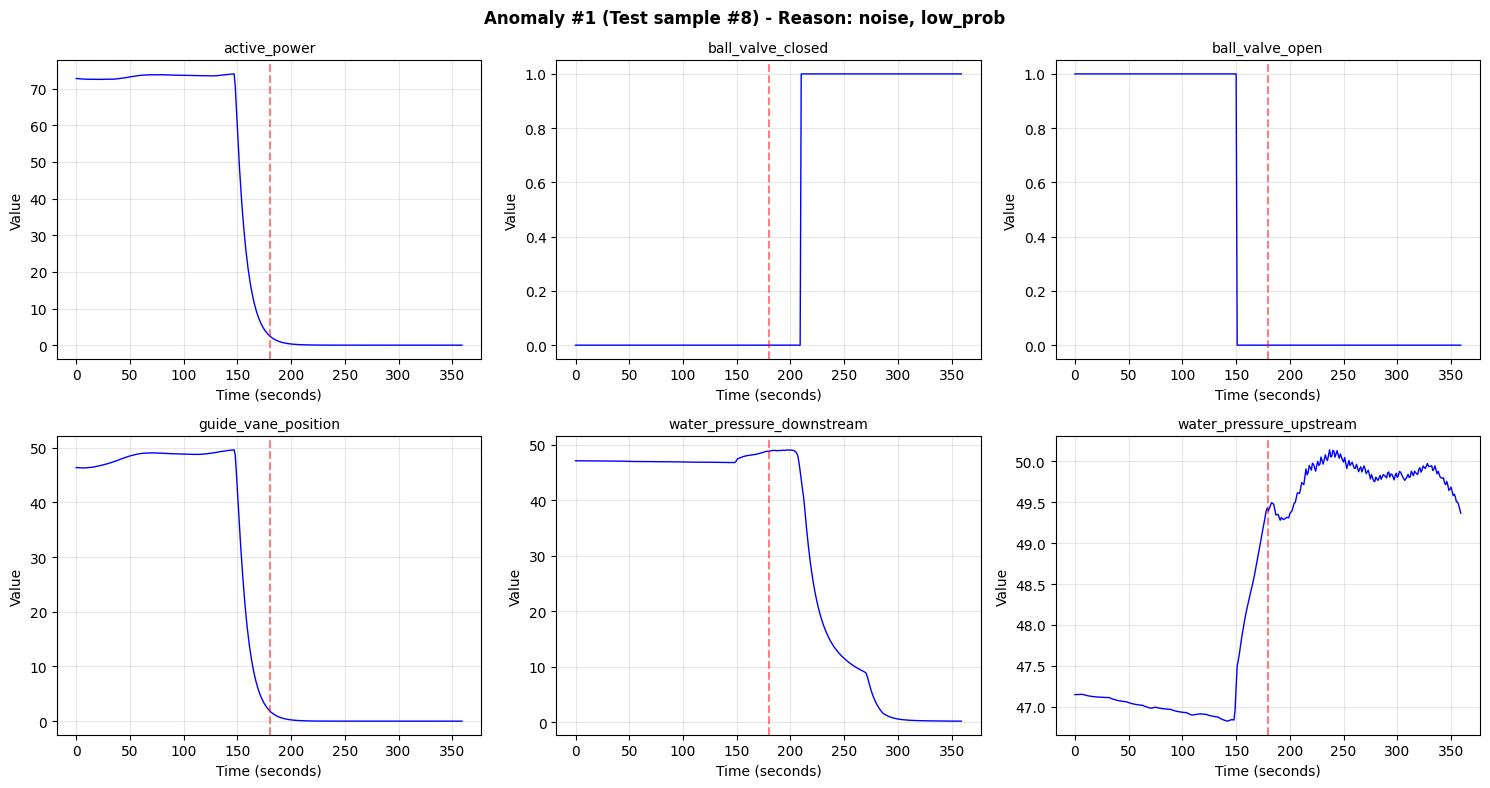

  Window 1: Test sample index 8, Reason: noise, low_prob



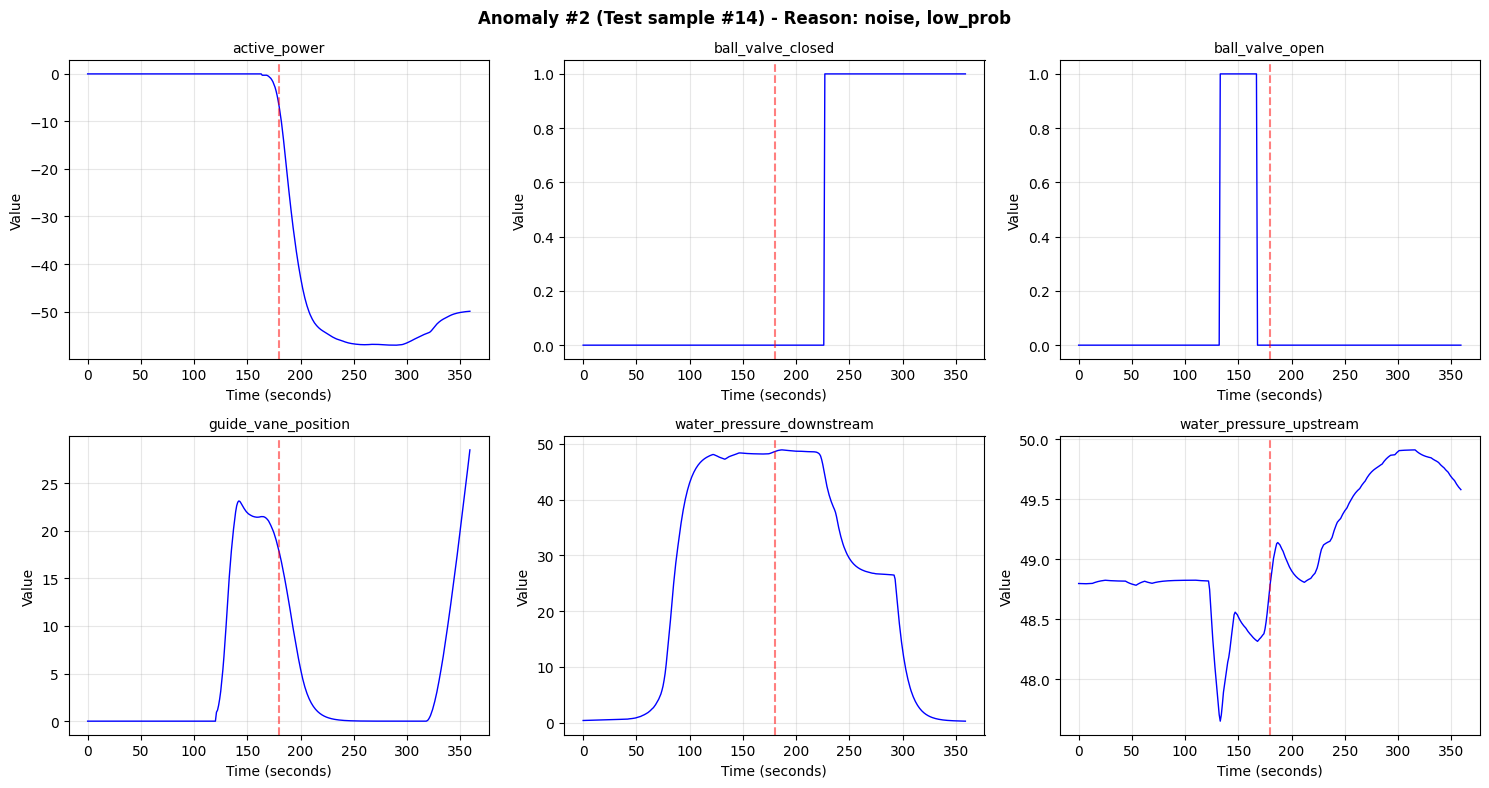

  Window 2: Test sample index 14, Reason: noise, low_prob



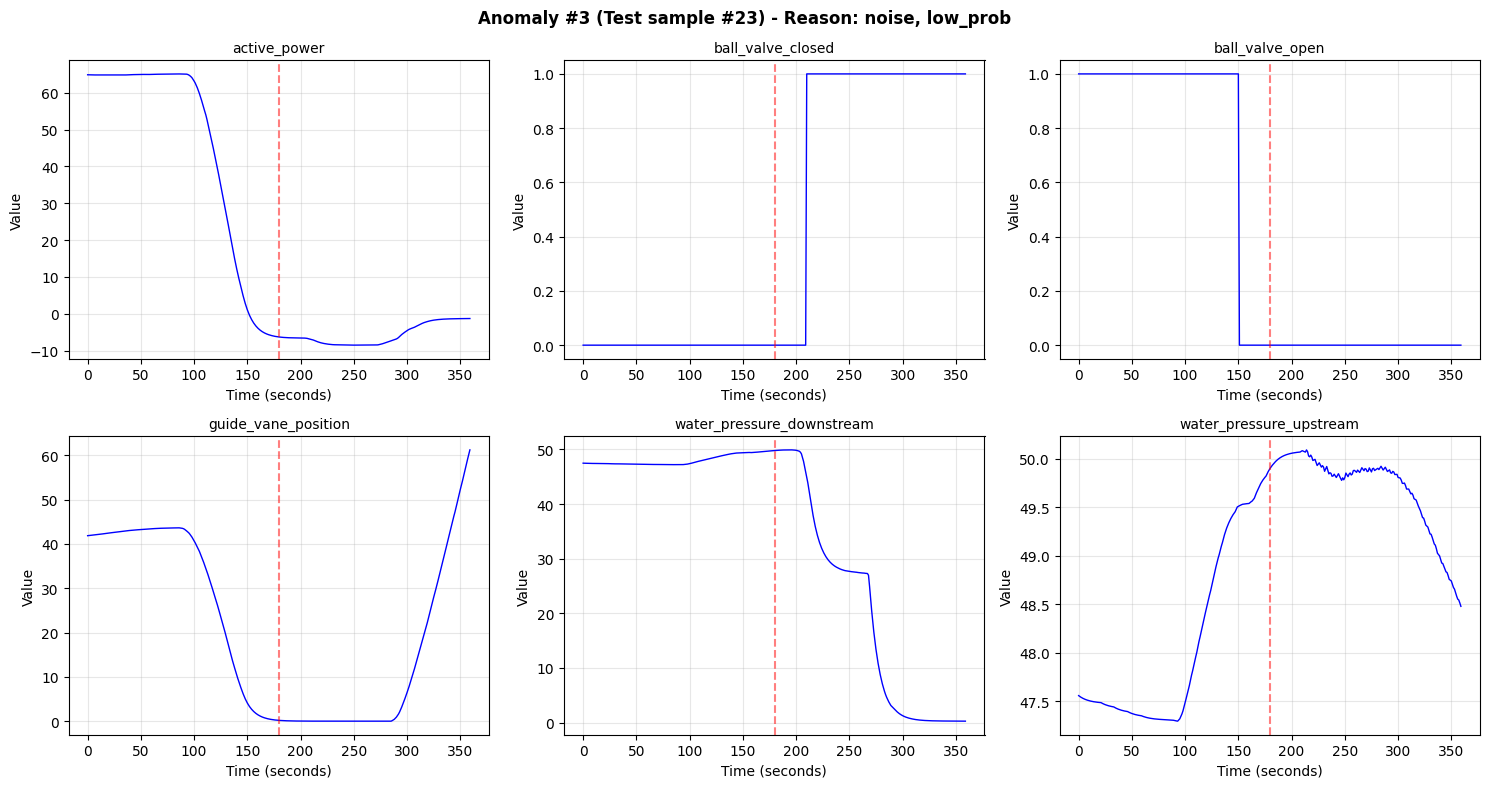

  Window 3: Test sample index 23, Reason: noise, low_prob



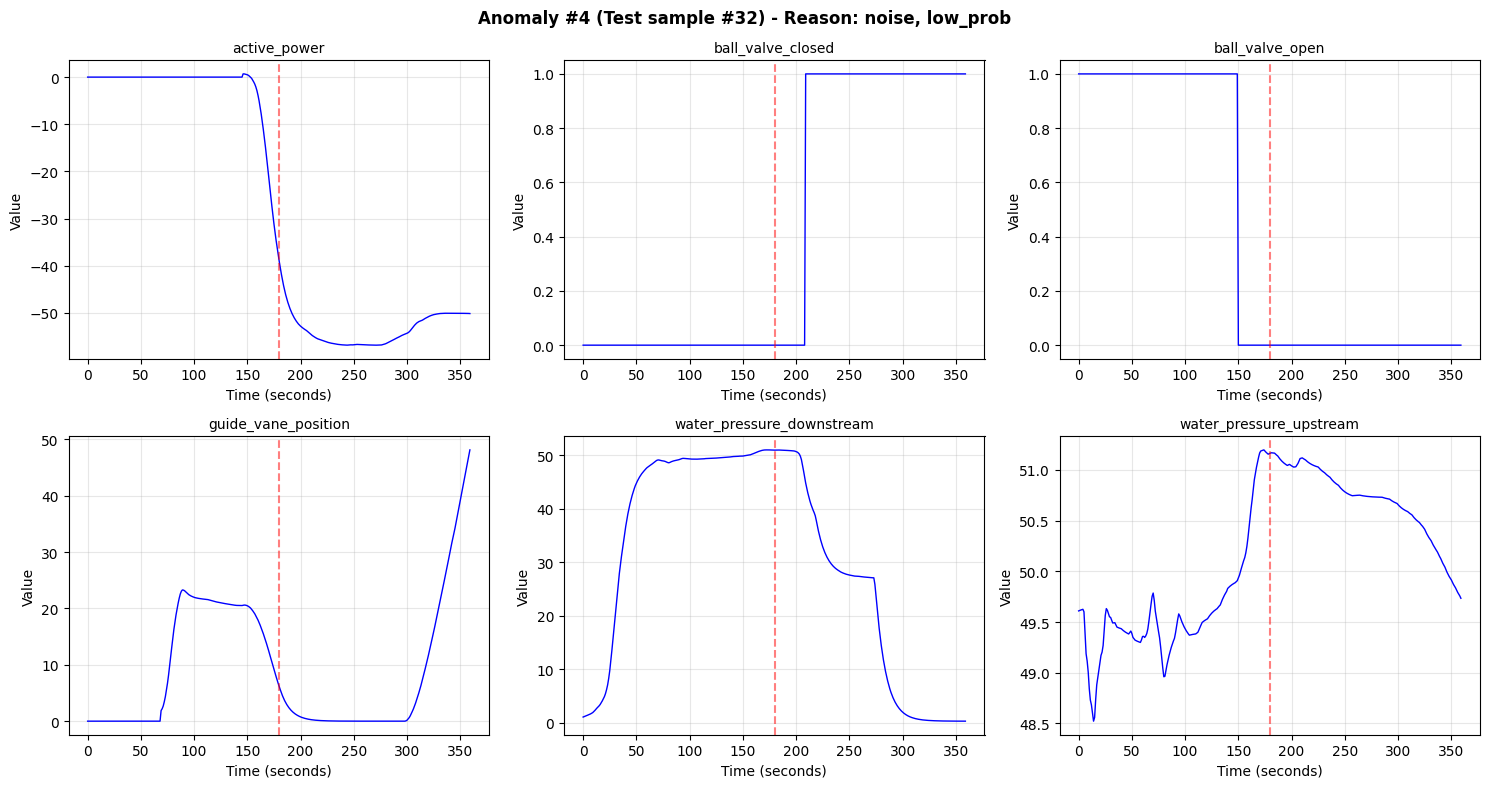

  Window 4: Test sample index 32, Reason: noise, low_prob



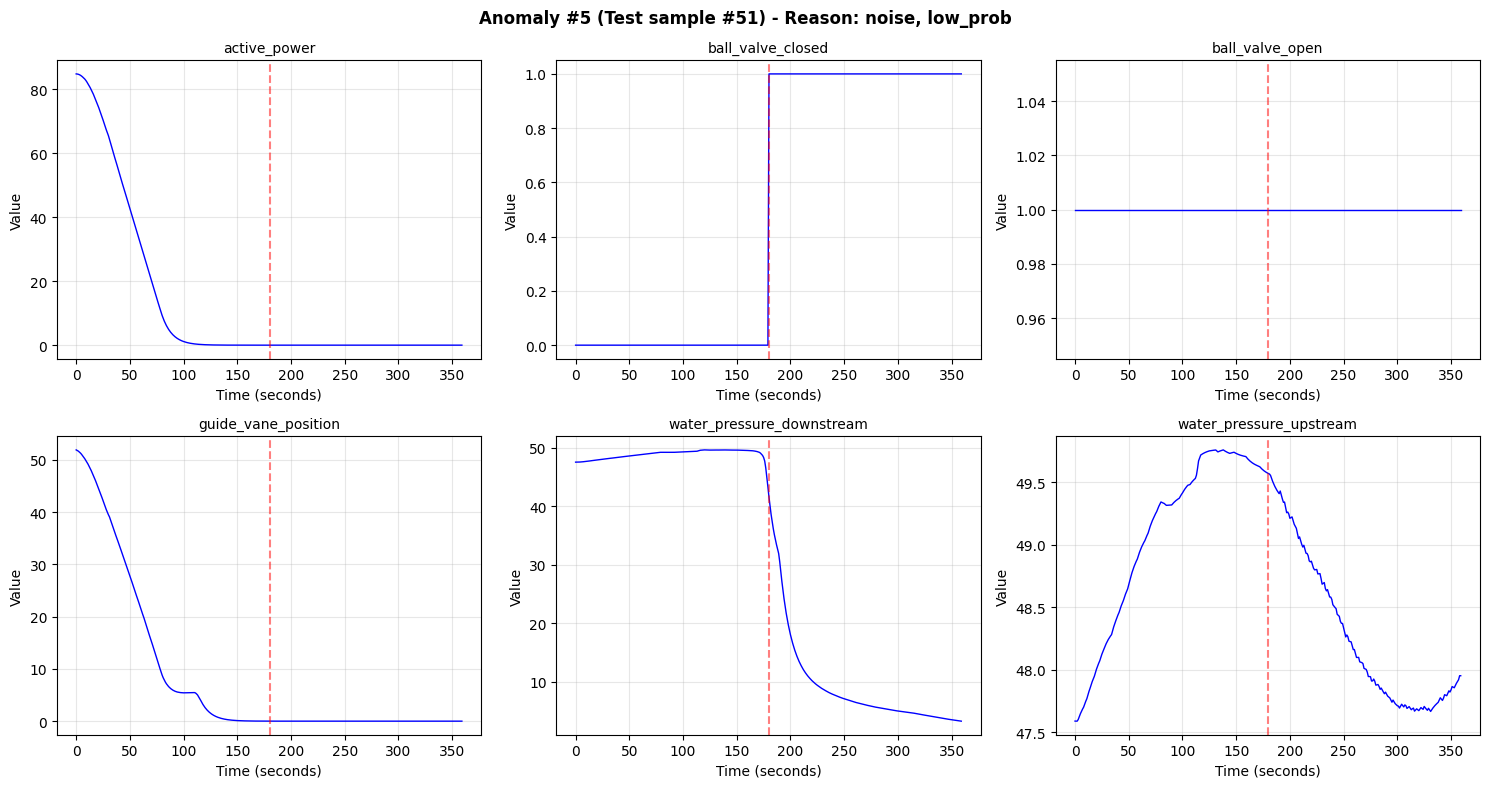

  Window 5: Test sample index 51, Reason: noise, low_prob



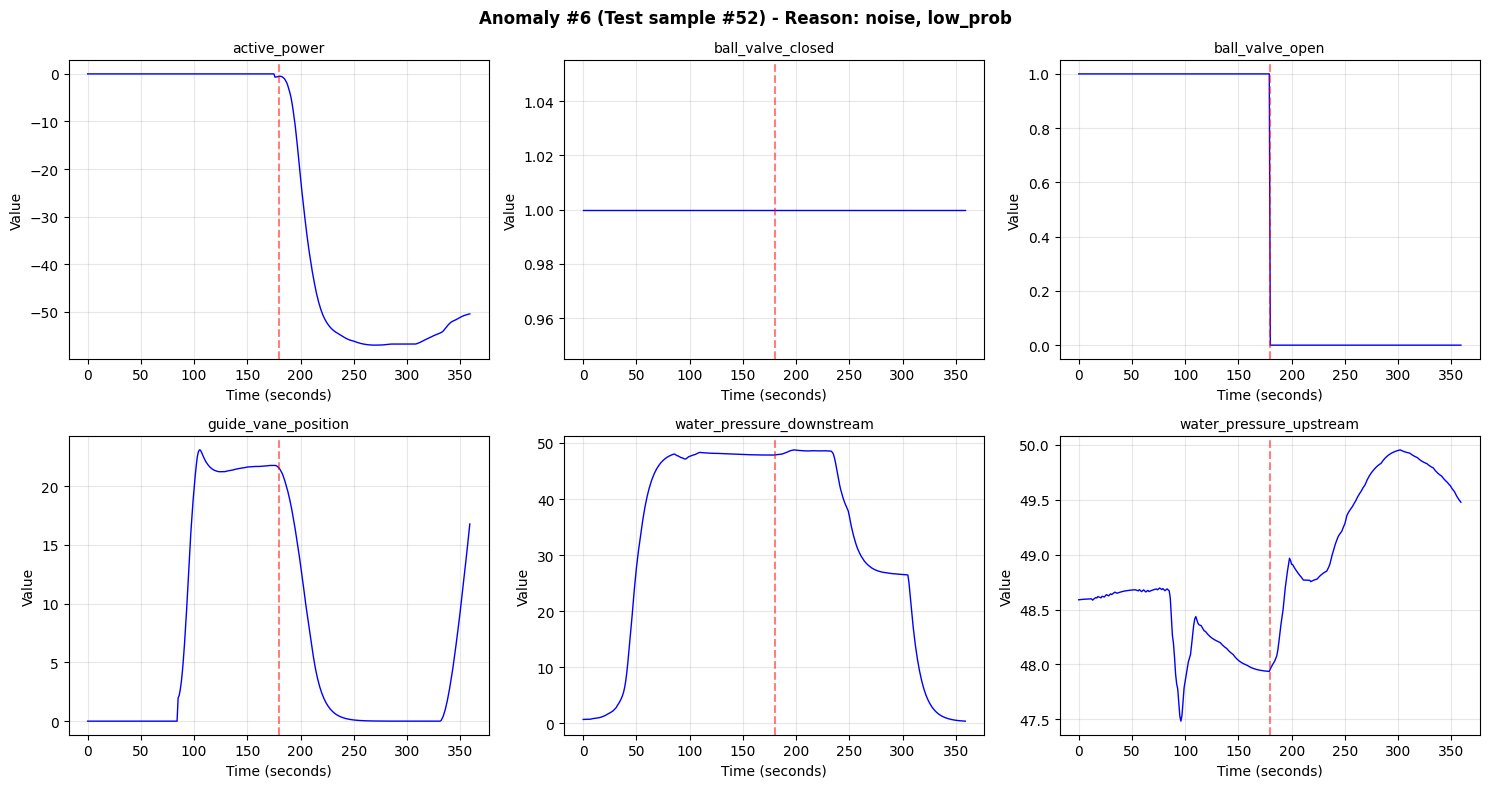

  Window 6: Test sample index 52, Reason: noise, low_prob



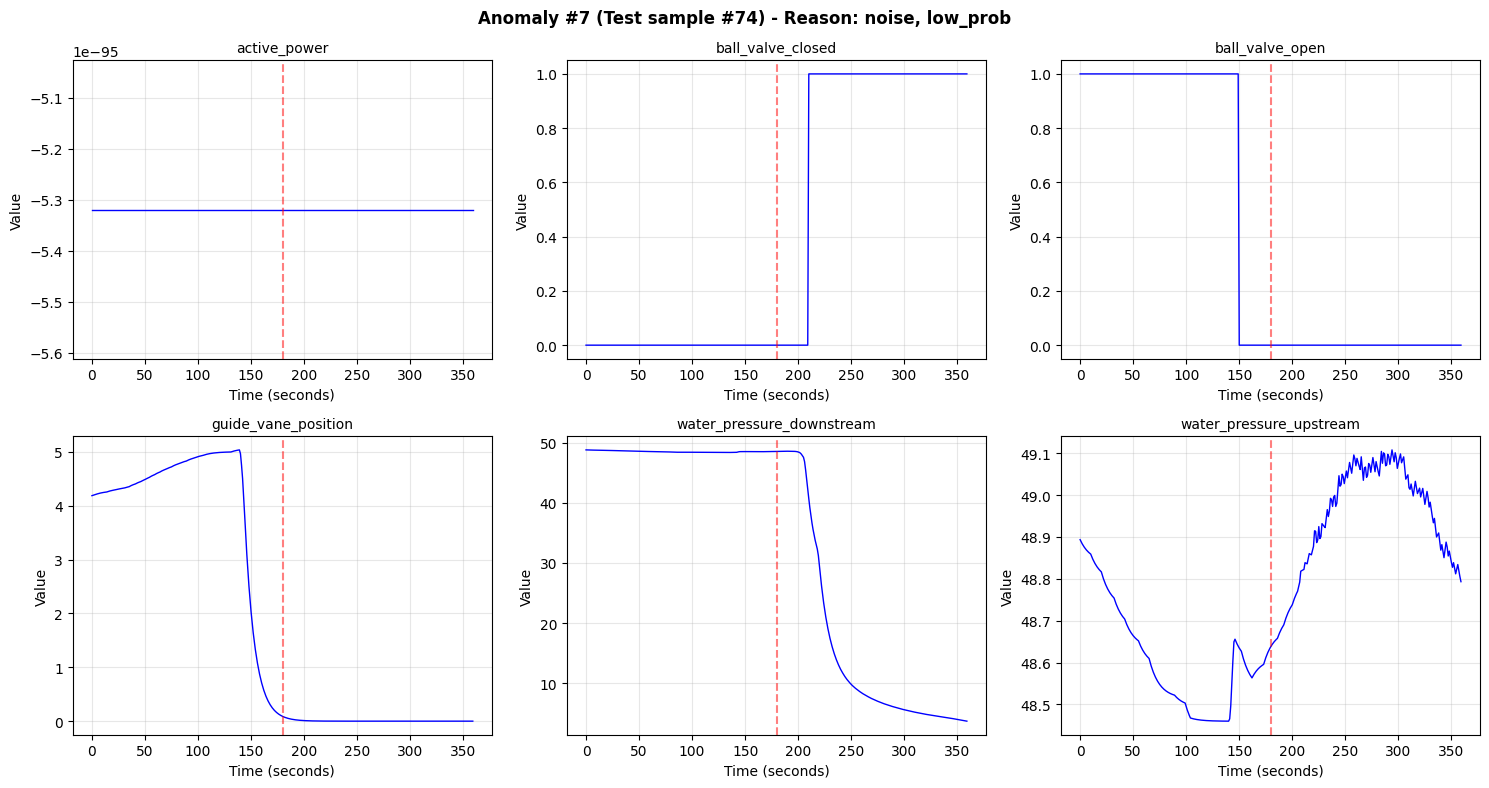

  Window 7: Test sample index 74, Reason: noise, low_prob



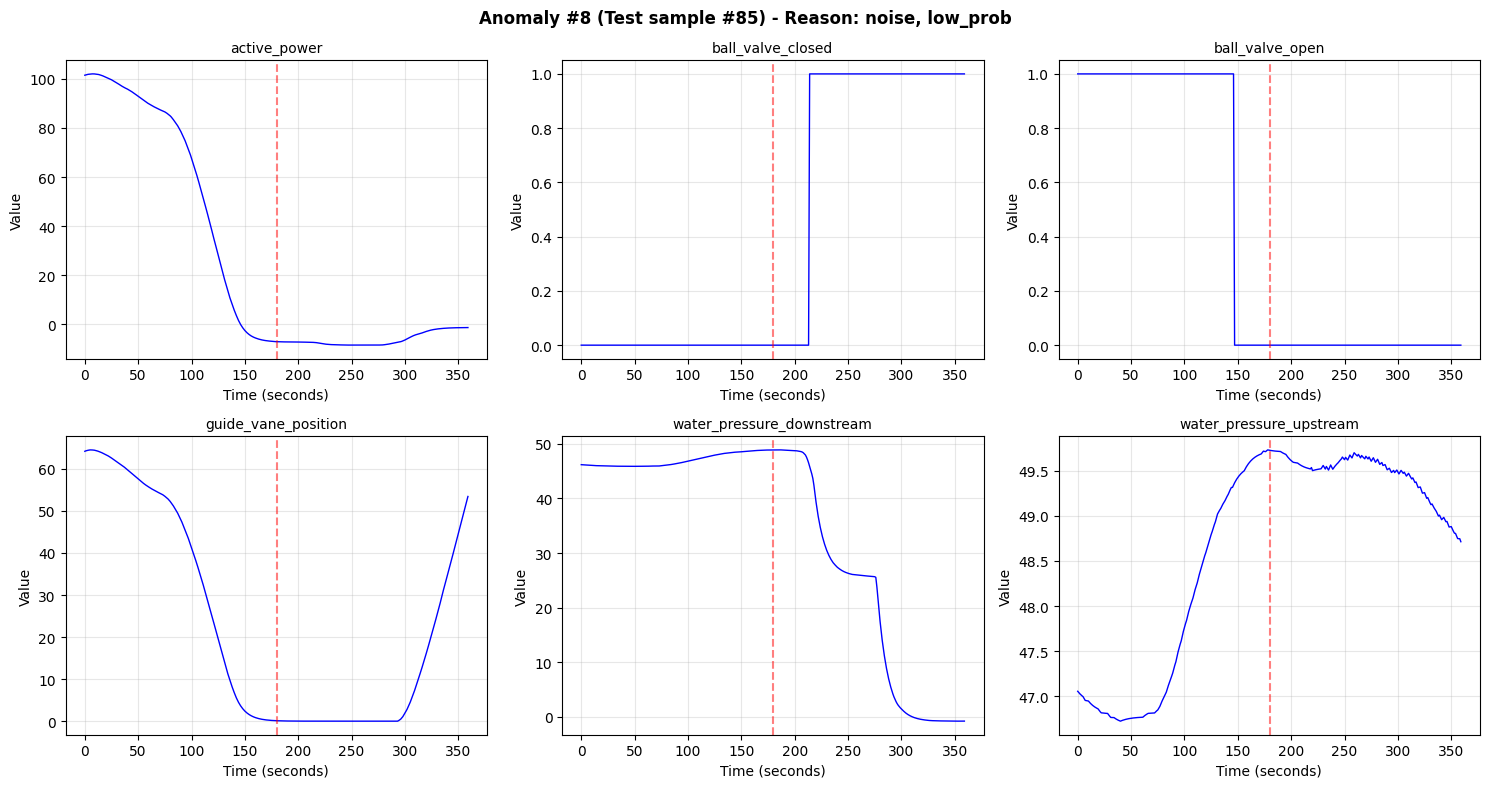

  Window 8: Test sample index 85, Reason: noise, low_prob



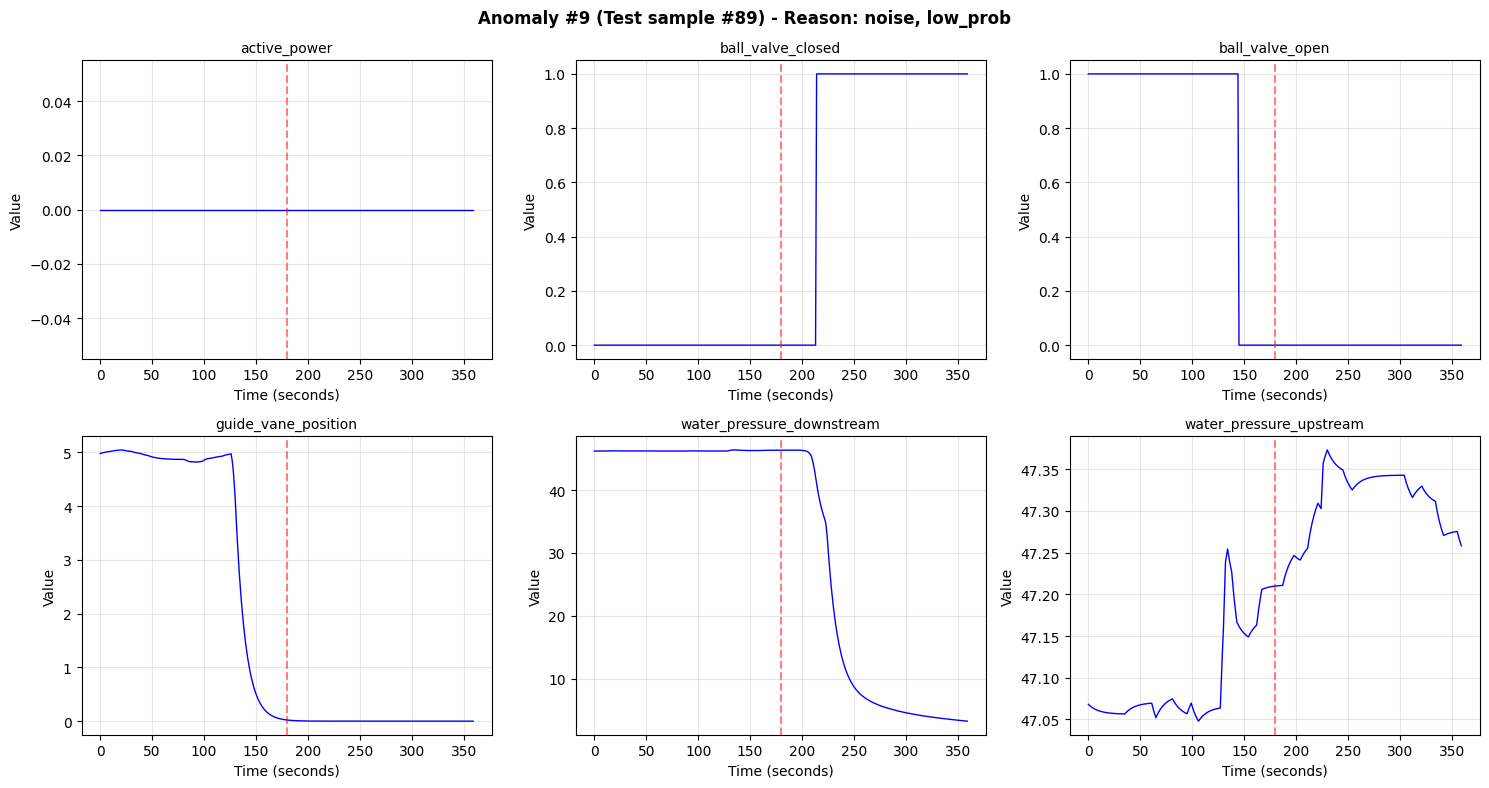

  Window 9: Test sample index 89, Reason: noise, low_prob



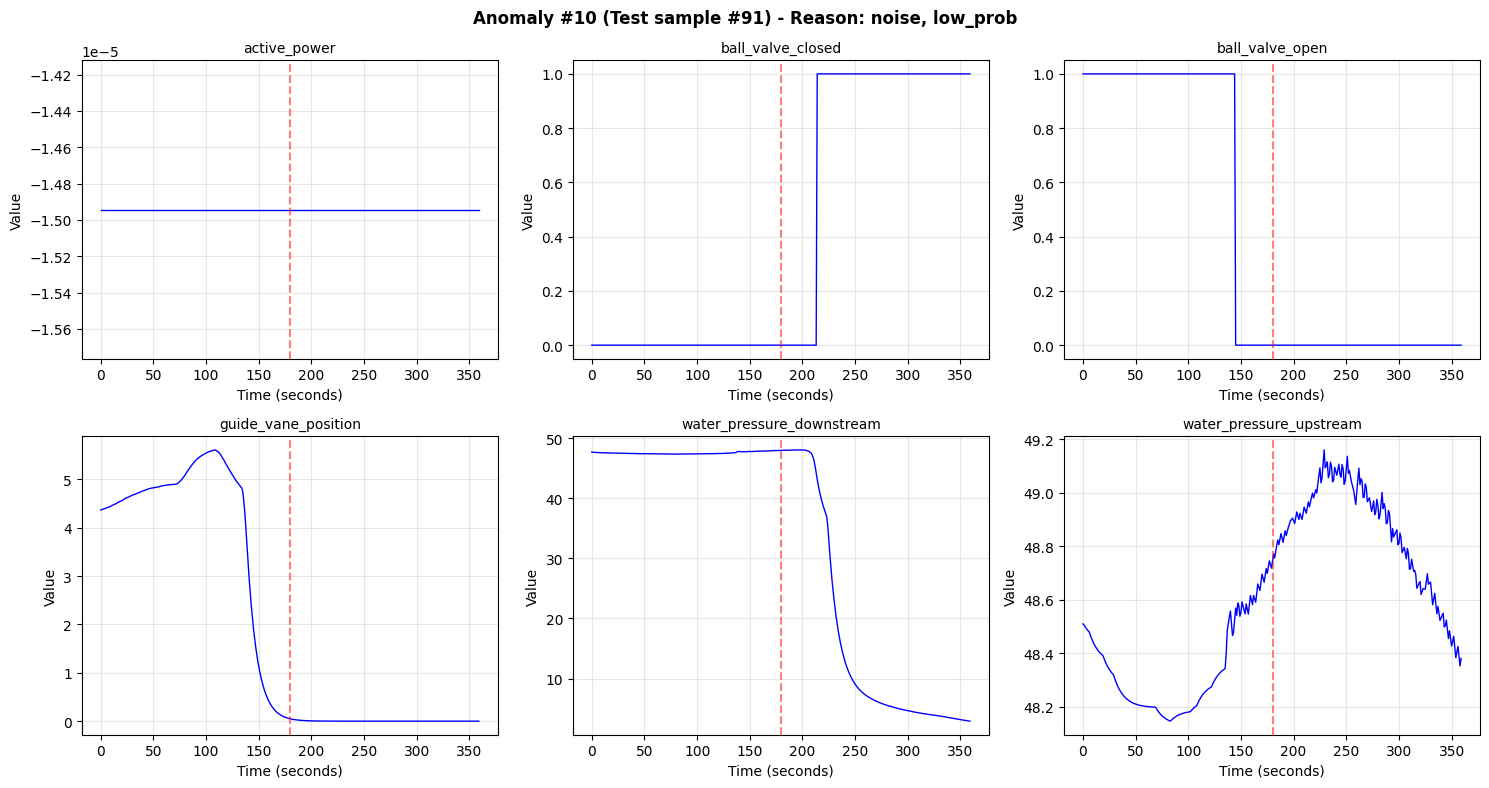

  Window 10: Test sample index 91, Reason: noise, low_prob


2. Normal vs Anomaly Comparison (per signal):


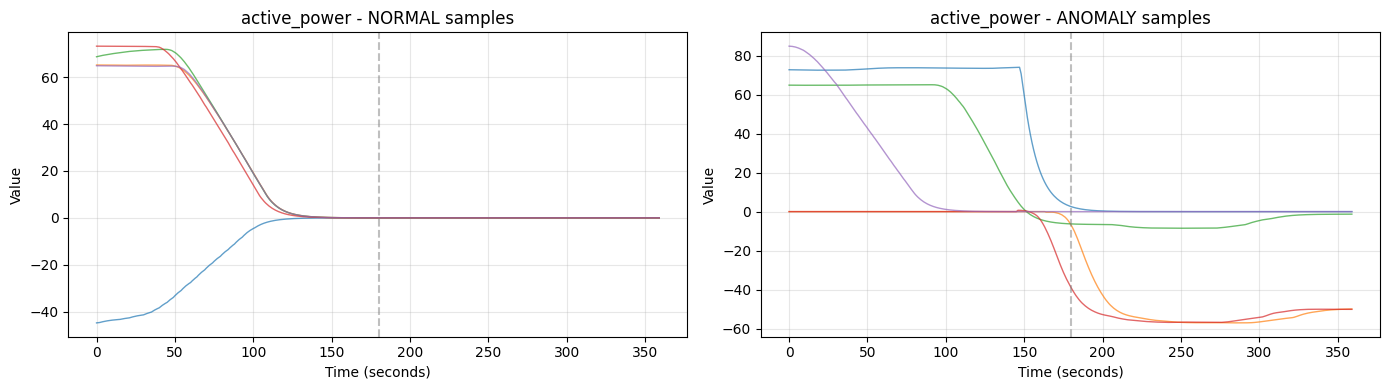

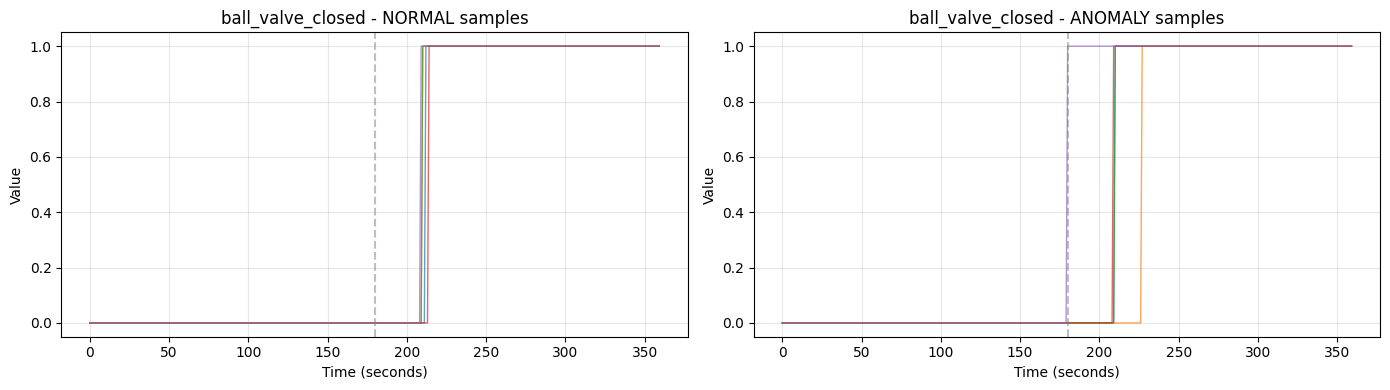

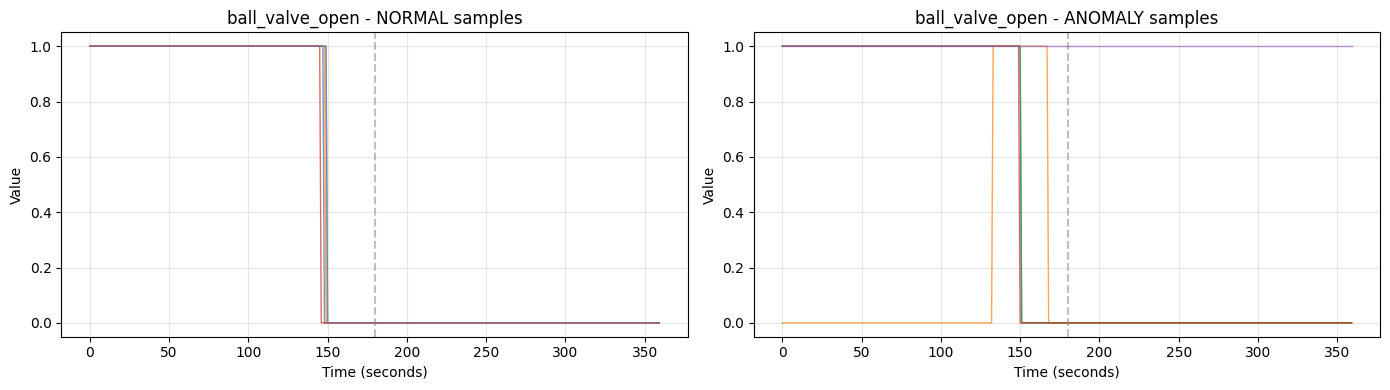

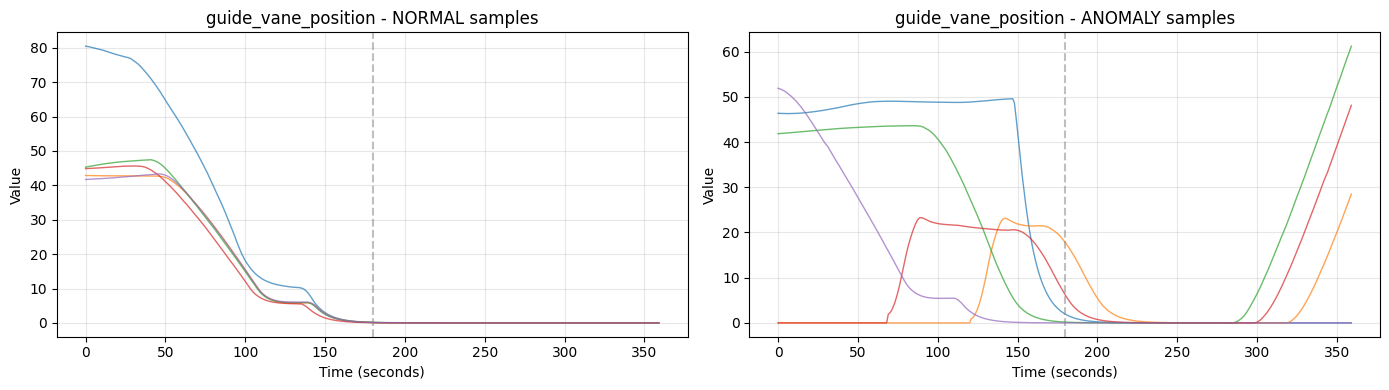

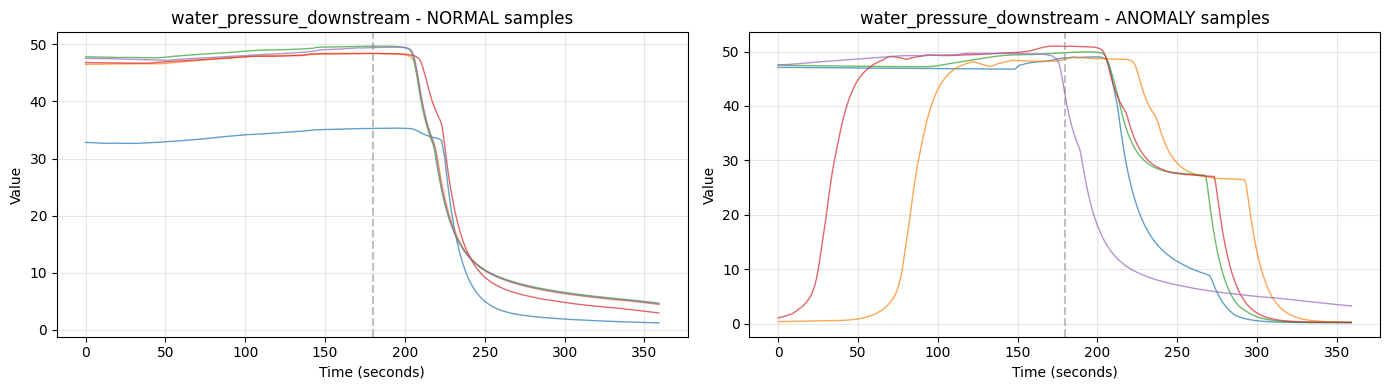

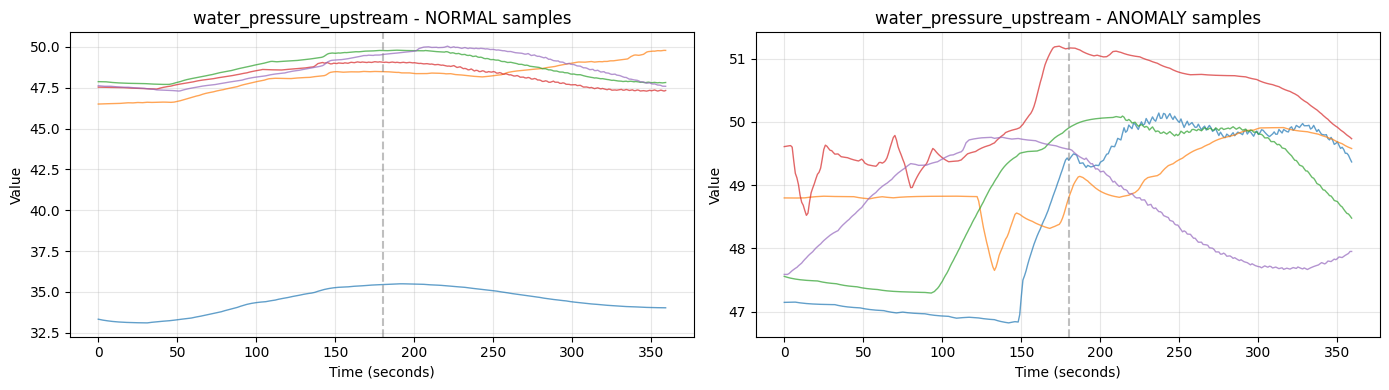

In [ ]:
# ----------------------------------------------------------------------
# PLOT ANOMALOUS WINDOWS WITH RECONSTRUCTION
# Visualize original, reconstructed, and error for anomalies
# ----------------------------------------------------------------------

def plot_anomalous_windows_with_reconstruction(X_test, flags, signals, model, scaler, max_plots=10):
    """
    Plot anomalous windows showing: Original, Reconstructed, and Error.
    
    Parameters:
    - X_test: Flattened test windows (N, 2160) where 2160 = 6 signals × 360 timesteps
    - flags: Dictionary containing 'is_anomaly' boolean array and 'reasons' list
    - signals: List of signal names
    - model: Trained autoencoder model
    - scaler: StandardScaler used during training
    - max_plots: Maximum number of anomalous windows to plot
    """
    import torch
    
    is_anomaly = flags['is_anomaly']
    reasons = flags['reasons']
    anomaly_indices = np.where(is_anomaly)[0]
    
    n_anomalies = len(anomaly_indices)
    print(f"Total anomalies detected: {n_anomalies}")
    
    if n_anomalies == 0:
        print("No anomalies to plot!")
        return
    
    # Limit plots
    n_to_plot = min(max_plots, n_anomalies)
    print(f"Plotting {n_to_plot} anomalous windows with reconstruction...")
    
    n_signals = len(signals)
    n_timesteps = X_test.shape[1] // n_signals  # 360
    time_axis = np.arange(n_timesteps)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Get reconstructions for anomalous windows
    anomaly_windows = X_test[anomaly_indices[:n_to_plot]]
    anomaly_windows_scaled = scaler.transform(anomaly_windows)
    
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(anomaly_windows_scaled).to(device)
        reconstructed_scaled, _ = model(X_tensor)
        reconstructed_scaled = reconstructed_scaled.cpu().numpy()
    
    # Inverse transform to original scale
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    
    for plot_idx, (anom_idx, orig_window, recon_window) in enumerate(
            zip(anomaly_indices[:n_to_plot], anomaly_windows, reconstructed)):
        
        # Unflatten: (2160,) -> (360, 6)
        orig = orig_window.reshape(n_timesteps, n_signals)
        recon = recon_window.reshape(n_timesteps, n_signals)
        error = orig - recon
        
        # Get reason for this anomaly
        reason = reasons[anom_idx]
        reason_str = ', '.join(reason) if reason else 'unknown'
        
        # Compute MSE for this window
        mse = np.mean((orig_window - recon_window)**2)
        
        # Create figure: 3 rows (Original, Reconstructed, Error) × 6 columns (signals)
        fig, axes = plt.subplots(3, 6, figsize=(20, 10))
        
        for i, sig in enumerate(signals):
            # Original
            ax = axes[0, i]
            ax.plot(time_axis, orig[:, i], 'b-', linewidth=1, label='Original')
            ax.set_title(f'{sig}', fontsize=10)
            if i == 0:
                ax.set_ylabel('Original', fontsize=10, fontweight='bold')
            ax.axvline(x=n_timesteps//2, color='red', linestyle='--', alpha=0.5)
            ax.grid(True, alpha=0.3)
            
            # Reconstructed
            ax = axes[1, i]
            ax.plot(time_axis, recon[:, i], 'g-', linewidth=1, label='Reconstructed')
            if i == 0:
                ax.set_ylabel('Reconstructed', fontsize=10, fontweight='bold')
            ax.axvline(x=n_timesteps//2, color='red', linestyle='--', alpha=0.5)
            ax.grid(True, alpha=0.3)
            
            # Error (Original - Reconstructed)
            ax = axes[2, i]
            ax.plot(time_axis, error[:, i], 'r-', linewidth=1, label='Error')
            ax.fill_between(time_axis, 0, error[:, i], alpha=0.3, color='red')
            if i == 0:
                ax.set_ylabel('Error', fontsize=10, fontweight='bold')
            ax.set_xlabel('Time (s)')
            ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
            ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'Anomaly #{plot_idx + 1} (Sample #{anom_idx}) | MSE: {mse:.4f} | Reason: {reason_str}', 
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f"  Window {plot_idx + 1}: Sample {anom_idx}, MSE={mse:.4f}, Reason: {reason_str}")
        print()


def plot_anomaly_comparison_with_reconstruction(X_test, flags, signals, model, scaler, n_normal=3, n_anomaly=3):
    """
    Compare reconstruction errors: Normal vs Anomalous windows.
    Shows Original, Reconstructed, and highlights where errors are highest.
    """
    import torch
    
    is_anomaly = flags['is_anomaly']
    
    normal_indices = np.where(~is_anomaly)[0]
    anomaly_indices = np.where(is_anomaly)[0]
    
    n_signals = len(signals)
    n_timesteps = X_test.shape[1] // n_signals
    time_axis = np.arange(n_timesteps)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Select random samples
    n_normal_plot = min(n_normal, len(normal_indices))
    n_anomaly_plot = min(n_anomaly, len(anomaly_indices))
    
    if n_normal_plot == 0 or n_anomaly_plot == 0:
        print("Not enough samples for comparison!")
        return
    
    normal_samples = np.random.choice(normal_indices, n_normal_plot, replace=False)
    anomaly_samples = anomaly_indices[:n_anomaly_plot]
    
    # Get reconstructions for selected windows
    selected_indices = np.concatenate([normal_samples, anomaly_samples])
    selected_windows = X_test[selected_indices]
    selected_scaled = scaler.transform(selected_windows)
    
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(selected_scaled).to(device)
        reconstructed_scaled, _ = model(X_tensor)
        reconstructed_scaled = reconstructed_scaled.cpu().numpy()
    
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    
    # Split back
    normal_orig = selected_windows[:n_normal_plot]
    normal_recon = reconstructed[:n_normal_plot]
    anomaly_orig = selected_windows[n_normal_plot:]
    anomaly_recon = reconstructed[n_normal_plot:]
    
    for sig_idx, sig in enumerate(signals):
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        # --- NORMAL SAMPLES ---
        # Original
        ax = axes[0, 0]
        for i, orig in enumerate(normal_orig):
            window = orig.reshape(n_timesteps, n_signals)
            ax.plot(time_axis, window[:, sig_idx], alpha=0.7, linewidth=1)
        ax.set_title(f'NORMAL - Original')
        ax.set_ylabel(sig, fontsize=10, fontweight='bold')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Reconstructed
        ax = axes[0, 1]
        for i, recon in enumerate(normal_recon):
            window = recon.reshape(n_timesteps, n_signals)
            ax.plot(time_axis, window[:, sig_idx], alpha=0.7, linewidth=1)
        ax.set_title(f'NORMAL - Reconstructed')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Error
        ax = axes[0, 2]
        for orig, recon in zip(normal_orig, normal_recon):
            orig_w = orig.reshape(n_timesteps, n_signals)
            recon_w = recon.reshape(n_timesteps, n_signals)
            error = np.abs(orig_w[:, sig_idx] - recon_w[:, sig_idx])
            ax.plot(time_axis, error, alpha=0.7, linewidth=1)
        ax.set_title(f'NORMAL - |Error|')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # --- ANOMALY SAMPLES ---
        # Original
        ax = axes[1, 0]
        for i, orig in enumerate(anomaly_orig):
            window = orig.reshape(n_timesteps, n_signals)
            ax.plot(time_axis, window[:, sig_idx], alpha=0.7, linewidth=1)
        ax.set_title(f'ANOMALY - Original')
        ax.set_ylabel(sig, fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Reconstructed
        ax = axes[1, 1]
        for i, recon in enumerate(anomaly_recon):
            window = recon.reshape(n_timesteps, n_signals)
            ax.plot(time_axis, window[:, sig_idx], alpha=0.7, linewidth=1)
        ax.set_title(f'ANOMALY - Reconstructed')
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Error
        ax = axes[1, 2]
        for orig, recon in zip(anomaly_orig, anomaly_recon):
            orig_w = orig.reshape(n_timesteps, n_signals)
            recon_w = recon.reshape(n_timesteps, n_signals)
            error = np.abs(orig_w[:, sig_idx] - recon_w[:, sig_idx])
            ax.plot(time_axis, error, alpha=0.7, linewidth=1, color='red')
        ax.set_title(f'ANOMALY - |Error|')
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'Signal: {sig} - Normal vs Anomaly Reconstruction', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


def plot_single_window_reconstruction(X_test, idx, signals, model, scaler, title="Window"):
    """
    Plot a single window with its reconstruction.
    Shows Original (blue), Reconstructed (green), and shaded Error.
    """
    import torch
    
    n_signals = len(signals)
    n_timesteps = X_test.shape[1] // n_signals
    time_axis = np.arange(n_timesteps)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Get reconstruction
    window = X_test[idx:idx+1]
    window_scaled = scaler.transform(window)
    
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(window_scaled).to(device)
        reconstructed_scaled, latent = model(X_tensor)
        reconstructed_scaled = reconstructed_scaled.cpu().numpy()
    
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    
    # Unflatten
    orig = window[0].reshape(n_timesteps, n_signals)
    recon = reconstructed[0].reshape(n_timesteps, n_signals)
    
    # Compute MSE
    mse = np.mean((window[0] - reconstructed[0])**2)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, sig in enumerate(signals):
        ax = axes[i]
        ax.plot(time_axis, orig[:, i], 'b-', linewidth=1.5, label='Original', alpha=0.8)
        ax.plot(time_axis, recon[:, i], 'g--', linewidth=1.5, label='Reconstructed', alpha=0.8)
        ax.fill_between(time_axis, orig[:, i], recon[:, i], alpha=0.3, color='red', label='Error')
        ax.set_title(sig, fontsize=10)
        ax.set_xlabel('Time (s)')
        ax.axvline(x=n_timesteps//2, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize='small')
    
    plt.suptitle(f'{title} (Sample #{idx}) | MSE: {mse:.6f}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return mse, latent.cpu().numpy()


# ==============================================================================
# RUN VISUALIZATION
# ==============================================================================
print("="*60)
print("PLOTTING ANOMALOUS WINDOWS WITH RECONSTRUCTION")
print("="*60)

# Plot individual anomalous windows with reconstruction (up to 5)
print("\n1. Individual Anomalous Windows (Original vs Reconstructed):")
plot_anomalous_windows_with_reconstruction(
    X_test_combined, flags_combined, SIGNALS, 
    model_combined, scaler_combined, max_plots=5
)

# Compare normal vs anomaly
print("\n2. Normal vs Anomaly Comparison with Reconstruction (per signal):")
plot_anomaly_comparison_with_reconstruction(
    X_test_combined, flags_combined, SIGNALS, 
    model_combined, scaler_combined, n_normal=3, n_anomaly=3
)

print("\n3. Single Window Deep Dive (best and worst reconstruction):")
# Find best and worst reconstruction errors
X_test_scaled = scaler_combined.transform(X_test_combined)
model_combined.eval()
with torch.no_grad():
    recon_scaled, _ = model_combined(torch.FloatTensor(X_test_scaled).to('cuda' if torch.cuda.is_available() else 'cpu'))
    recon_scaled = recon_scaled.cpu().numpy()
mse_all = np.mean((X_test_scaled - recon_scaled)**2, axis=1)

# Best reconstruction (lowest MSE)
best_idx = np.argmin(mse_all)
print(f"\nBest reconstructed window (lowest MSE):")
plot_single_window_reconstruction(X_test_combined, best_idx, SIGNALS, model_combined, scaler_combined, 
                                   title="Best Reconstruction")

# Worst reconstruction (highest MSE) - likely an anomaly
worst_idx = np.argmax(mse_all)
print(f"\nWorst reconstructed window (highest MSE):")
plot_single_window_reconstruction(X_test_combined, worst_idx, SIGNALS, model_combined, scaler_combined,
                                   title="Worst Reconstruction")

In [ ]:
# ==============================================================================
# SYNTHETIC ANOMALY GENERATION FOR AUTOENCODER TESTING
# ==============================================================================
# This cell generates training windows with injected anomalies for testing
# the autoencoder's anomaly detection capabilities.
#
# Key features:
# - Loads training windows WITH asset tracking
# - Injects ~20% anomalies per asset
# - Each anomaly type appears at least once per asset
# - Only modifies: active_power, guide_vane_position, water_pressure_downstream/upstream
# - Does NOT touch: ball_valve_open, ball_valve_closed
# - Stores in 'anomalies_added' folder for later testing
# ==============================================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Import anomaly injection functions (reload to get latest changes)
import importlib
import generate_anomalies_template
importlib.reload(generate_anomalies_template)

from generate_anomalies_template import (
    inject_closing_spikes,
    inject_closing_level_shift,
    inject_closing_linear_drift,
    inject_closing_variance_change,
    inject_closing_time_warp
)

# ==============================================================================
# CONFIGURATION
# ==============================================================================
TRANSITIONS_DIR = 'data_transitions'
OUTPUT_DIR = 'anomalies_added'
os.makedirs(OUTPUT_DIR, exist_ok=True)

HALF_WINDOW = 180
ANOMALY_RATIO = 0.20  # 20% of windows will have anomalies

# Signals we CAN inject anomalies into (excluding ball_valve_*)
INJECTABLE_SIGNALS = ['active_power', 'guide_vane_position', 
                      'water_pressure_downstream', 'water_pressure_upstream']

# All signals (for window extraction)
ALL_SIGNALS = ['active_power', 'ball_valve_closed', 'ball_valve_open',
               'guide_vane_position', 'water_pressure_downstream', 'water_pressure_upstream']

# Signal index mapping (for combined windows of shape 2160 = 6 signals x 360)
SIGNAL_INDICES = {sig: i for i, sig in enumerate(ALL_SIGNALS)}

# ==============================================================================
# ANOMALY TYPE → SIGNAL MAPPING (Initial Assignment)
# ==============================================================================
# Each anomaly type is assigned to a specific signal. Can be changed later.
ANOMALY_SIGNAL_MAP = {
    'spikes': 'active_power',
    'level_shift': 'guide_vane_position',
    'linear_drift': 'water_pressure_downstream',
    'variance_change': 'water_pressure_upstream',
    'time_warp': 'active_power'  # Second anomaly type for active_power
}

# Anomaly function configurations
# transition_center=200 centers anomalies near the transition moment (index 180)
# spread=25 controls how spread out the placement is (smaller = more centered)
# Each anomaly type injects ONE SINGLE INSTANCE of the anomaly
ANOMALY_CONFIGS = {
    'spikes': {
        'func': inject_closing_spikes,
        'params': {'n_spikes': 1, 'magnitude_range': (3.0, 5.0),  # Single spike point
                   'transition_center': 200, 'spread': 25}
    },
    'level_shift': {
        'func': inject_closing_level_shift,
        'params': {'segment_length': 50, 'shift_factor': 2.5,
                   'transition_center': 210, 'spread': 20}
    },
    'linear_drift': {
        'func': inject_closing_linear_drift,
        'params': {'segment_length': 60, 'drift_std_factors': (1.5, 3.0),
                   'transition_center': 210, 'spread': 20}
    },
    'variance_change': {
        'func': inject_closing_variance_change,
        'params': {'segment_length': 40, 'variance_factor_range': (2.0, 4.0),
                   'transition_center': 200, 'spread': 25}
    },
    'time_warp': {
        'func': inject_closing_time_warp,
        'params': {'segment_length': 50, 'warp_factor_range': (0.5, 0.8),
                   'transition_center': 200, 'spread': 20}
    }
}

# ==============================================================================
# HELPER: Load Windows WITH Asset Tracking
# ==============================================================================
def load_windows_with_asset_tracking(split='training'):
    """
    Load combined windows (shape: N x 2160) with asset metadata.
    
    Returns:
        windows: np.ndarray of shape (N, 2160)
        asset_labels: list of asset names for each window
        window_indices: list of (asset, local_idx) tuples
    """
    windows = []
    asset_labels = []
    window_indices = []
    
    files = sorted([f for f in os.listdir(TRANSITIONS_DIR) 
                    if f.endswith('_processed.pkl') and split in f])
    
    print(f"Found {len(files)} {split} files")
    
    for f in tqdm(files, desc=f"Loading {split} windows"):
        base = f.replace('_processed.pkl', '')
        asset_name = base.replace('_real_measurements', '')
        
        processed_path = os.path.join(TRANSITIONS_DIR, f)
        transitions_path = os.path.join(TRANSITIONS_DIR, f"{base}_transitions.pkl")
        
        if not os.path.exists(transitions_path):
            continue
            
        # Load data
        df = pd.read_pickle(processed_path)
        df = df.reindex(columns=ALL_SIGNALS)
        df = df.fillna(method='ffill').fillna(method='bfill').fillna(0)
        
        df_trans = pd.read_pickle(transitions_path)
        if df_trans.empty:
            continue
        
        # Group transitions within 180s
        df_trans = df_trans.sort_values('timestamp')
        grouped_events = []
        current_group = [df_trans.iloc[0]]
        
        for i in range(1, len(df_trans)):
            curr = df_trans.iloc[i]
            prev = current_group[-1]
            diff = (curr['timestamp'] - prev['timestamp']).total_seconds()
            if diff < 180:
                current_group.append(curr)
            else:
                grouped_events.append(current_group)
                current_group = [curr]
        grouped_events.append(current_group)
        
        # Filter for CLOSING transitions only
        def is_closing(group):
            votes_opening, votes_closing = 0, 0
            for row in group:
                sig, v_from, v_to = row['signal'], row['from_value'], row['to_value']
                if sig == 'ball_valve_open':
                    if v_from == 0 and v_to == 1: votes_opening += 1
                    elif v_from == 1 and v_to == 0: votes_closing += 1
                elif sig == 'ball_valve_closed':
                    if v_from == 0 and v_to == 1: votes_closing += 1
                    elif v_from == 1 and v_to == 0: votes_opening += 1
            return votes_closing > votes_opening
        
        local_idx = 0
        for group in grouped_events:
            if not is_closing(group):
                continue
                
            min_ts = group[0]['timestamp']
            max_ts = group[-1]['timestamp']
            center_ts = (min_ts + (max_ts - min_ts) / 2).round('1s')
            
            try:
                idx = df.index.searchsorted(center_ts)
                if idx == 0:
                    center_idx = 0
                elif idx == len(df):
                    center_idx = len(df) - 1
                else:
                    ts_prev, ts_curr = df.index[idx-1], df.index[idx]
                    center_idx = idx if abs((ts_curr - center_ts).total_seconds()) < abs((ts_prev - center_ts).total_seconds()) else idx - 1
                
                start_idx = center_idx - HALF_WINDOW
                end_idx = center_idx + HALF_WINDOW
                
                if start_idx < 0 or end_idx > len(df):
                    continue
                
                window_df = df.iloc[start_idx:end_idx][ALL_SIGNALS]
                if window_df.shape[0] == 2 * HALF_WINDOW:
                    # Flatten: (360, 6) → (2160,)
                    windows.append(window_df.values.flatten())
                    asset_labels.append(asset_name)
                    window_indices.append((asset_name, local_idx))
                    local_idx += 1
            except Exception:
                continue
    
    return np.array(windows), asset_labels, window_indices

# ==============================================================================
# HELPER: Extract/Insert Signal Slice from Combined Window
# ==============================================================================
def get_signal_slice(window_combined, signal_name):
    """Extract a single signal (360 points) from combined window (2160 points).
    
    Data is stored in row-major order: [sig0_t0, sig1_t0, ..., sig5_t0, sig0_t1, ...]
    So signal i is at indices [i, i+6, i+12, ...] = every 6th element starting at i.
    """
    idx = SIGNAL_INDICES[signal_name]
    n_signals = len(ALL_SIGNALS)  # 6
    # Reshape to (360 timesteps, 6 signals) and extract column
    reshaped = window_combined.reshape(-1, n_signals)
    return reshaped[:, idx].copy()

def set_signal_slice(window_combined, signal_name, signal_data):
    """Replace a single signal in combined window.
    
    Data is stored in row-major order: [sig0_t0, sig1_t0, ..., sig5_t0, sig0_t1, ...]
    """
    idx = SIGNAL_INDICES[signal_name]
    n_signals = len(ALL_SIGNALS)  # 6
    # Reshape to (360 timesteps, 6 signals), modify column, flatten back
    reshaped = window_combined.reshape(-1, n_signals)
    reshaped[:, idx] = signal_data
    # Note: reshaping creates a view, so the original array is modified

# ==============================================================================
# MAIN: Generate Anomalous Windows
# ==============================================================================
print("="*70)
print("SYNTHETIC ANOMALY GENERATION")
print("="*70)

# 1. Load training windows with asset tracking
print("\n1. Loading training windows with asset tracking...")
X_train, asset_labels, window_indices = load_windows_with_asset_tracking(split='training')
print(f"   Total windows: {len(X_train)}")
print(f"   Shape: {X_train.shape}")

# Count windows per asset
from collections import Counter
asset_counts = Counter(asset_labels)
print("\n   Windows per asset:")
for asset, count in sorted(asset_counts.items()):
    print(f"     {asset}: {count}")

# 2. Determine which windows to inject anomalies into
print(f"\n2. Selecting ~{ANOMALY_RATIO*100:.0f}% of windows for anomaly injection...")

rng = np.random.default_rng(42)  # Reproducible

# For each asset, select windows and assign anomaly types
anomaly_assignments = []  # List of (window_idx, anomaly_type, signal_name)
anomaly_types = list(ANOMALY_CONFIGS.keys())

for asset in sorted(asset_counts.keys()):
    # Get indices for this asset
    asset_window_indices = [i for i, a in enumerate(asset_labels) if a == asset]
    n_windows = len(asset_window_indices)
    n_anomalies = max(len(anomaly_types), int(n_windows * ANOMALY_RATIO))  # At least one of each type
    
    # Randomly select windows
    selected_indices = rng.choice(asset_window_indices, size=min(n_anomalies, n_windows), replace=False)
    
    # Assign anomaly types (cycle through to ensure each type appears at least once)
    for i, win_idx in enumerate(selected_indices):
        anom_type = anomaly_types[i % len(anomaly_types)]
        signal = ANOMALY_SIGNAL_MAP[anom_type]
        anomaly_assignments.append((win_idx, anom_type, signal, asset))

print(f"   Total anomalies to inject: {len(anomaly_assignments)}")

# VERIFICATION: Check that each window appears only ONCE
window_indices_in_assignments = [a[0] for a in anomaly_assignments]
unique_window_indices = set(window_indices_in_assignments)
if len(window_indices_in_assignments) != len(unique_window_indices):
    print(f"   ⚠️ WARNING: Some windows have multiple anomalies!")
    from collections import Counter as C
    duplicates = [idx for idx, count in C(window_indices_in_assignments).items() if count > 1]
    print(f"   Duplicate window indices: {duplicates[:10]}...")  # Show first 10
else:
    print(f"   ✅ VERIFIED: Each window has exactly ONE anomaly (no duplicates)")

# Count by type
type_counts = Counter([a[1] for a in anomaly_assignments])
print("\n   Anomalies by type:")
for atype, count in sorted(type_counts.items()):
    print(f"     {atype}: {count} (→ {ANOMALY_SIGNAL_MAP[atype]})")

# 3. Create anomalous dataset
print("\n3. Injecting anomalies...")

X_anomalous = X_train.copy()
anomaly_metadata = []

for win_idx, anom_type, signal, asset in tqdm(anomaly_assignments, desc="Injecting"):
    # Get the signal slice
    signal_slice = get_signal_slice(X_anomalous[win_idx], signal)
    
    # Get anomaly function and params
    config = ANOMALY_CONFIGS[anom_type]
    func = config['func']
    params = config['params']
    
    # Inject anomaly
    result = func(signal_slice, random_state=win_idx, **params)
    
    # Parse result based on function
    if anom_type == 'spikes':
        signal_modified, spike_indices = result
        extra_info = {'spike_indices': spike_indices.tolist()}
    elif anom_type == 'level_shift':
        signal_modified, (start, end), shift = result
        extra_info = {'segment': (start, end), 'shift': shift}
    elif anom_type == 'linear_drift':
        signal_modified, (start, end), amplitude = result
        extra_info = {'segment': (start, end), 'amplitude': amplitude}
    elif anom_type == 'variance_change':
        signal_modified, (start, end), factor = result
        extra_info = {'segment': (start, end), 'variance_factor': factor}
    elif anom_type == 'time_warp':
        signal_modified, (start, end), warp_factor = result
        extra_info = {'segment': (start, end), 'warp_factor': warp_factor}
    
    # Put modified signal back
    set_signal_slice(X_anomalous[win_idx], signal, signal_modified)
    
    # Store metadata
    anomaly_metadata.append({
        'window_idx': win_idx,
        'asset': asset,
        'anomaly_type': anom_type,
        'signal': signal,
        'signal_idx': SIGNAL_INDICES[signal],
        **extra_info
    })

# 4. Create ground truth labels
print("\n4. Creating ground truth labels...")
is_anomalous = np.zeros(len(X_train), dtype=bool)
anomaly_indices = [a['window_idx'] for a in anomaly_metadata]
is_anomalous[anomaly_indices] = True

print(f"   Normal windows: {np.sum(~is_anomalous)}")
print(f"   Anomalous windows: {np.sum(is_anomalous)}")

# 5. Save everything
print("\n5. Saving to 'anomalies_added' folder...")

save_data = {
    'X_original': X_train,
    'X_anomalous': X_anomalous,
    'is_anomalous': is_anomalous,
    'asset_labels': asset_labels,
    'window_indices': window_indices,
    'anomaly_metadata': anomaly_metadata,
    'signal_names': ALL_SIGNALS,
    'signal_indices': SIGNAL_INDICES,
    'anomaly_signal_map': ANOMALY_SIGNAL_MAP,
    'anomaly_configs': {k: {'params': v['params']} for k, v in ANOMALY_CONFIGS.items()},
    'config': {
        'half_window': HALF_WINDOW,
        'anomaly_ratio': ANOMALY_RATIO,
        'injectable_signals': INJECTABLE_SIGNALS
    }
}

save_path = os.path.join(OUTPUT_DIR, 'anomalous_training_windows.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f"   Saved to: {save_path}")

# Also save metadata as readable CSV
df_meta = pd.DataFrame(anomaly_metadata)
csv_path = os.path.join(OUTPUT_DIR, 'anomaly_metadata.csv')
df_meta.to_csv(csv_path, index=False)
print(f"   Metadata CSV: {csv_path}")

print("\n" + "="*70)
print("ANOMALY GENERATION COMPLETE")
print("="*70)

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
print("\n6. Generating visualizations...")

# --- 6.1 Summary Statistics ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Anomalies by type
ax = axes[0]
types, counts = zip(*sorted(type_counts.items()))
colors = plt.cm.Set2(np.linspace(0, 1, len(types)))
ax.barh(types, counts, color=colors)
ax.set_xlabel('Count')
ax.set_title('Anomalies by Type')
for i, (t, c) in enumerate(zip(types, counts)):
    ax.text(c + 0.5, i, f'{c}', va='center')

# Anomalies by asset
ax = axes[1]
asset_anom_counts = Counter([a['asset'] for a in anomaly_metadata])
assets, counts = zip(*sorted(asset_anom_counts.items()))
ax.barh(assets, counts, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Anomalies by Asset')

# Anomalies by signal
ax = axes[2]
signal_counts = Counter([a['signal'] for a in anomaly_metadata])
signals, counts = zip(*sorted(signal_counts.items()))
ax.barh(signals, counts, color='coral')
ax.set_xlabel('Count')
ax.set_title('Anomalies by Signal')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'anomaly_distribution.png'), dpi=150)
plt.show()

# --- 6.2 Example: Before/After for Each Anomaly Type ---
print("\nPlotting example anomalies (one DIFFERENT window per anomaly type)...")
print("NOTE: Each row shows a DIFFERENT window with its ONE anomaly")

fig, axes = plt.subplots(len(anomaly_types), 2, figsize=(14, 3*len(anomaly_types)))

for row, anom_type in enumerate(anomaly_types):
    # Find first example of this type
    example = next((m for m in anomaly_metadata if m['anomaly_type'] == anom_type), None)
    if example is None:
        continue
    
    win_idx = example['window_idx']
    signal = example['signal']
    asset = example['asset']
    
    # Get original and anomalous signal slices
    orig_slice = get_signal_slice(X_train[win_idx], signal)
    anom_slice = get_signal_slice(X_anomalous[win_idx], signal)
    
    time_axis = np.arange(360)
    
    # Original
    ax = axes[row, 0]
    ax.plot(time_axis, orig_slice, 'b-', alpha=0.8, label='Original')
    ax.axvline(180, color='red', linestyle='--', alpha=0.5, label='Closing start')
    ax.axvspan(180, 360, alpha=0.1, color='red')
    ax.set_title(f'Window #{win_idx} ({asset}) - ORIGINAL\nSignal: {signal}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.3)
    
    # Anomalous
    ax = axes[row, 1]
    ax.plot(time_axis, orig_slice, 'b-', alpha=0.3, label='Original')
    ax.plot(time_axis, anom_slice, 'r-', alpha=0.8, label='Anomalous')
    ax.axvline(180, color='green', linestyle='--', alpha=0.5)
    ax.axvspan(180, 360, alpha=0.1, color='red')
    
    # Highlight anomaly region if available
    if 'segment' in example:
        start, end = example['segment']
        ax.axvspan(start, end, alpha=0.3, color='orange', label='Anomaly region')
    elif 'spike_indices' in example:
        for si in example['spike_indices']:
            ax.axvline(si, color='orange', alpha=0.5, linewidth=2)
    
    ax.set_title(f'Window #{win_idx} - WITH {anom_type.upper()}\nSignal: {signal} (1 anomaly only)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'anomaly_examples.png'), dpi=150)
plt.show()

# --- 6.3 Distribution of Anomaly Positions (Closing Sequence) ---
print("\nPlotting anomaly position distribution...")

fig, ax = plt.subplots(figsize=(10, 4))

positions = []
for m in anomaly_metadata:
    if 'segment' in m:
        start, end = m['segment']
        positions.extend(range(start, end))
    elif 'spike_indices' in m:
        positions.extend(m['spike_indices'])

if positions:
    ax.hist(positions, bins=50, range=(180, 360), color='coral', edgecolor='black', alpha=0.7)
    ax.axvline(180, color='green', linestyle='--', linewidth=2, label='Closing sequence start')
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Anomaly Positions (Closing Sequence: 180-360)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'anomaly_positions.png'), dpi=150)
plt.show()

print("\n✅ All visualizations saved to 'anomalies_added' folder")

# Final verification summary
print("\n" + "="*70)
print("FINAL VERIFICATION SUMMARY")
print("="*70)
print(f"Total windows in dataset: {len(X_train)}")
print(f"Windows WITH anomaly: {sum(is_anomalous)} ({100*sum(is_anomalous)/len(X_train):.1f}%)")
print(f"Windows WITHOUT anomaly: {sum(~is_anomalous)} ({100*sum(~is_anomalous)/len(X_train):.1f}%)")
print(f"\nAnomalies injected: {len(anomaly_metadata)}")
print(f"Unique windows affected: {len(set([m['window_idx'] for m in anomaly_metadata]))}")
if len(anomaly_metadata) == len(set([m['window_idx'] for m in anomaly_metadata])):
    print("✅ CONFIRMED: Each anomalous window has EXACTLY ONE anomaly")
else:
    print("⚠️ WARNING: Some windows have multiple anomalies!")

print("\nAnomalies per signal (across all windows):")
for sig in INJECTABLE_SIGNALS:
    count = sum(1 for m in anomaly_metadata if m['signal'] == sig)
    print(f"  {sig}: {count}")

print("\nTo load for testing:")
print("```python")
print("with open('anomalies_added/anomalous_training_windows.pkl', 'rb') as f:")
print("    data = pickle.load(f)")
print("X_original = data['X_original']        # Shape: (N, 2160)")
print("X_anomalous = data['X_anomalous']      # Shape: (N, 2160)")
print("is_anomalous = data['is_anomalous']    # Shape: (N,) boolean")
print("```")

TESTING COMBINED AUTOENCODER ON SYNTHETIC ANOMALIES

1. Loading synthetic anomalous windows...
   Total windows: 1564
   Anomalous windows: 311 (19.9%)
   Normal windows: 1253 (80.1%)

2. Computing reconstruction errors using trained autoencoder...
   MSE on original windows: mean=0.066587, std=1.088025
   MSE on anomalous windows: mean=0.315683, std=1.616525

3. Anomaly detection using reconstruction error threshold...

   Threshold at 90th percentile (threshold=0.013745):
     Precision: 0.524
     Recall:    0.457
     F1 Score:  0.488

   Threshold at 95th percentile (threshold=0.035807):
     Precision: 0.668
     Recall:    0.428
     F1 Score:  0.522

   Threshold at 99th percentile (threshold=0.367059):
     Precision: 0.872
     Recall:    0.305
     F1 Score:  0.452

4. Detection performance by anomaly type...

   VARIANCE_CHANGE (water_pressure_upstream):
     Total: 61, Detected: 2, Rate: 3.3%
     MSE: mean=0.007893, std=0.022207

   LINEAR_DRIFT (water_pressure_downstream

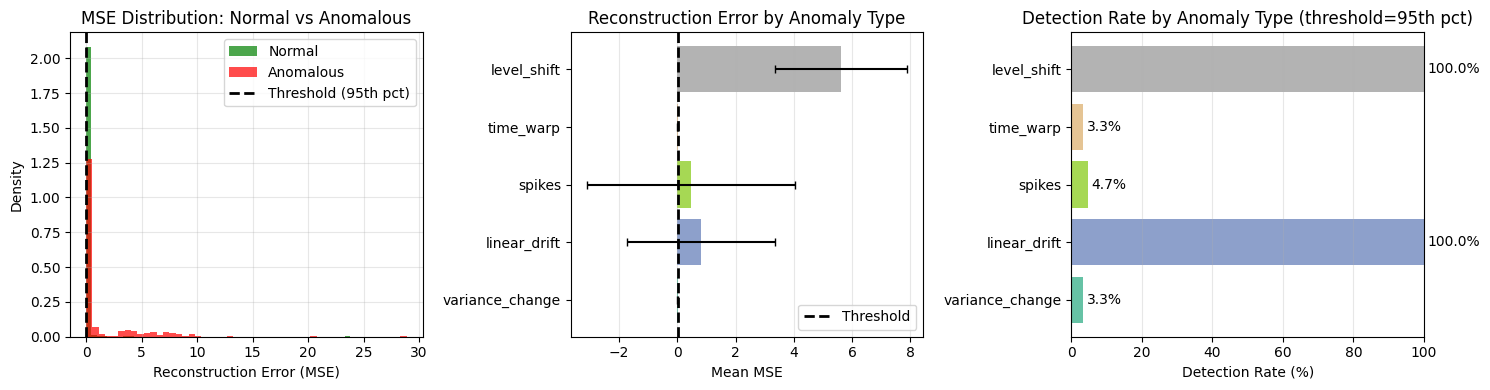

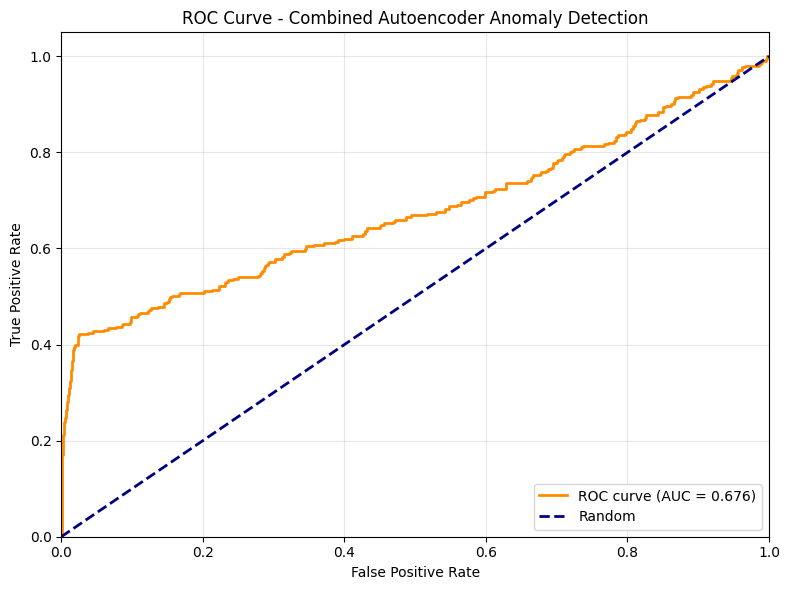

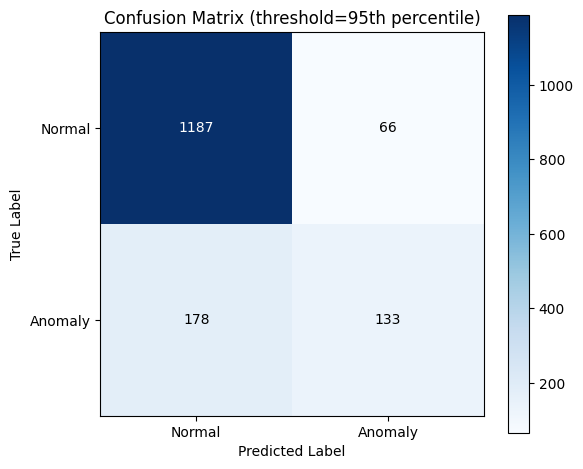


Plotting examples of detected vs missed anomalies...


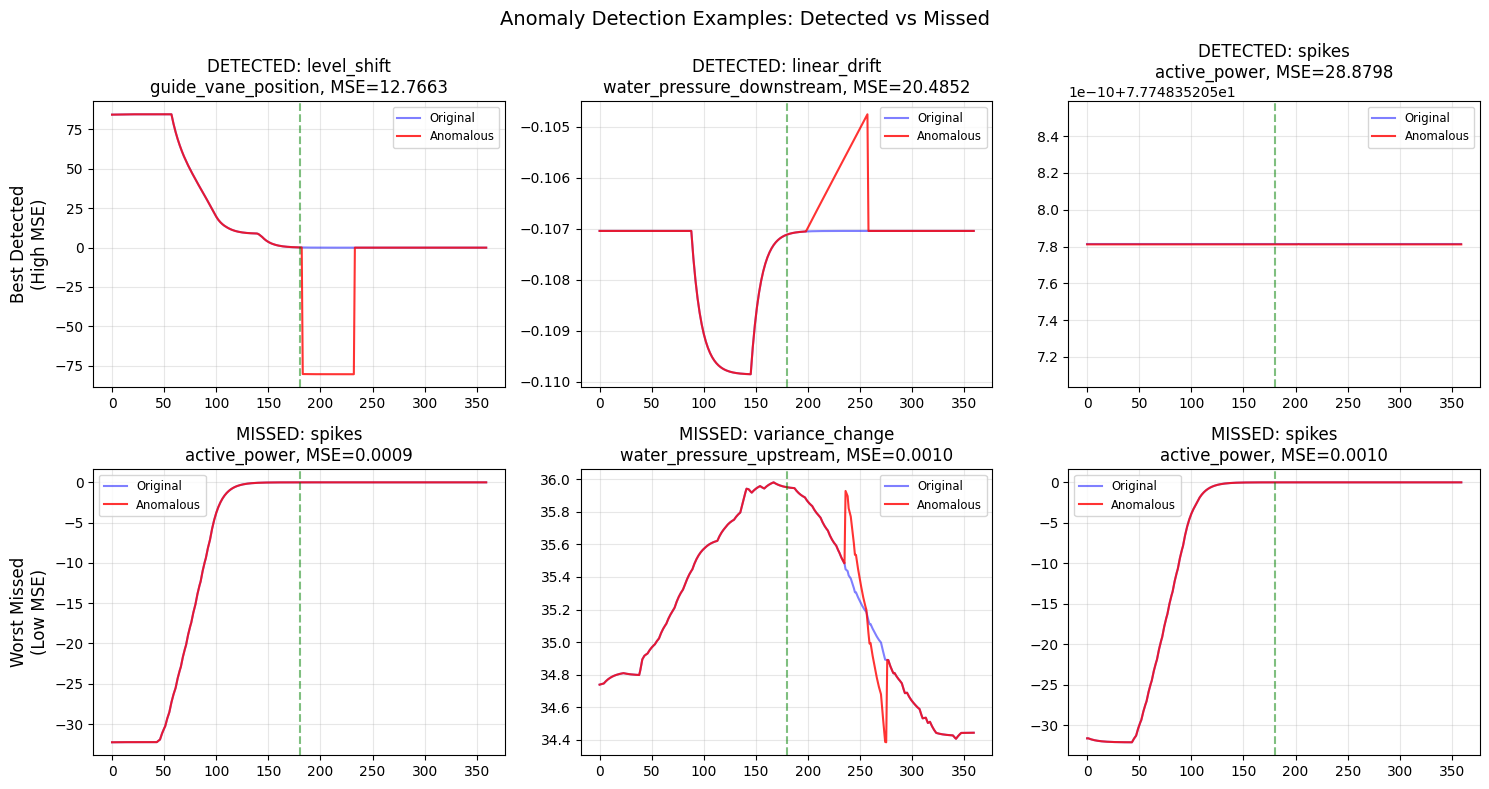


6. Latent space analysis...

   6.1 Computing distances in latent space...
   Normal windows - mean distance from centroid: 13.7458
   Anomalous windows - mean distance from centroid: 18.2838

   6.2 Latent distance-based anomaly detection...
   Threshold at 90th percentile:
     Precision: 0.422, Recall: 0.296, F1: 0.348
   Threshold at 95th percentile:
     Precision: 0.259, Recall: 0.071, F1: 0.111
   Threshold at 99th percentile:
     Precision: 0.235, Recall: 0.013, F1: 0.024

   6.3 HDBSCAN clustering in latent space...


/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   Clusters found: 3, Noise points in normal: 133
   HDBSCAN Detection: Precision=0.422, Recall=0.312, F1=0.359

   6.4 Local Outlier Factor (LOF) in latent space...


/Users/gs/Library/CloudStorage/OneDrive-Personal/EPFL/MA3/MachineLearningForPredictiveMaintenance/MLPM2025/.venv/lib/python3.10/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


   LOF Best (95th pct): Precision=0.661, Recall=0.395, F1=0.495

   6.5 Visualizing latent space...


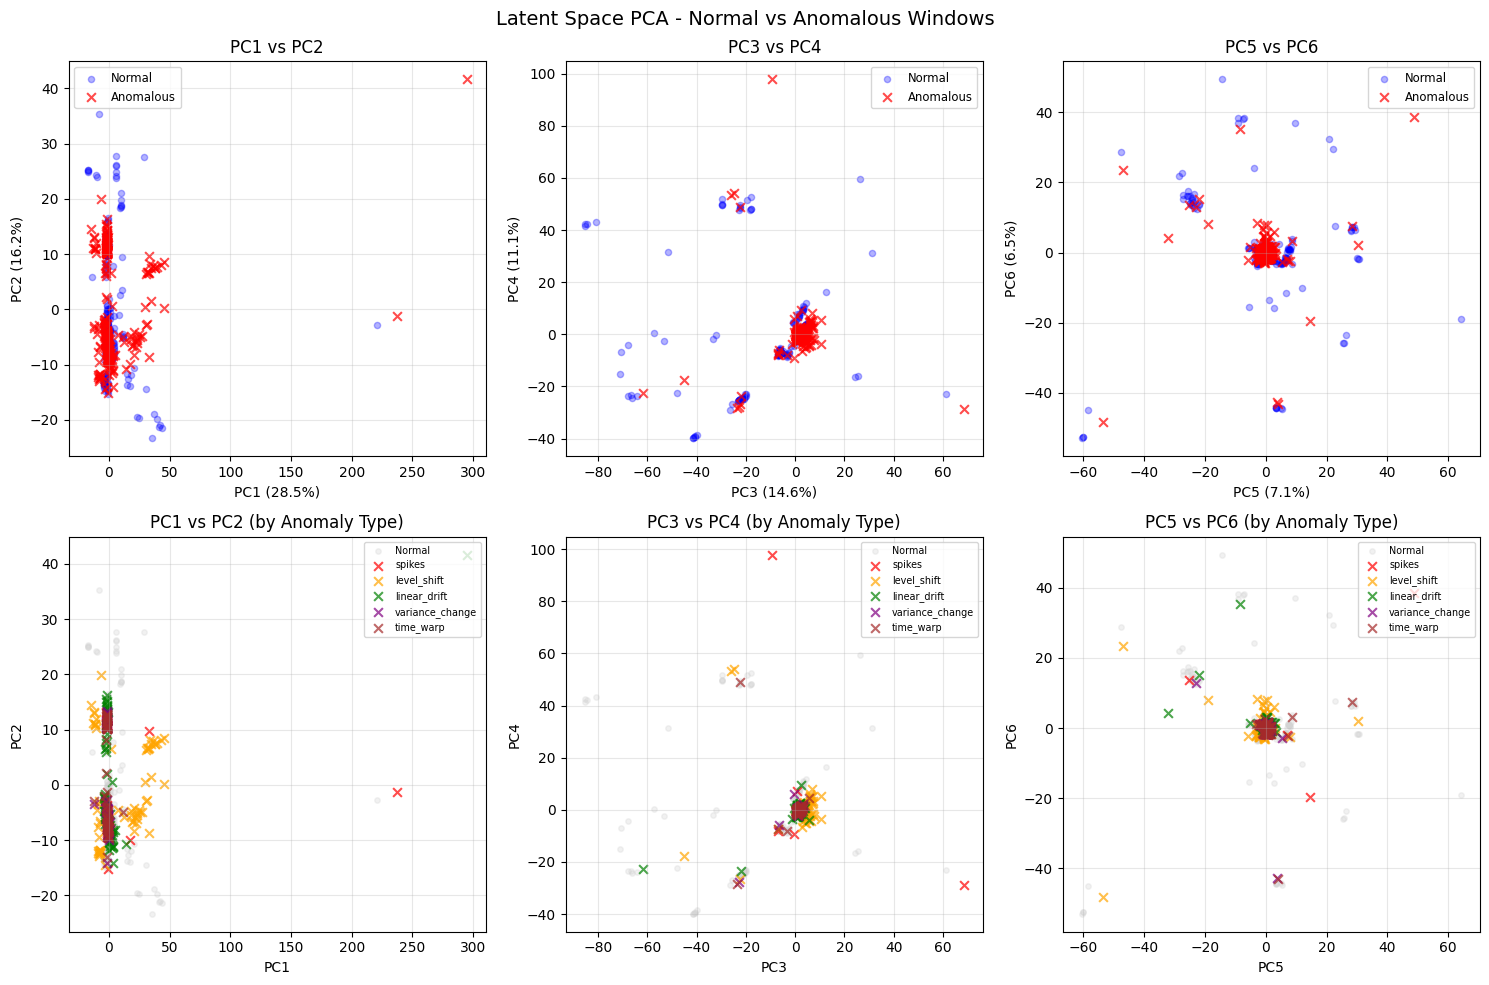


   6.6 Comparison of detection methods...


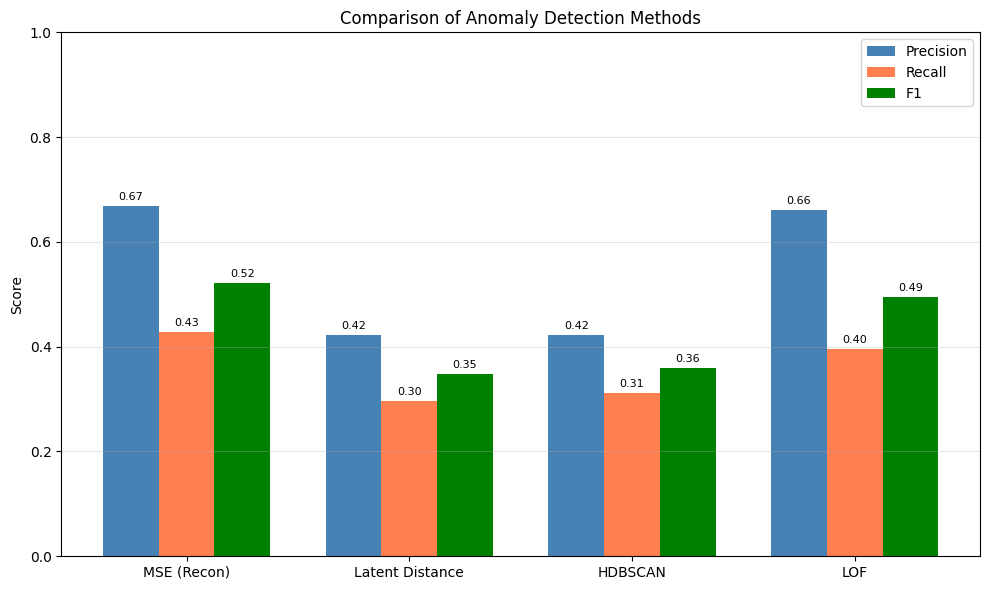

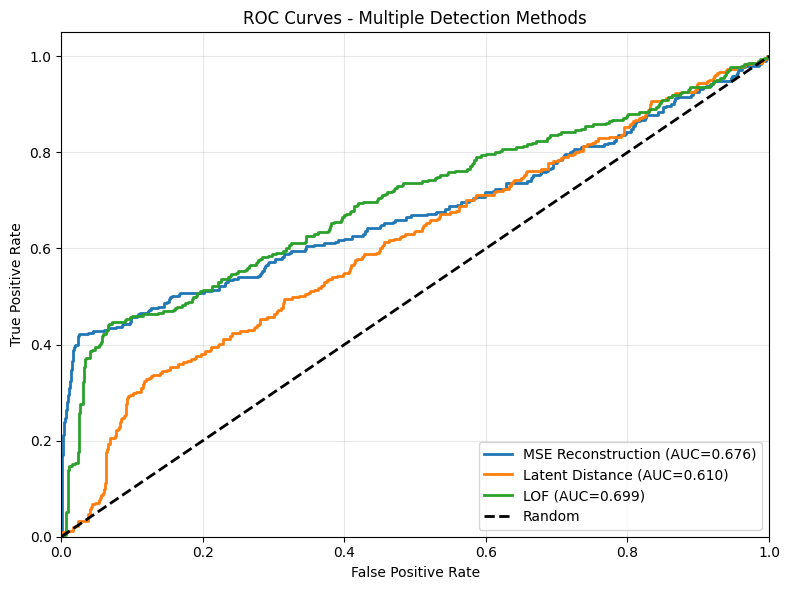


SUMMARY

📊 RECONSTRUCTION ERROR (MSE) METHOD:
   Best threshold: 95th percentile (MSE > 0.035807)
   Precision: 0.668
   Recall:    0.428
   F1 Score:  0.522
   AUC-ROC:   0.676

📊 LATENT SPACE DISTANCE METHOD:
   Best threshold: 90th percentile
   Precision: 0.422
   Recall:    0.296
   F1 Score:  0.348
   AUC-ROC:   0.610

📊 HDBSCAN CLUSTERING METHOD:
   Precision: 0.422
   Recall:    0.312
   F1 Score:  0.359

📊 LOCAL OUTLIER FACTOR (LOF) METHOD:
   Precision: 0.661
   Recall:    0.395
   F1 Score:  0.495
   AUC-ROC:   0.699

🏆 BEST METHOD BY F1 SCORE:
   MSE Reconstruction: F1 = 0.522

Detection Rate by Anomaly Type (using MSE Reconstruction):
   level_shift: 100.0%
   linear_drift: 100.0%
   spikes: 4.7%
   time_warp: 3.3%
   variance_change: 3.3%

✅ All results saved to 'anomalies_added/' folder


In [42]:
# ==============================================================================
# TEST COMBINED AUTOENCODER ON SYNTHETIC ANOMALIES
# ==============================================================================
# This cell tests the combined signals autoencoder (trained in cell 13) on the
# synthetic anomalies generated in cell 16.
#
# Requirements:
# - Run cell 13 first to train the combined autoencoder (model_combined, scaler_combined)
# - Run cell 16 first to generate anomalous windows
# ==============================================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import torch

print("="*70)
print("TESTING COMBINED AUTOENCODER ON SYNTHETIC ANOMALIES")
print("="*70)

# ==============================================================================
# 1. LOAD ANOMALOUS WINDOWS
# ==============================================================================
print("\n1. Loading synthetic anomalous windows...")

with open('anomalies_added/anomalous_training_windows.pkl', 'rb') as f:
    anomaly_data = pickle.load(f)

X_original = anomaly_data['X_original']
X_anomalous = anomaly_data['X_anomalous']
is_anomalous = anomaly_data['is_anomalous']
anomaly_metadata = anomaly_data['anomaly_metadata']

print(f"   Total windows: {len(X_original)}")
print(f"   Anomalous windows: {sum(is_anomalous)} ({100*sum(is_anomalous)/len(is_anomalous):.1f}%)")
print(f"   Normal windows: {sum(~is_anomalous)} ({100*sum(~is_anomalous)/len(is_anomalous):.1f}%)")

# ==============================================================================
# 2. COMPUTE RECONSTRUCTION ERRORS
# ==============================================================================
print("\n2. Computing reconstruction errors using trained autoencoder...")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Scale the data using the same scaler used during training
X_original_scaled = scaler_combined.transform(X_original)
X_anomalous_scaled = scaler_combined.transform(X_anomalous)

# Get reconstructions
model_combined.eval()
with torch.no_grad():
    # Original windows
    X_orig_tensor = torch.FloatTensor(X_original_scaled).to(device)
    recon_original, latent_original = model_combined(X_orig_tensor)
    recon_original = recon_original.cpu().numpy()
    latent_original = latent_original.cpu().numpy()
    
    # Anomalous windows
    X_anom_tensor = torch.FloatTensor(X_anomalous_scaled).to(device)
    recon_anomalous, latent_anomalous = model_combined(X_anom_tensor)
    recon_anomalous = recon_anomalous.cpu().numpy()
    latent_anomalous = latent_anomalous.cpu().numpy()

# Compute MSE per window
mse_original = np.mean((X_original_scaled - recon_original)**2, axis=1)
mse_anomalous = np.mean((X_anomalous_scaled - recon_anomalous)**2, axis=1)

print(f"   MSE on original windows: mean={mse_original.mean():.6f}, std={mse_original.std():.6f}")
print(f"   MSE on anomalous windows: mean={mse_anomalous.mean():.6f}, std={mse_anomalous.std():.6f}")

# ==============================================================================
# 3. ANOMALY DETECTION USING RECONSTRUCTION ERROR THRESHOLD
# ==============================================================================
print("\n3. Anomaly detection using reconstruction error threshold...")

# Use various thresholds based on original data statistics
threshold_percentiles = [90, 95, 99]
results = {}

for pct in threshold_percentiles:
    threshold = np.percentile(mse_original, pct)
    
    # Predict anomalies: reconstruction error > threshold
    predictions = mse_anomalous > threshold
    
    # Only evaluate on windows that we know the ground truth for
    # True labels: is_anomalous (from our injection)
    y_true = is_anomalous
    y_pred = predictions
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    results[pct] = {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': predictions
    }
    
    print(f"\n   Threshold at {pct}th percentile (threshold={threshold:.6f}):")
    print(f"     Precision: {precision:.3f}")
    print(f"     Recall:    {recall:.3f}")
    print(f"     F1 Score:  {f1:.3f}")

# ==============================================================================
# 4. ANALYSIS BY ANOMALY TYPE
# ==============================================================================
print("\n4. Detection performance by anomaly type...")

# Group by anomaly type
anomaly_types = list(set([m['anomaly_type'] for m in anomaly_metadata]))
type_results = {}

best_pct = max(results.keys(), key=lambda k: results[k]['f1'])
best_threshold = results[best_pct]['threshold']

for anom_type in anomaly_types:
    # Get indices of windows with this anomaly type
    type_indices = [m['window_idx'] for m in anomaly_metadata if m['anomaly_type'] == anom_type]
    
    # Get MSE for these windows
    type_mse = mse_anomalous[type_indices]
    
    # Detection rate at best threshold
    detected = sum(type_mse > best_threshold)
    total = len(type_indices)
    detection_rate = detected / total if total > 0 else 0
    
    type_results[anom_type] = {
        'total': total,
        'detected': detected,
        'detection_rate': detection_rate,
        'mean_mse': type_mse.mean(),
        'std_mse': type_mse.std()
    }
    
    signal = anomaly_data['anomaly_signal_map'][anom_type]
    print(f"\n   {anom_type.upper()} ({signal}):")
    print(f"     Total: {total}, Detected: {detected}, Rate: {100*detection_rate:.1f}%")
    print(f"     MSE: mean={type_mse.mean():.6f}, std={type_mse.std():.6f}")

# ==============================================================================
# 5. VISUALIZATIONS
# ==============================================================================
print("\n5. Generating visualizations...")

# --- 5.1 MSE Distribution: Normal vs Anomalous ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(mse_anomalous[~is_anomalous], bins=50, alpha=0.7, label='Normal', color='green', density=True)
ax.hist(mse_anomalous[is_anomalous], bins=50, alpha=0.7, label='Anomalous', color='red', density=True)
ax.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_pct}th pct)')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('MSE Distribution: Normal vs Anomalous')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 5.2 MSE by Anomaly Type ---
ax = axes[1]
types = list(type_results.keys())
means = [type_results[t]['mean_mse'] for t in types]
stds = [type_results[t]['std_mse'] for t in types]
colors = plt.cm.Set2(np.linspace(0, 1, len(types)))
bars = ax.barh(types, means, xerr=stds, color=colors, capsize=3)
ax.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Mean MSE')
ax.set_title('Reconstruction Error by Anomaly Type')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# --- 5.3 Detection Rate by Type ---
ax = axes[2]
detection_rates = [type_results[t]['detection_rate'] * 100 for t in types]
bars = ax.barh(types, detection_rates, color=colors)
ax.set_xlabel('Detection Rate (%)')
ax.set_xlim(0, 100)
ax.set_title(f'Detection Rate by Anomaly Type (threshold={best_pct}th pct)')
for i, (t, rate) in enumerate(zip(types, detection_rates)):
    ax.text(rate + 1, i, f'{rate:.1f}%', va='center')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('anomalies_added/detection_results_by_type.png', dpi=150)
plt.show()

# --- 5.4 ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, thresholds = roc_curve(is_anomalous, mse_anomalous)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Combined Autoencoder Anomaly Detection')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomalies_added/roc_curve.png', dpi=150)
plt.show()

# --- 5.5 Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))

best_predictions = results[best_pct]['predictions']
cm = confusion_matrix(is_anomalous, best_predictions)

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
       ylabel='True Label', xlabel='Predicted Label',
       title=f'Confusion Matrix (threshold={best_pct}th percentile)')

# Add text annotations
thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('anomalies_added/confusion_matrix.png', dpi=150)
plt.show()

# --- 5.6 Example: Worst Detected Anomalies ---
print("\nPlotting examples of detected vs missed anomalies...")

# Get anomaly indices sorted by MSE
anomaly_indices = np.where(is_anomalous)[0]
anomaly_mse = mse_anomalous[anomaly_indices]
sorted_idx = np.argsort(anomaly_mse)

# Best detected (highest MSE)
best_detected_idx = anomaly_indices[sorted_idx[-3:]]  # Top 3
# Worst missed (lowest MSE among anomalies)
worst_missed_idx = anomaly_indices[sorted_idx[:3]]    # Bottom 3

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Helper to get signal name for a window
def get_anomaly_info(win_idx):
    for m in anomaly_metadata:
        if m['window_idx'] == win_idx:
            return m['anomaly_type'], m['signal']
    return 'unknown', 'unknown'

# Top row: Best detected
for i, idx in enumerate(best_detected_idx):
    ax = axes[0, i]
    anom_type, signal = get_anomaly_info(idx)
    sig_idx = ALL_SIGNALS.index(signal)
    
    # Extract signal from original and anomalous
    orig_reshaped = X_original[idx].reshape(-1, 6)
    anom_reshaped = X_anomalous[idx].reshape(-1, 6)
    
    ax.plot(orig_reshaped[:, sig_idx], 'b-', alpha=0.5, label='Original')
    ax.plot(anom_reshaped[:, sig_idx], 'r-', alpha=0.8, label='Anomalous')
    ax.axvline(180, color='green', linestyle='--', alpha=0.5)
    ax.set_title(f'DETECTED: {anom_type}\n{signal}, MSE={mse_anomalous[idx]:.4f}')
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

# Bottom row: Worst missed
for i, idx in enumerate(worst_missed_idx):
    ax = axes[1, i]
    anom_type, signal = get_anomaly_info(idx)
    sig_idx = ALL_SIGNALS.index(signal)
    
    orig_reshaped = X_original[idx].reshape(-1, 6)
    anom_reshaped = X_anomalous[idx].reshape(-1, 6)
    
    ax.plot(orig_reshaped[:, sig_idx], 'b-', alpha=0.5, label='Original')
    ax.plot(anom_reshaped[:, sig_idx], 'r-', alpha=0.8, label='Anomalous')
    ax.axvline(180, color='green', linestyle='--', alpha=0.5)
    ax.set_title(f'MISSED: {anom_type}\n{signal}, MSE={mse_anomalous[idx]:.4f}')
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Best Detected\n(High MSE)', fontsize=12)
axes[1, 0].set_ylabel('Worst Missed\n(Low MSE)', fontsize=12)

plt.suptitle('Anomaly Detection Examples: Detected vs Missed', fontsize=14)
plt.tight_layout()
plt.savefig('anomalies_added/detection_examples.png', dpi=150)
plt.show()

# ==============================================================================
# 6. LATENT SPACE ANALYSIS
# ==============================================================================
print("\n6. Latent space analysis...")

from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from scipy.spatial.distance import cdist
import hdbscan

# --- 6.1 Compute Latent Space Distances ---
print("\n   6.1 Computing distances in latent space...")

# Compute centroid of normal windows in latent space
normal_indices = ~is_anomalous
latent_normal_centroid = latent_anomalous[normal_indices].mean(axis=0)

# Distance from centroid for all windows
dist_from_centroid = np.linalg.norm(latent_anomalous - latent_normal_centroid, axis=1)

print(f"   Normal windows - mean distance from centroid: {dist_from_centroid[normal_indices].mean():.4f}")
print(f"   Anomalous windows - mean distance from centroid: {dist_from_centroid[is_anomalous].mean():.4f}")

# --- 6.2 Latent Distance-Based Detection ---
print("\n   6.2 Latent distance-based anomaly detection...")

latent_results = {}
for pct in threshold_percentiles:
    threshold = np.percentile(dist_from_centroid[normal_indices], pct)
    predictions = dist_from_centroid > threshold
    
    precision = precision_score(is_anomalous, predictions, zero_division=0)
    recall = recall_score(is_anomalous, predictions, zero_division=0)
    f1 = f1_score(is_anomalous, predictions, zero_division=0)
    
    latent_results[pct] = {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': predictions
    }
    
    print(f"   Threshold at {pct}th percentile:")
    print(f"     Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

# --- 6.3 HDBSCAN on Latent Space ---
print("\n   6.3 HDBSCAN clustering in latent space...")

# Fit HDBSCAN on latent representations of normal windows
latent_normal = latent_anomalous[normal_indices]
clusterer = hdbscan.HDBSCAN(min_cluster_size=max(5, int(len(latent_normal) * 0.05)), 
                            metric='euclidean', prediction_data=True)
clusterer.fit(latent_normal)

n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
n_noise = sum(clusterer.labels_ == -1)
print(f"   Clusters found: {n_clusters}, Noise points in normal: {n_noise}")

# Predict on all windows (including anomalous)
labels_all, strengths_all = hdbscan.approximate_predict(clusterer, latent_anomalous)

# Flag as anomaly if: noise (-1) or low strength
hdbscan_anomaly_pred = (labels_all == -1) | (strengths_all < 0.1)

hdbscan_precision = precision_score(is_anomalous, hdbscan_anomaly_pred, zero_division=0)
hdbscan_recall = recall_score(is_anomalous, hdbscan_anomaly_pred, zero_division=0)
hdbscan_f1 = f1_score(is_anomalous, hdbscan_anomaly_pred, zero_division=0)

print(f"   HDBSCAN Detection: Precision={hdbscan_precision:.3f}, Recall={hdbscan_recall:.3f}, F1={hdbscan_f1:.3f}")

# --- 6.4 Local Outlier Factor on Latent Space ---
print("\n   6.4 Local Outlier Factor (LOF) in latent space...")

lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(latent_normal)

# Predict on all windows
lof_scores = -lof.decision_function(latent_anomalous)  # Higher = more anomalous

lof_results = {}
for pct in threshold_percentiles:
    threshold = np.percentile(lof_scores[normal_indices], pct)
    predictions = lof_scores > threshold
    
    precision = precision_score(is_anomalous, predictions, zero_division=0)
    recall = recall_score(is_anomalous, predictions, zero_division=0)
    f1 = f1_score(is_anomalous, predictions, zero_division=0)
    
    lof_results[pct] = {'precision': precision, 'recall': recall, 'f1': f1}

best_lof_pct = max(lof_results.keys(), key=lambda k: lof_results[k]['f1'])
print(f"   LOF Best ({best_lof_pct}th pct): Precision={lof_results[best_lof_pct]['precision']:.3f}, "
      f"Recall={lof_results[best_lof_pct]['recall']:.3f}, F1={lof_results[best_lof_pct]['f1']:.3f}")

# --- 6.5 Visualize Latent Space with PCA ---
print("\n   6.5 Visualizing latent space...")

# PCA on latent space
pca = PCA(n_components=6)
latent_pca = pca.fit_transform(latent_anomalous)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot PC pairs
pc_pairs = [(0, 1), (2, 3), (4, 5)]
for idx, (ax_row, (pc_x, pc_y)) in enumerate(zip(axes[0], pc_pairs)):
    ax = ax_row
    
    # Normal points
    ax.scatter(latent_pca[normal_indices, pc_x], latent_pca[normal_indices, pc_y], 
               c='blue', alpha=0.3, s=20, label='Normal')
    # Anomalous points
    ax.scatter(latent_pca[is_anomalous, pc_x], latent_pca[is_anomalous, pc_y], 
               c='red', alpha=0.7, s=40, marker='x', label='Anomalous')
    
    ax.set_xlabel(f'PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.1f}%)')
    ax.set_ylabel(f'PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.1f}%)')
    ax.set_title(f'PC{pc_x+1} vs PC{pc_y+1}')
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

# Color by anomaly type
anomaly_type_colors = {'spikes': 'red', 'level_shift': 'orange', 'linear_drift': 'green', 
                       'variance_change': 'purple', 'time_warp': 'brown'}

for idx, (ax, (pc_x, pc_y)) in enumerate(zip(axes[1], pc_pairs)):
    # Normal points (gray background)
    ax.scatter(latent_pca[normal_indices, pc_x], latent_pca[normal_indices, pc_y], 
               c='lightgray', alpha=0.3, s=15, label='Normal')
    
    # Anomalous points colored by type
    for anom_type, color in anomaly_type_colors.items():
        type_indices = [m['window_idx'] for m in anomaly_metadata if m['anomaly_type'] == anom_type]
        if type_indices:
            ax.scatter(latent_pca[type_indices, pc_x], latent_pca[type_indices, pc_y], 
                       c=color, alpha=0.7, s=40, marker='x', label=anom_type)
    
    ax.set_xlabel(f'PC{pc_x+1}')
    ax.set_ylabel(f'PC{pc_y+1}')
    ax.set_title(f'PC{pc_x+1} vs PC{pc_y+1} (by Anomaly Type)')
    ax.legend(fontsize='x-small', loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Latent Space PCA - Normal vs Anomalous Windows', fontsize=14)
plt.tight_layout()
plt.savefig('anomalies_added/latent_space_pca.png', dpi=150)
plt.show()

# --- 6.6 Compare Methods ---
print("\n   6.6 Comparison of detection methods...")

fig, ax = plt.subplots(figsize=(10, 6))

methods = ['MSE (Recon)', 'Latent Distance', 'HDBSCAN', 'LOF']
best_mse_f1 = results[best_pct]['f1']
best_latent_pct = max(latent_results.keys(), key=lambda k: latent_results[k]['f1'])
best_latent_f1 = latent_results[best_latent_pct]['f1']
best_lof_f1 = lof_results[best_lof_pct]['f1']

f1_scores = [best_mse_f1, best_latent_f1, hdbscan_f1, best_lof_f1]
precisions = [results[best_pct]['precision'], latent_results[best_latent_pct]['precision'], 
              hdbscan_precision, lof_results[best_lof_pct]['precision']]
recalls = [results[best_pct]['recall'], latent_results[best_latent_pct]['recall'], 
           hdbscan_recall, lof_results[best_lof_pct]['recall']]

x = np.arange(len(methods))
width = 0.25

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x, recalls, width, label='Recall', color='coral')
bars3 = ax.bar(x + width, f1_scores, width, label='F1', color='green')

ax.set_ylabel('Score')
ax.set_title('Comparison of Anomaly Detection Methods')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('anomalies_added/method_comparison.png', dpi=150)
plt.show()

# --- 6.7 ROC Curves for All Methods ---
fig, ax = plt.subplots(figsize=(8, 6))

# MSE-based ROC
fpr_mse, tpr_mse, _ = roc_curve(is_anomalous, mse_anomalous)
auc_mse = auc(fpr_mse, tpr_mse)
ax.plot(fpr_mse, tpr_mse, lw=2, label=f'MSE Reconstruction (AUC={auc_mse:.3f})')

# Latent distance ROC
fpr_lat, tpr_lat, _ = roc_curve(is_anomalous, dist_from_centroid)
auc_lat = auc(fpr_lat, tpr_lat)
ax.plot(fpr_lat, tpr_lat, lw=2, label=f'Latent Distance (AUC={auc_lat:.3f})')

# LOF ROC
fpr_lof, tpr_lof, _ = roc_curve(is_anomalous, lof_scores)
auc_lof = auc(fpr_lof, tpr_lof)
ax.plot(fpr_lof, tpr_lof, lw=2, label=f'LOF (AUC={auc_lof:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Multiple Detection Methods')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomalies_added/roc_curves_all_methods.png', dpi=150)
plt.show()

# ==============================================================================
# 7. SUMMARY
# ==============================================================================
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print("\n📊 RECONSTRUCTION ERROR (MSE) METHOD:")
print(f"   Best threshold: {best_pct}th percentile (MSE > {best_threshold:.6f})")
print(f"   Precision: {results[best_pct]['precision']:.3f}")
print(f"   Recall:    {results[best_pct]['recall']:.3f}")
print(f"   F1 Score:  {results[best_pct]['f1']:.3f}")
print(f"   AUC-ROC:   {auc_mse:.3f}")

print("\n📊 LATENT SPACE DISTANCE METHOD:")
best_latent_pct = max(latent_results.keys(), key=lambda k: latent_results[k]['f1'])
print(f"   Best threshold: {best_latent_pct}th percentile")
print(f"   Precision: {latent_results[best_latent_pct]['precision']:.3f}")
print(f"   Recall:    {latent_results[best_latent_pct]['recall']:.3f}")
print(f"   F1 Score:  {latent_results[best_latent_pct]['f1']:.3f}")
print(f"   AUC-ROC:   {auc_lat:.3f}")

print("\n📊 HDBSCAN CLUSTERING METHOD:")
print(f"   Precision: {hdbscan_precision:.3f}")
print(f"   Recall:    {hdbscan_recall:.3f}")
print(f"   F1 Score:  {hdbscan_f1:.3f}")

print("\n📊 LOCAL OUTLIER FACTOR (LOF) METHOD:")
print(f"   Precision: {lof_results[best_lof_pct]['precision']:.3f}")
print(f"   Recall:    {lof_results[best_lof_pct]['recall']:.3f}")
print(f"   F1 Score:  {lof_results[best_lof_pct]['f1']:.3f}")
print(f"   AUC-ROC:   {auc_lof:.3f}")

print("\n🏆 BEST METHOD BY F1 SCORE:")
all_f1 = {'MSE Reconstruction': best_mse_f1, 'Latent Distance': best_latent_f1, 
          'HDBSCAN': hdbscan_f1, 'LOF': best_lof_f1}
best_method = max(all_f1.keys(), key=lambda k: all_f1[k])
print(f"   {best_method}: F1 = {all_f1[best_method]:.3f}")

print(f"\nDetection Rate by Anomaly Type (using {best_method}):")
for anom_type in sorted(type_results.keys()):
    rate = type_results[anom_type]['detection_rate'] * 100
    print(f"   {anom_type}: {rate:.1f}%")

print("\n✅ All results saved to 'anomalies_added/' folder")